# Прогноз биржа

### Описание проекта
Задача: создать модель МО, которая будет определять направление цены на следующий день.

Метрика: самостоятельный выбор

Особенности: В последних ячейках необходимо вывести метрики и матрицу ошибок на трейне и тесте.

Описание данных:
Собрать данные с Московской Биржи самостоятельно.

## Загрузка и подготовка данных

### Загрузка библиотек, классов и метрик

In [ ]:
!pip install phik -q
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.rcParams["figure.figsize"] = (18,8)

import os
import time
import joblib
import sklearn
import phik

import warnings
warnings.filterwarnings("ignore")

import requests

from datetime import datetime

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels. tsa.stattools import adfuller
# загружаем функцию для работы с метриками
from sklearn.metrics import mean_squared_error, make_scorer, mean_absolute_error, r2_score

# загружаем класс pipeline
from sklearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# загружаем нужные модели
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# загружаем функцию для работы с метриками
from sklearn.metrics import (
    confusion_matrix, recall_score, precision_score, accuracy_score,
    roc_auc_score, f1_score
)

import lightgbm
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool

from datetime import datetime, timedelta
import time
import requests

In [ ]:
sklearn.__version__

'1.6.1'

In [ ]:
RANDOM_STATE = 654321
TEST_SIZE = 0.1

np.random.seed(RANDOM_STATE)

### Загрузка данных и знакомство с ними

In [ ]:
def get_moex_data(security, start_date, end_date):
    start_date = start_date.strftime('%Y-%m-%d')
    end_date = end_date.strftime('%Y-%m-%d')

    url = f'https://iss.moex.com/iss/history/engines/stock/markets/shares/securities/{security}.json'
    params = {'from': start_date, 'till': end_date, 'start': 0}

    all_data = []
    total_loaded = 0
    batch_size = 100

    while True:
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"❌ Ошибка при загрузке данных: {response.status_code}")
            break

        json_data = response.json()

        if 'history' not in json_data or 'data' not in json_data['history']:
            print(f"⚠️ Нет данных для {security} за указанный период.")
            break

        data = json_data['history']['data']
        if not data:
            break

        all_data.extend(data)
        total_loaded += len(data)

        if len(data) < batch_size:
            break

        params['start'] += batch_size
        time.sleep(0.5)

    if not all_data:
        print(f"⚠️ Данные не найдены.")
        return pd.DataFrame()

    columns = json_data['history']['columns']
    df = pd.DataFrame(all_data, columns=columns)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df.set_index('TRADEDATE', inplace=True)

    print(f"✅ Загружено строк для {security}: {total_loaded}")
    return df

def load_multiple_securities(securities, start_date, end_date):
    data_dict = {}

    for security in securities:
        print(f"\nЗагружаем данные для {security}...")
        try:
            data = get_moex_data(security, start_date, end_date)
            if not data.empty:
                data_dict[security] = data
        except Exception as e:
            print(f"Ошибка при загрузке {security}: {e}")

        # Добавляем паузу между запросами
        time.sleep(1)

    return data_dict

In [ ]:
# Зададим переменные функции:
securities = ['GAZP', 'SBER', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'GMKN']
start_date = datetime(2004, 1, 1)
end_date = datetime(2025, 6, 30)

# Загружаем данные
all_data = load_multiple_securities(securities, start_date, end_date)


Загружаем данные для GAZP...
✅ Загружено строк для GAZP: 11254

Загружаем данные для SBER...
✅ Загружено строк для SBER: 9300

Загружаем данные для LKOH...
✅ Загружено строк для LKOH: 8160

Загружаем данные для ROSN...
✅ Загружено строк для ROSN: 10176

Загружаем данные для NVTK...
✅ Загружено строк для NVTK: 7310

Загружаем данные для TATN...
✅ Загружено строк для TATN: 6160

Загружаем данные для GMKN...
✅ Загружено строк для GMKN: 7709


In [ ]:
# Пример анализа полученных данных
if all_data:
    print("\nЗагруженные данные:")
    for security, data in all_data.items():
        print(f"\nДанные для {security}:")
        display(data.head())
        print(f"Количество записей: {len(data)}")
        print(f"Период данных: от {data.index.min()} до {data.index.max()}")


Загруженные данные:

Данные для GAZP:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2006-01-23,EQNE,ГАЗПРОМ ао,GAZP,4896,1.130995e+09,239.50,218.49,239.50,219.20,220.86,...,NaN,221.08,NaN,NaN,NaN,NaN,3,SUR,NaN,None
2006-01-24,EQNE,ГАЗПРОМ ао,GAZP,4220,1.991942e+09,221.00,219.66,224.68,223.60,221.74,...,NaN,221.40,NaN,NaN,NaN,NaN,3,SUR,2.33,None
2006-01-25,EQNE,ГАЗПРОМ ао,GAZP,6944,3.534137e+09,225.50,225.00,231.00,228.48,228.30,...,NaN,228.29,NaN,NaN,NaN,NaN,3,SUR,1.96,None
2006-01-26,EQNE,ГАЗПРОМ ао,GAZP,5108,1.721376e+09,228.20,223.51,229.41,225.12,226.83,...,NaN,226.99,NaN,NaN,NaN,NaN,3,SUR,-1.71,None
2006-01-27,EQNE,ГАЗПРОМ ао,GAZP,7279,2.901323e+09,225.75,224.00,231.50,227.96,227.92,...,NaN,227.91,NaN,NaN,NaN,NaN,3,SUR,1.91,None


Количество записей: 11254
Период данных: от 2006-01-23 00:00:00 до 2025-06-30 00:00:00

Данные для SBER:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2011-11-21,EQBR,Сбербанк,SBER,128096,2.283014e+10,79.00,75.85,79.37,76.00,77.71,...,77.71,77.71,2.283016e+10,2.283016e+10,2.283016e+10,NaN,3,SUR,-5.05,None
2011-11-21,SMAL,Сбербанк,SBER,56,2.539949e+04,79.49,74.50,79.49,75.44,76.27,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,-7.45,None
2011-11-22,EQBR,Сбербанк,SBER,126144,2.091095e+10,76.40,75.10,77.76,76.08,76.71,...,76.71,76.71,2.091103e+10,2.091103e+10,2.091103e+10,NaN,3,SUR,0.54,None
2011-11-22,SMAL,Сбербанк,SBER,50,8.413835e+04,73.20,73.20,77.69,75.97,76.14,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,2.62,None
2011-11-23,EQBR,Сбербанк,SBER,140160,2.556061e+10,75.00,74.42,77.44,76.71,76.21,...,76.21,76.21,2.556062e+10,2.556062e+10,2.556062e+10,NaN,3,SUR,0.52,None


Количество записей: 9300
Период данных: от 2011-11-21 00:00:00 до 2025-06-30 00:00:00

Данные для LKOH:


...

Количество записей: 7310
Период данных: от 2011-11-21 00:00:00 до 2025-06-30 00:00:00

Данные для TATN:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2011-11-21,EQBR,Татнфт 3ао,TATN,7444,3.768274e+08,151.25,143.50,153.97,143.68,146.52,...,146.52,146.52,3.768285e+08,3.768285e+08,3.768285e+08,NaN,3,SUR,-6.77,None
2011-11-21,SMAL,Татнфт 3ао,TATN,3,1.134380e+03,146.00,133.15,146.00,142.04,141.80,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,-10.66,None
2011-11-22,EQBR,Татнфт 3ао,TATN,3682,2.780095e+08,143.50,142.86,148.40,147.99,147.05,...,147.05,147.05,2.780124e+08,2.780124e+08,2.780124e+08,NaN,3,SUR,3.17,None
2011-11-22,SMAL,Татнфт 3ао,TATN,4,2.945350e+03,143.52,143.52,156.99,156.99,147.27,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,10.53,None
2011-11-23,EQBR,Татнфт 3ао,TATN,8897,3.297670e+08,146.32,145.01,151.65,147.01,148.19,...,148.19,148.19,3.297670e+08,3.297670e+08,3.297670e+08,NaN,3,SUR,-1.07,None


Количество записей: 6160
Период данных: от 2011-11-21 00:00:00 до 2025-06-30 00:00:00

Данные для GMKN:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2006-12-26,EQNL,ГМКНорНик,GMKN,1688,6.665215e+08,3675.06,3675.06,3983.95,3954.83,3958.08,...,NaN,3958.60,NaN,NaN,NaN,NaN,3,SUR,-0.18,None
2006-12-27,EQNL,ГМКНорНик,GMKN,4783,1.157245e+09,3962.20,3940.12,4039.00,4025.35,3995.17,...,NaN,3986.35,NaN,NaN,NaN,NaN,3,SUR,2.18,None
2006-12-28,EQNL,ГМКНорНик,GMKN,5849,1.859770e+09,4047.49,4027.20,4104.96,4092.19,4070.29,...,NaN,4062.80,NaN,NaN,NaN,NaN,3,SUR,1.55,None
2006-12-29,EQNL,ГМКНорНик,GMKN,2419,9.101435e+08,4099.00,4078.00,4120.00,4092.49,4095.82,...,NaN,4095.89,NaN,NaN,NaN,NaN,3,SUR,-0.47,None
2007-01-09,EQNL,ГМКНорНик,GMKN,8395,3.096336e+09,3899.00,3750.00,3899.00,3773.37,3802.45,...,NaN,3807.14,NaN,NaN,NaN,NaN,3,SUR,-7.97,None


Количество записей: 7709
Период данных: от 2006-12-26 00:00:00 до 2025-06-30 00:00:00


In [ ]:
import os

if not os.path.exists('data'):
    os.makedirs('data')

# Базовый вариант сохранения
for security, data in all_data.items():
    file_path = f'{security}_history.csv'
    data.to_csv(file_path,
                index=True,
                encoding='utf-8-sig',
                float_format='%.2f')
    print(f"Данные для {security} успешно сохранены в {file_path}")

Данные для GAZP успешно сохранены в GAZP_history.csv
Данные для SBER успешно сохранены в SBER_history.csv
Данные для LKOH успешно сохранены в LKOH_history.csv
Данные для ROSN успешно сохранены в ROSN_history.csv
Данные для NVTK успешно сохранены в NVTK_history.csv
Данные для TATN успешно сохранены в TATN_history.csv
Данные для GMKN успешно сохранены в GMKN_history.csv


In [ ]:
# Определяем пути для всех файлов
paths = {
    'gazp': ('/content/GAZP_history.csv', '/datasets/gazp_history.csv'),
    'gmkn': ('/content/GMKN_history.csv', '/datasets/gmkn_history.csv'),
    'lkoh': ('/content/LKOH_history.csv', '/datasets/lkoh_history.csv'),
    'nvtk': ('/content/NVTK_history.csv', '/datasets/nvtk_history.csv'),
    'rosn': ('/content/ROSN_history.csv', '/datasets/rosn_history.csv'),
    'sber': ('/content/SBER_history.csv', '/datasets/sber_history.csv'),
    'tatn': ('/content/TATN_history.csv', '/datasets/tatn_history.csv')
}

# Функция для загрузки одного датасета
def load_dataset(ticker):
    pth1, pth2 = paths[ticker]

    if os.path.exists(pth1):
        return pd.read_csv(pth1, sep=',', on_bad_lines='skip',
                          parse_dates=[0], date_format="%Y%m%d", index_col=[0])
    elif os.path.exists(pth2):
        return pd.read_csv(pth2, sep=',', on_bad_lines='skip',
                          parse_dates=[0], date_format="%Y%m%d", index_col=[0])
    else:
        print(f"PathError: файл для {ticker} не найден")
        return None

# Загружаем все датасеты
datasets = {}
for ticker in paths.keys():
    datasets[ticker] = load_dataset(ticker)

# Проверяем успешность загрузки
for ticker, df in datasets.items():
    if df is not None:
        print(f"{ticker} загружен успешно, размер: {len(df)} записей")
    else:
        print(f"Ошибка при загрузке {ticker}")

gazp загружен успешно, размер: 11254 записей
gmkn загружен успешно, размер: 7709 записей
lkoh загружен успешно, размер: 8160 записей
nvtk загружен успешно, размер: 7310 записей
rosn загружен успешно, размер: 10176 записей
sber загружен успешно, размер: 9300 записей
tatn загружен успешно, размер: 6160 записей


In [ ]:
def check_index_monotonicity(df):
    # Проверяем все возможные комбинации
    if df.index.is_monotonic_increasing and df.index.is_unique:
        return "Индекс монотонный, неубывающий, повторов нет"
    elif df.index.is_monotonic_decreasing and df.index.is_unique:
        return "Индекс монотонный, невозрастающий, повторов нет"
    elif df.index.is_monotonic_increasing:
        return "Индекс монотонный, неубывающий, но есть повторы"
    elif df.index.is_monotonic_decreasing:
        return "Индекс монотонный, невозрастающий, но есть повторы"
    else:
        return "Индекс немонотонный"

# Пример использования:
def analyze_dataset(df):
    print(check_index_monotonicity(df))
    display(df.head(3))
    display(df.tail(3))
    display(df.info())

# Пример вызова:
# analyze_dataset(df)

In [ ]:
# Создаем словарь с названиями переменных
tickers = {
    'gazp': 'GAZP',
    'gmkn': 'GMKN',
    'lkoh': 'LKOH',
    'nvtk': 'NVTK',
    'rosn': 'ROSN',
    'sber': 'SBER',
    'tatn': 'TATN'
}

# Загружаем данные в соответствующие переменные
for ticker, var_name in tickers.items():
    try:
        exec(f"{ticker} = datasets['{ticker}']")
    except Exception as e:
        print(f"Ошибка при загрузке {var_name}: {e}")



In [ ]:
datasets = [gazp, gmkn, lkoh, nvtk,
            rosn, sber, tatn]
for dataset in datasets:
  #analyze_dataset(dataset)
  print(dataset.iloc[0]['SHORTNAME'])
  counts = dataset['BOARDID'].value_counts()
  print(counts)
  print("-" * 30)
  print("\n")

ГАЗПРОМ ао
BOARDID
SMAL    3601
TQBR    2794
EQNE    1901
EQDP    1819
SPEQ     518
EQCC     318
TQNE     194
TQBS     109
Name: count, dtype: int64
------------------------------


ГМКНорНик
BOARDID
TQBR    2794
EQDP    1819
EQNL     825
EQBS     520
SPEQ     518
EQBR     321
EQCC     318
TQBS     303
SMAL     291
Name: count, dtype: int64
------------------------------


ЛУКОЙЛ
BOARDID
TQBR    3097
EQBR    2408
EQDP    1819
SPEQ     518
EQCC     318
Name: count, dtype: int64
------------------------------


Новатэк ао
BOARDID
TQBR    3097
EQDP    1712
SMAL    1533
SPEQ     518
EQBR     450
Name: count, dtype: int64
------------------------------


Роснефть
BOARDID
TQBR    2794
SMAL    2645
EQDP    1819
EQNL    1670
SPEQ     518
EQCC     318
TQNL     289
EQLV     109
TQBS      14
Name: count, dtype: int64
------------------------------


Сбербанк
BOARDID
SMAL    3416
TQBR    3097
EQDP    1819
SPEQ     518
EQBR     450
Name: count, dtype: int64
------------------------------


Татнфт 3

Выберем торговый код TQBR

**Причины**: TQBR  — это торговый код основного рынка акций Московской биржи (Мосбиржа). Это основной торговый поток, где происходит основная часть торгов акциями российских компаний.

Основные характеристики TQBR:
- Основной рынок — здесь торгуются наиболее ликвидные акции крупнейших российских компаний
- Режим торгов — непрерывный двойной аукцион
- Время торгов — с 10:00 до 18:40 (основная сессия)
- Расчетный период — T+1 (расчеты на следующий рабочий день)
- Минимальная цена шага — зависит от цены акции (от 0,01 до 10 рублей)

На TQBR торгуются акции таких компаний как:
- Сбербанк
- Газпром
- Лукойл
- Роснефть
- Яндекс
и другие крупнейшие эмитенты

Преимущества торгов на TQBR:
- Высокая ликвидность
- Прозрачность ценообразования
- Надежность расчетов
- Доступ к торгам для всех категорий инвесторов
- Строгие требования к листингу

In [ ]:
gazp = gazp.loc[gazp['BOARDID'] == 'TQBR']
gmkn = gmkn.loc[gmkn['BOARDID'] == 'TQBR']
lkoh = lkoh.loc[lkoh['BOARDID'] == 'TQBR']
nvtk = nvtk.loc[nvtk['BOARDID'] == 'TQBR']
rosn = rosn.loc[rosn['BOARDID'] == 'TQBR']
sber = sber.loc[sber['BOARDID'] == 'TQBR']
tatn = tatn.loc[tatn['BOARDID'] == 'TQBR']

In [ ]:
datasets = [gazp, gmkn, lkoh, nvtk,
            rosn, sber, tatn]
for dataset in datasets:
  print(dataset.iloc[0]['SHORTNAME'])
  analyze_dataset(dataset)
  print("-" * 30)
  print("\n" * 3)

ГАЗПРОМ ао
Индекс монотонный, неубывающий, повторов нет


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2014-06-09,TQBR,ГАЗПРОМ ао,GAZP,32981,5.851239e+09,144.00,143.03,146.20,144.40,145.02,...,145.02,145.02,5.850366e+09,5.850366e+09,5.850366e+09,NaN,3,SUR,0.30,NaN
2014-06-10,TQBR,ГАЗПРОМ ао,GAZP,34667,5.956067e+09,144.31,142.67,144.76,144.75,143.65,...,143.65,143.65,5.954475e+09,5.954475e+09,5.954475e+09,NaN,3,SUR,0.24,NaN
2014-06-11,TQBR,ГАЗПРОМ ао,GAZP,35615,5.725373e+09,145.20,143.90,146.40,146.40,145.25,...,145.25,145.25,5.722179e+09,5.722179e+09,5.722179e+09,NaN,3,SUR,1.14,NaN


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2025-06-26,TQBR,ГАЗПРОМ ао,GAZP,79396,4.655176e+09,126.40,125.43,128.24,127.11,126.80,...,126.86,NaN,3.862108e+09,3.862108e+09,NaN,0.0,3,SUR,0.27,2025-06-26
2025-06-27,TQBR,ГАЗПРОМ ао,GAZP,81236,6.764798e+09,126.76,125.57,128.19,126.83,126.73,...,126.64,NaN,5.494180e+09,5.494180e+09,NaN,0.0,3,SUR,0.71,2025-06-27
2025-06-30,TQBR,ГАЗПРОМ ао,GAZP,135302,9.585982e+09,127.62,126.30,130.55,130.03,128.56,...,128.72,NaN,7.086927e+09,7.086927e+09,NaN,0.0,3,SUR,1.80,2025-06-30


<class 'pandas.core.frame.DataFrame'>
Index: 2794 entries, 2014-06-09 to 2025-06-30
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BOARDID                  2794 non-null   object 
 1   SHORTNAME                2794 non-null   object 
 2   SECID                    2794 non-null   object 
 3   NUMTRADES                2794 non-null   int64  
 4   VALUE                    2794 non-null   float64
 5   OPEN                     2776 non-null   float64
 6   LOW                      2776 non-null   float64
 7   HIGH                     2776 non-null   float64
 8   LEGALCLOSEPRICE          2794 non-null   float64
 9   WAPRICE                  2776 non-null   float64
 10  CLOSE                    2776 non-null   float64
 11  VOLUME                   2794 non-null   int64  
 12  MARKETPRICE2             2787 non-null   float64
 13  MARKETPRICE3             2794 non-null   float64
 14  ADMITTEDQUOTE 

None

...

,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2013-07-08,TQBR,Татнфт 3ао,TATN,0,0.0,NaN,NaN,NaN,194.55,NaN,...,195.53,195.53,2.160151e+08,2.160151e+08,2.160151e+08,NaN,3,SUR,NaN,NaN
2013-07-09,TQBR,Татнфт 3ао,TATN,0,0.0,NaN,NaN,NaN,192.45,NaN,...,193.10,193.10,1.898882e+08,1.898882e+08,1.898882e+08,NaN,3,SUR,NaN,NaN
2013-07-10,TQBR,Татнфт 3ао,TATN,1,1991.8,199.18,199.18,199.18,190.70,199.18,...,191.20,191.20,2.007362e+08,2.007362e+08,2.007362e+08,NaN,3,SUR,NaN,NaN


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2025-06-26,TQBR,Татнфт 3ао,TATN,17826,6.199064e+08,654.0,651.9,659.9,655.7,656.1,...,656.3,NaN,4.964953e+08,4.964953e+08,NaN,0.0,3,SUR,-0.35,2025-06-26
2025-06-27,TQBR,Татнфт 3ао,TATN,29692,1.539514e+09,651.5,649.8,672.0,666.4,661.7,...,660.3,NaN,1.280642e+09,1.280642e+09,NaN,0.0,3,SUR,2.63,2025-06-27
2025-06-30,TQBR,Татнфт 3ао,TATN,44725,1.148778e+09,669.0,662.2,674.2,672.6,668.2,...,668.1,NaN,9.159184e+08,9.159184e+08,NaN,0.0,3,SUR,-0.01,2025-06-30


<class 'pandas.core.frame.DataFrame'>
Index: 3025 entries, 2013-07-08 to 2025-06-30
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BOARDID                  3025 non-null   object 
 1   SHORTNAME                3025 non-null   object 
 2   SECID                    3025 non-null   object 
 3   NUMTRADES                3025 non-null   int64  
 4   VALUE                    3025 non-null   float64
 5   OPEN                     2997 non-null   float64
 6   LOW                      2997 non-null   float64
 7   HIGH                     2997 non-null   float64
 8   LEGALCLOSEPRICE          3025 non-null   float64
 9   WAPRICE                  2997 non-null   float64
 10  CLOSE                    2997 non-null   float64
 11  VOLUME                   3025 non-null   int64  
 12  MARKETPRICE2             3018 non-null   float64
 13  MARKETPRICE3             3025 non-null   float64
 14  ADMITTEDQUOTE 

None

------------------------------






In [ ]:
for dataset in datasets:
    print(dataset.iloc[0]['SHORTNAME'])
    print(f"Исходный размер: {dataset.shape}")
    print(f"Количество дубликатов: {dataset.duplicated().sum()}")
    dataset = dataset.drop_duplicates()
    print(f"Размер после удаления дубликатов: {dataset.shape}")
    print("-" * 30)
    print("\n")

ГАЗПРОМ ао
Исходный размер: (2794, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2783, 23)
------------------------------


ГМКНорНик
Исходный размер: (2794, 23)
Количество дубликатов: 13
Размер после удаления дубликатов: (2781, 23)
------------------------------


ЛУКОЙЛ
Исходный размер: (3097, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (3086, 23)
------------------------------


Новатэк ао
Исходный размер: (3097, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (3086, 23)
------------------------------


Роснефть
Исходный размер: (2794, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2783, 23)
------------------------------


Сбербанк
Исходный размер: (3097, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (3086, 23)
------------------------------


Татнфт 3ао
Исходный размер: (3025, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (3014, 23)
------------------------------




#### Промежуточный вывод

- Загрузили несколько датасетов по бумагам с Московской биржи, выбирая тн "голубые фишки".

*Голубые фишки на фондовом рынке простыми словами — это акции наиболее крупных, ликвидных и надёжных компаний со стабильными показателями доходности.*

- Выбрали режим BOARDID = TQBR, поскольку это режим основных торгов акциями на Московской бирже и отфильтровали все датасеты по нему.

- Посчитали и удалили дубликаты во всех датасетах.

- На данном этапе выберем наиболее обьемный по строкам датасет и попробуем с ним поработать.

In [ ]:
datasets = [gazp, gmkn, lkoh, nvtk, rosn, sber, tatn]
# Инициализируем переменные для хранения максимального размера и датасета
max_size = 0
df = None

# Проходим по всем датасетам в цикле
for dataset in datasets:
    # Проверяем размер текущего датасета
    if dataset.shape[0] > max_size:
        max_size = dataset.shape[0]  # Обновляем максимальный размер
        df = dataset  # Сохраняем датасет с максимальным размером
        df_name = dataset.iloc[0]['SHORTNAME']

print(f"Выбран датасет {df_name} с {max_size} строками")


Выбран датасет ЛУКОЙЛ с 3097 строками


In [ ]:
# df = lkoh

In [ ]:
pd.options.display.max_columns = 25
df.head()

,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,CLOSE,VOLUME,MARKETPRICE2,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,
2013-03-25,TQBR,ЛУКОЙЛ,LKOH,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1939.8,1.590845e+09,1.590845e+09,1.590845e+09,NaN,3,SUR,NaN,NaN
2013-03-26,TQBR,ЛУКОЙЛ,LKOH,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1930.0,1.951925e+09,1.951925e+09,1.951925e+09,NaN,3,SUR,1.17,NaN
2013-03-27,TQBR,ЛУКОЙЛ,LKOH,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,1947.9,2.411451e+09,2.411451e+09,2.411451e+09,NaN,3,SUR,1.30,NaN
2013-03-28,TQBR,ЛУКОЙЛ,LKOH,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1974.1,1.536170e+09,1.536170e+09,1.536170e+09,NaN,3,SUR,1.19,NaN
2013-03-29,TQBR,ЛУКОЙЛ,LKOH,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,1998.3,5.624588e+08,5.624588e+08,5.624588e+08,NaN,3,SUR,0.51,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3097 entries, 2013-03-25 to 2025-06-30
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BOARDID                  3097 non-null   object 
 1   SHORTNAME                3097 non-null   object 
 2   SECID                    3097 non-null   object 
 3   NUMTRADES                3097 non-null   int64  
 4   VALUE                    3097 non-null   float64
 5   OPEN                     3079 non-null   float64
 6   LOW                      3079 non-null   float64
 7   HIGH                     3079 non-null   float64
 8   LEGALCLOSEPRICE          3097 non-null   float64
 9   WAPRICE                  3079 non-null   float64
 10  CLOSE                    3079 non-null   float64
 11  VOLUME                   3097 non-null   int64  
 12  MARKETPRICE2             3090 non-null   float64
 13  MARKETPRICE3             3097 non-null   float64
 14  ADMITTEDQUOTE 

Поскольку для определения таргета нам необходима колонка CLOSE - удалим все строки, где в этой колонке стоит пропуск.

In [ ]:
df = df.dropna(subset=['CLOSE'])

In [ ]:
df['CURRENCYID'].unique()

array(['SUR'], dtype=object)

In [ ]:
df['WAVAL'].unique()

array([nan,  0.])

Поскольку колонки 'BOARDID', 'SHORTNAME', 'SECID', 'CURRENCYID' нам неинформативны, а колонка TRADE_SESSION_DATE пустая, удалим их.

In [ ]:
df = df.drop(['BOARDID', 'SHORTNAME', 'SECID', 'CURRENCYID', 'WAVAL', 'TRADE_SESSION_DATE'], axis=1)

In [ ]:
df.describe()

,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,CLOSE,VOLUME,MARKETPRICE2,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,TRADINGSESSION,TRENDCLSPR
count,3079.000000,3.079000e+03,3079.000000,3079.000000,3079.000000,3079.000000,3079.000000,3079.000000,3.079000e+03,3079.000000,3079.000000,2455.000000,3.079000e+03,3.079000e+03,2.455000e+03,3079.0,3078.000000
mean,30475.904190,4.280654e+09,4419.030562,4364.924846,4468.372816,4418.747321,4417.138454,4419.563722,9.519454e+05,4417.156317,4417.156317,3896.434664,4.073542e+09,4.073542e+09,3.845187e+09,3.0,0.054662
std,24620.394854,3.678031e+09,1790.648852,1770.322404,1806.841291,1788.582379,1788.343794,1789.467314,6.675501e+05,1788.250950,1788.250950,1541.200783,3.310936e+09,3.310936e+09,3.219216e+09,0.0,1.844805
min,19.000000,3.738545e+06,1788.000000,1715.000000,1814.800000,1788.300000,1800.600000,1790.400000,1.908000e+03,1796.100000,1796.100000,1796.100000,2.262167e+08,2.262167e+08,2.262167e+08,3.0,-22.760000
25%,15320.000000,1.994418e+09,2733.750000,2699.750000,2770.000000,2735.500000,2737.900000,2735.500000,5.507225e+05,2735.400000,2735.400000,2525.750000,2.011000e+09,2.011000e+09,1.891622e+09,3.0,-0.807500
50%,23399.000000,3.186804e+09,4400.000000,4337.000000,4453.500000,4405.500000,4397.500000,4407.500000,8.025950e+05,4394.000000,4394.000000,3721.000000,3.083455e+09,3.083455e+09,2.794982e+09,3.0,0.010000
75%,39282.000000,5.424139e+09,6062.500000,5976.000000,6114.250000,6051.750000,6069.250000,6062.500000,1.190242e+06,6069.500000,6069.500000,5194.250000,4.975453e+09,4.975453e+09,4.605509e+09,3.0,0.927500
max,243194.000000,3.601860e+10,8152.500000,8080.000000,8175.000000,8142.000000,8112.500000,8152.000000,7.526760e+06,8115.500000,8115.500000,7471.500000,3.601860e+10,3.601860e+10,3.601860e+10,3.0,15.420000


- **NUMTRADES** - количество сделок за определенный период (обычно за день). Показывает активность торгов по инструменту.
- **VALUE** - оборот в деньгах последней сделки. Отражает сумму, на которую была совершена последняя сделка.
- **OPEN** - цена открытия торгового периода (обычно дня). Первая цена, по которой была совершена сделка в начале торговой сессии.
- **LOW** - минимальная цена сделки за торговый период. Показывает самую низкую цену, по которой торговался актив.
- **HIGH** - максимальная цена сделки за торговый период. Показывает самую высокую цену, по которой торговался актив.
- **LEGALCLOSEPRICE** - официальная цена закрытия. Цена, которая фиксируется биржей как итоговая по результатам торгового дня.
- **WAPRICE** - средневзвешенная цена. Цена, рассчитанная с учетом объема каждой сделки за период.
- **CLOSE** - цена закрытия. Последняя цена сделки в торговом периоде.
- **VOLUME** - объем торгов. Общее количество инструментов (акций, контрактов), которые были проданы за определенный период.
- **MARKETPRICE2** - рыночная цена 2. Один из показателей рыночной цены актива.
- **MARKETPRICE3** - рыночная цена 3. Альтернативный показатель рыночной цены актива.
- **ADMITTEDQUOTE** - признаваемая котировка. Цена, которая признается биржей как достоверная для расчета различных показателей.
- **MP2VALTRD** - оборот по рыночной цене 2. Объем торгов по определенной рыночной цене.
- **MARKETPRICE3TRADESVALUE** - оборот по рыночной цене 3. Объем торгов по альтернативной рыночной цене.
- **ADMITTEDVALUE** - признаваемая стоимость. Стоимость актива, признанная биржей для расчетов.
- **TRADINGSESSION** - торговая сессия. Период времени, в течение которого проводятся торги. Может включать основную, вечернюю и утреннюю сессии.
- **TRENDCLSPR** - тренд цены закрытия. Показатель, отражающий направление движения цены закрытия относительно предыдущих значений.

Самое время перевести названия столбцов к нижнему регистру.

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3079 entries, 2013-03-25 to 2025-06-30
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   numtrades                3079 non-null   int64  
 1   value                    3079 non-null   float64
 2   open                     3079 non-null   float64
 3   low                      3079 non-null   float64
 4   high                     3079 non-null   float64
 5   legalcloseprice          3079 non-null   float64
 6   waprice                  3079 non-null   float64
 7   close                    3079 non-null   float64
 8   volume                   3079 non-null   int64  
 9   marketprice2             3079 non-null   float64
 10  marketprice3             3079 non-null   float64
 11  admittedquote            2455 non-null   float64
 12  mp2valtrd                3079 non-null   float64
 13  marketprice3tradesvalue  3079 non-null   float64
 14  admittedvalue 

Проверим теперь, если пропуски по датам:

In [ ]:
# Создаем последовательность всех дат
all_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Проверяем наличие всех дат
missing_dates = all_dates[~all_dates.isin(df.index)]

# Выводим результат
if len(missing_dates) == 0:
    print("Все даты присутствуют")
else:
    print(f"Отсутствует {len(missing_dates)} дат")
    print("Пропущенные даты:", missing_dates)

Отсутствует 1402 дат
Пропущенные даты: DatetimeIndex(['2013-03-30', '2013-03-31', '2013-04-06', '2013-04-07',
               '2013-04-13', '2013-04-14', '2013-04-20', '2013-04-21',
               '2013-04-27', '2013-04-28',
               ...
               '2025-06-01', '2025-06-07', '2025-06-08', '2025-06-12',
               '2025-06-14', '2025-06-15', '2025-06-21', '2025-06-22',
               '2025-06-28', '2025-06-29'],
              dtype='datetime64[ns]', length=1402, freq=None)


Если честно, я даже не знаю, что и сказать на это...



...замнем для ясности

**Построим график пропусков дат**

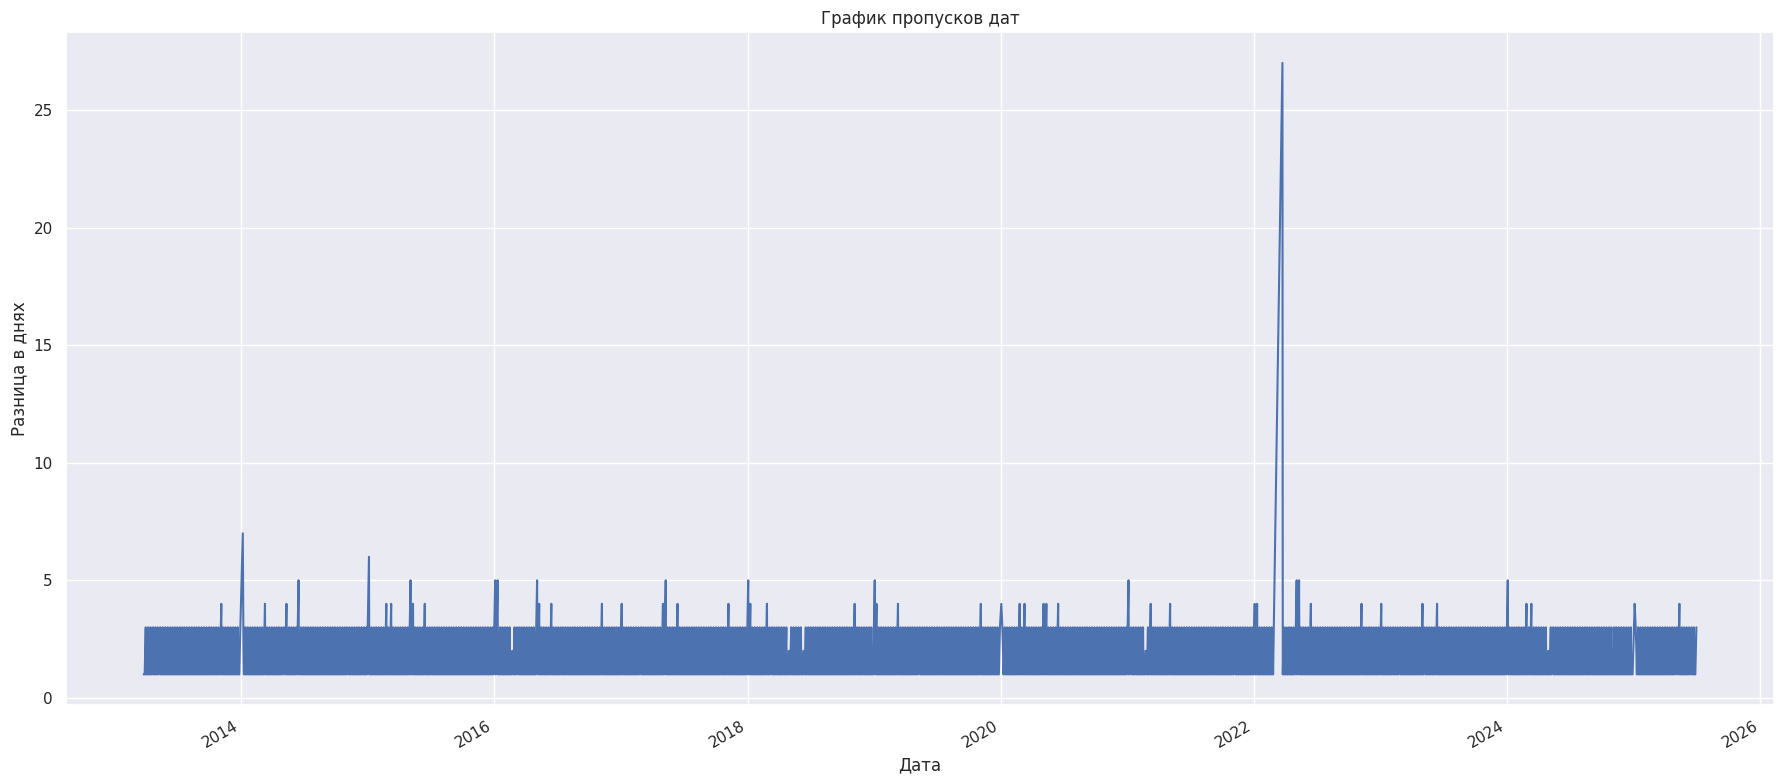

In [ ]:
# Проверяем, что индекс имеет тип datetime
if isinstance(df.index, pd.DatetimeIndex):
    # Если индекс уже datetime, сразу строим график
    df.index.to_series().diff().dt.days.plot(kind='line')
    plt.title('График пропусков дат')
    plt.ylabel('Разница в днях')
    plt.xlabel('Дата')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    # Если индекс не datetime, преобразуем его
    try:
        df.index = pd.to_datetime(df.index)
        # После преобразования строим график
        df.index.to_series().diff().dt.days.plot(kind='line')
        plt.title('График пропусков дат')
        plt.ylabel('Разница в днях')
        plt.xlabel('Дата')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Ошибка при преобразовании индекса: {e}")

### Удалим данные рядом с событием 24.02.2022

In [ ]:
# Определяем диапазон дат для удаления
start_date = '2022-02-22'
end_date = '2022-03-24'

# Создаем список дат для удаления
dates_to_drop = pd.date_range(start=start_date, end=end_date)

df = df.drop(dates_to_drop, errors='ignore')


In [ ]:
'''
# Определяем дату отсечения
cutoff_date = '2022-03-23'
df_orig = df.copy()
df = df[df.index > pd.to_datetime(cutoff_date)]
'''

"\n# Определяем дату отсечения\ncutoff_date = '2022-03-23'\ndf_orig = df.copy()\ndf = df[df.index > pd.to_datetime(cutoff_date)]\n"

In [ ]:
df.head()

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,admittedquote,mp2valtrd,marketprice3tradesvalue,admittedvalue,tradingsession,trendclspr
TRADEDATE,,,,,,,,,,,,,,,,,
2013-03-25,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1939.8,1.590845e+09,1.590845e+09,1.590845e+09,3,NaN
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1930.0,1.951925e+09,1.951925e+09,1.951925e+09,3,1.17
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,1947.9,2.411451e+09,2.411451e+09,2.411451e+09,3,1.30
2013-03-28,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1974.1,1.536170e+09,1.536170e+09,1.536170e+09,3,1.19
2013-03-29,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,1998.3,5.624588e+08,5.624588e+08,5.624588e+08,3,0.51


In [ ]:
df.shape

(3075, 17)

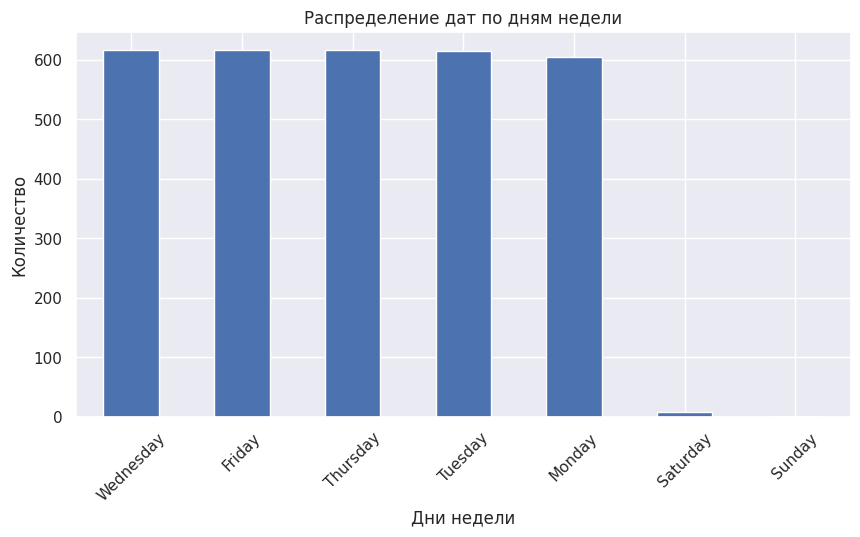

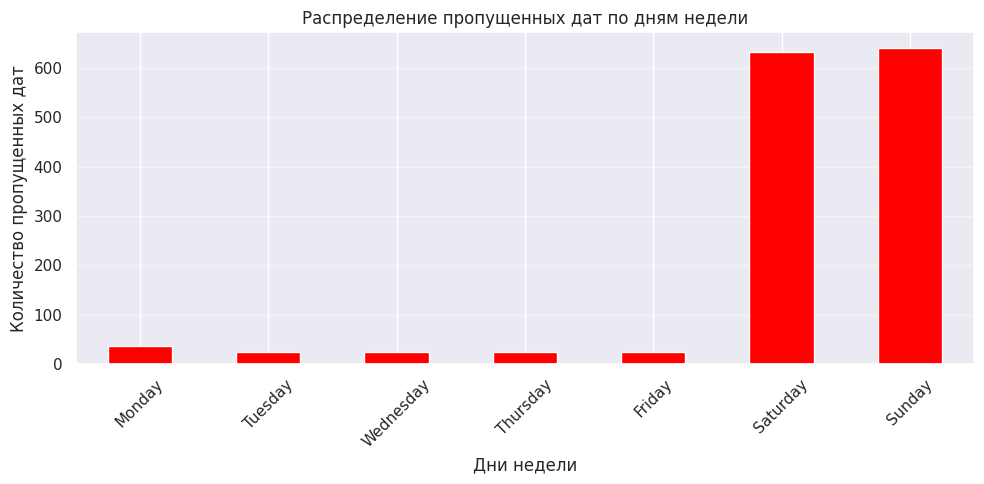

In [ ]:
# Создаем категориальный тип с нужным порядком
day_order = pd.CategoricalDtype(
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

# Преобразуем индекс в названия дней недели
day_names = df.index.day_name()

# Применяем категориальный тип
day_names = day_names.astype(day_order)

# Создаем график
day_names.value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('Распределение дат по дням недели')
plt.xlabel('Дни недели')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

# Создаем полный диапазон дат
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
# Находим пропущенные даты
missing_dates = full_date_range[~full_date_range.isin(df.index)]
# Создаем серию с пропущенными датами
missing_days = pd.Series(missing_dates.day_name()).astype(day_order)

# Строим график
missing_days.value_counts().sort_index().plot(kind='bar', color='red', figsize=(10,5))
plt.title('Распределение пропущенных дат по дням недели')
plt.xlabel('Дни недели')
plt.ylabel('Количество пропущенных дат')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

Будем решать задачу временного ряда

**Определим таргет как разницу значений цены закрытия завтрашнего дня и сегодняшнего.**

### Определение таргета

In [ ]:
df['target'] = df['close'].shift(-1) - df['close']
display(df.head(10))

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,admittedquote,mp2valtrd,marketprice3tradesvalue,admittedvalue,tradingsession,trendclspr,target
TRADEDATE,,,,,,,,,,,,,,,,,,
2013-03-25,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1939.8,1.590845e+09,1.590845e+09,1.590845e+09,3,NaN,22.5
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1930.0,1.951925e+09,1.951925e+09,1.951925e+09,3,1.17,25.2
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,1947.9,2.411451e+09,2.411451e+09,2.411451e+09,3,1.30,23.5
2013-03-28,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1974.1,1.536170e+09,1.536170e+09,1.536170e+09,3,1.19,10.2
2013-03-29,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,1998.3,5.624588e+08,5.624588e+08,5.624588e+08,3,0.51,-25.2
2013-04-01,177,41558417.2,1993.4,1978.2,1998.4,1976.6,1989.5,1978.2,20889,1986.8,1986.8,1986.8,1.011704e+09,1.011704e+09,1.011704e+09,3,-1.26,24.0
2013-04-02,65,13848330.2,1983.0,1982.9,2002.2,1989.4,1989.4,2002.2,6961,1987.6,1987.6,1987.6,9.593167e+08,9.593167e+08,9.593167e+08,3,1.21,-23.3
2013-04-03,97,25643878.3,1990.0,1976.0,2001.1,1973.8,1988.7,1978.9,12895,1984.9,1984.9,1984.9,1.568356e+09,1.568356e+09,1.568356e+09,3,-1.16,-12.0
2013-04-04,57,14390882.2,1970.0,1963.4,1984.3,1966.4,1970.8,1966.9,7302,1972.1,1972.1,1972.1,1.458952e+09,1.458952e+09,1.458952e+09,3,-0.61,-24.1


In [ ]:
df.shape

(3075, 18)

In [ ]:
def check_missing_values(df):
    # Проверяем наличие пропусков в каждой колонке
    missing = df.isnull().sum()

    # Выводим информацию о пропусках
    if missing.sum() > 0:
        print("Пропуски найдены в следующих колонках:")
        print(missing[missing > 0])
    else:
        print("Пропусков в датасете нет")

    return missing

check_missing_values(df)

Пропуски найдены в следующих колонках:
admittedquote    624
admittedvalue    624
trendclspr         1
target             1
dtype: int64


,0
numtrades,0
value,0
open,0
low,0
high,0
legalcloseprice,0
waprice,0
close,0
volume,0
marketprice2,0


Есть пропуски в столбцах admittedquote и admittedvalue - их можно заполнить, например, при помощи KNNImputer, или удалить столбцы совсем.
Принято решение удалить столбцы

In [ ]:
df = df.drop(['admittedquote', 'admittedvalue'], axis=1)

### Исследовательский анализ временного ряда

In [ ]:
df_copy = df.copy()
df_copy = df_copy[['close']]

In [ ]:
df_copy['close_diff'] = df['close'].shift(-1) - df['close']
df_copy = df_copy.dropna()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_copy['close_diff'])  # будем смотреть стационарность по разности цен закрытия

# Вывод результатов теста
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -53.508906
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567


Интерпретируем результаты теста Дики-Фуллера:

**ADF Statistic (значение теста)**: -9.592326. Это значение значительно меньше критических значений.

**p-value**: 0.000000. Это значение меньше общепринятых уровней значимости (например, 0.05 или 0.01), что указывает на наличие оснований отвергнуть нулевую гипотезу о наличии единичного корня (то есть ряд является стационарным).

Критические значения:

1%: -3.433
5%: -2.863
10%: -2.567

Значение ADF (-9.592326) значительно меньше всех критических значений. Это также подтверждает, что есть основания отвергнуть нулевую гипотезу.

**Вывод**: на основании данных результатов теста Дики-Фуллера можно заключить, что ряд является стационарным, так как есть достаточные основания отвергнуть нулевую гипотезу о наличии единичного корня.

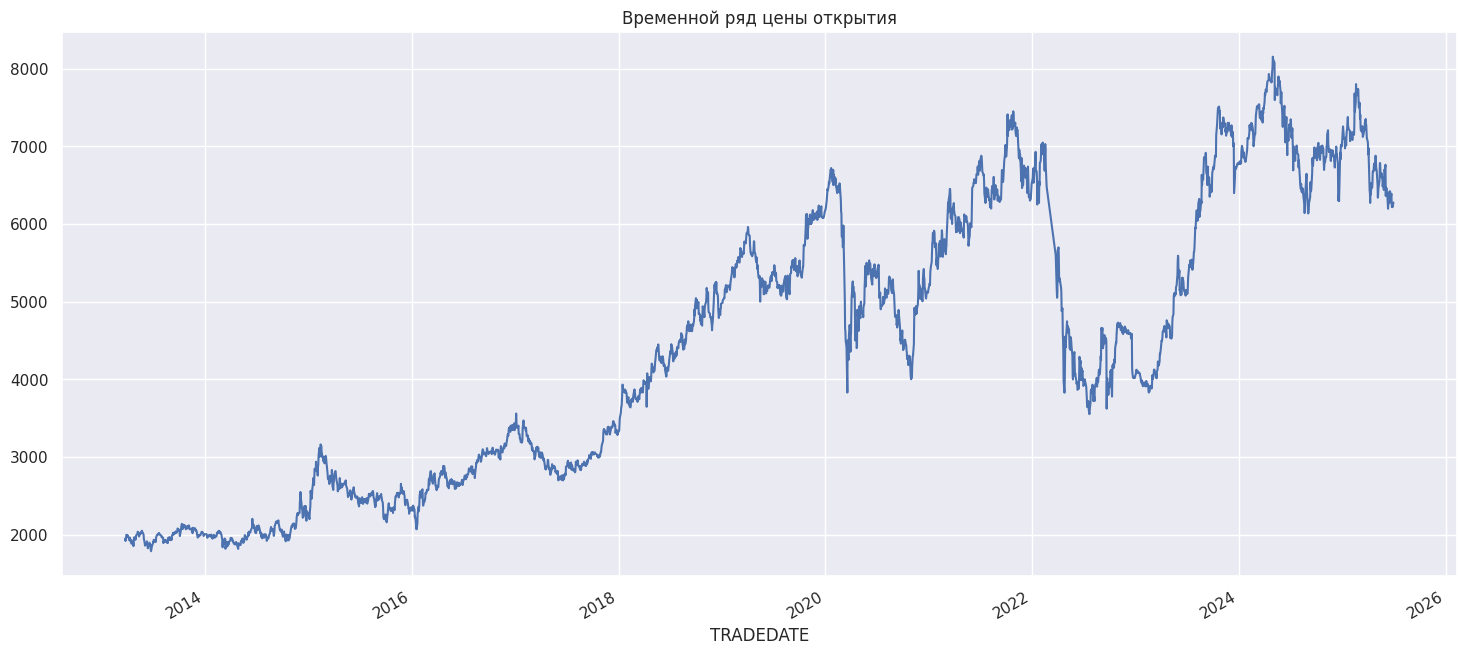

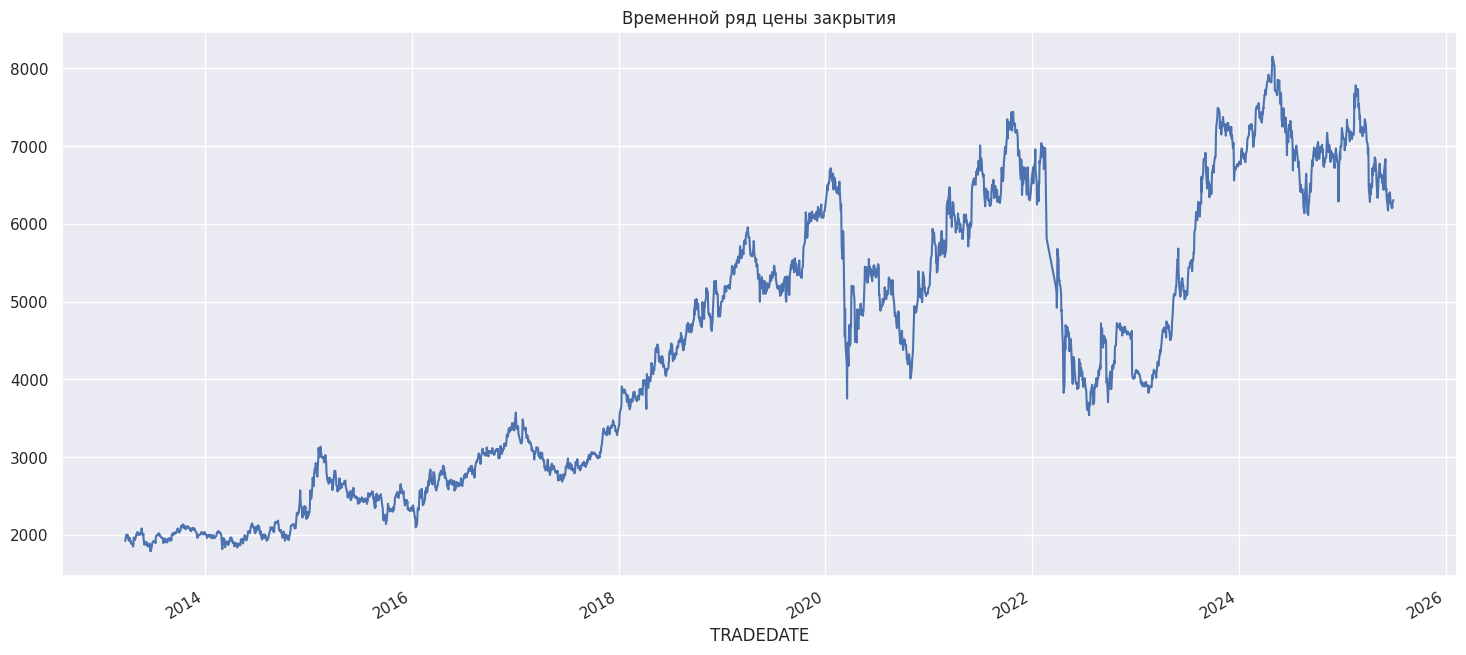

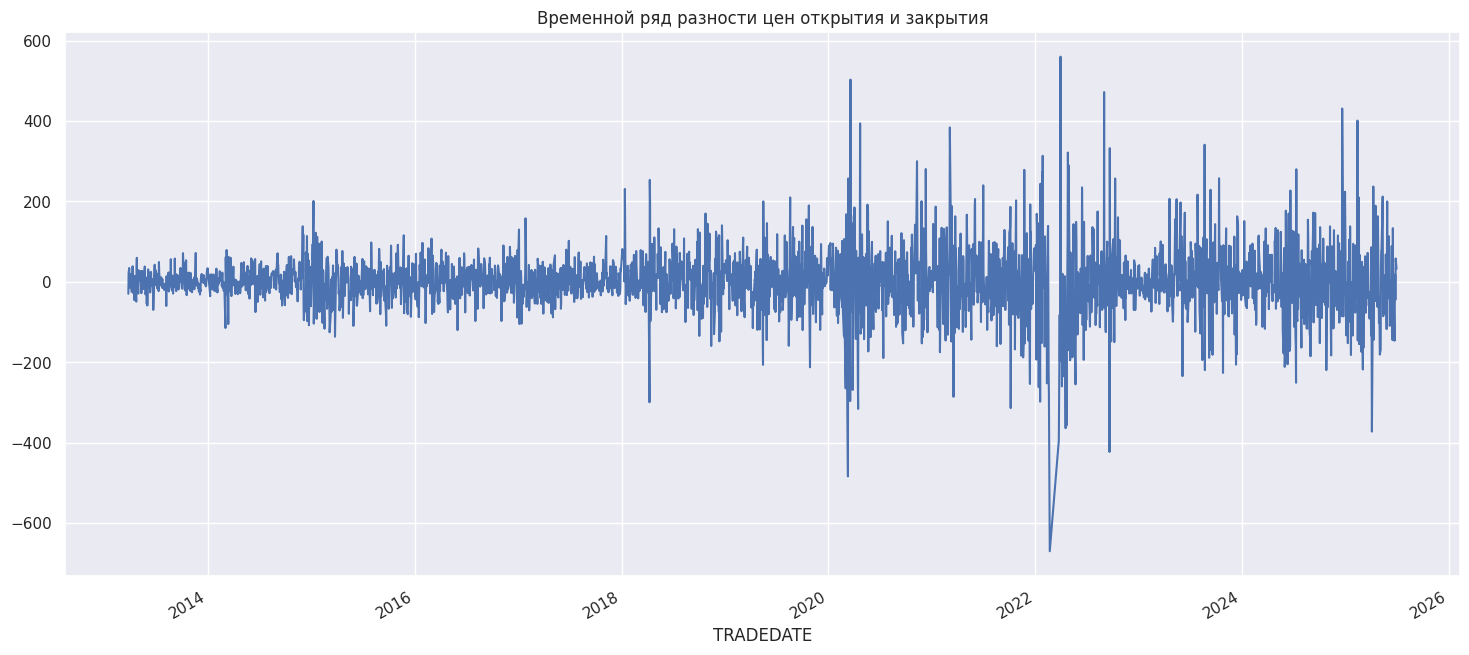

In [ ]:
df_copy = df.copy()
# строим графики изменения цен открытия и закрытия и разности цен
df_copy['open'].plot(title='Временной ряд цены открытия')
plt.show()
df_copy['close'].plot(title='Временной ряд цены закрытия')
plt.show()
df_copy['close_open'] = df_copy['close'] - df_copy['open']
df_copy['close_open'].plot(title='Временной ряд разности цен открытия и закрытия')
plt.show()

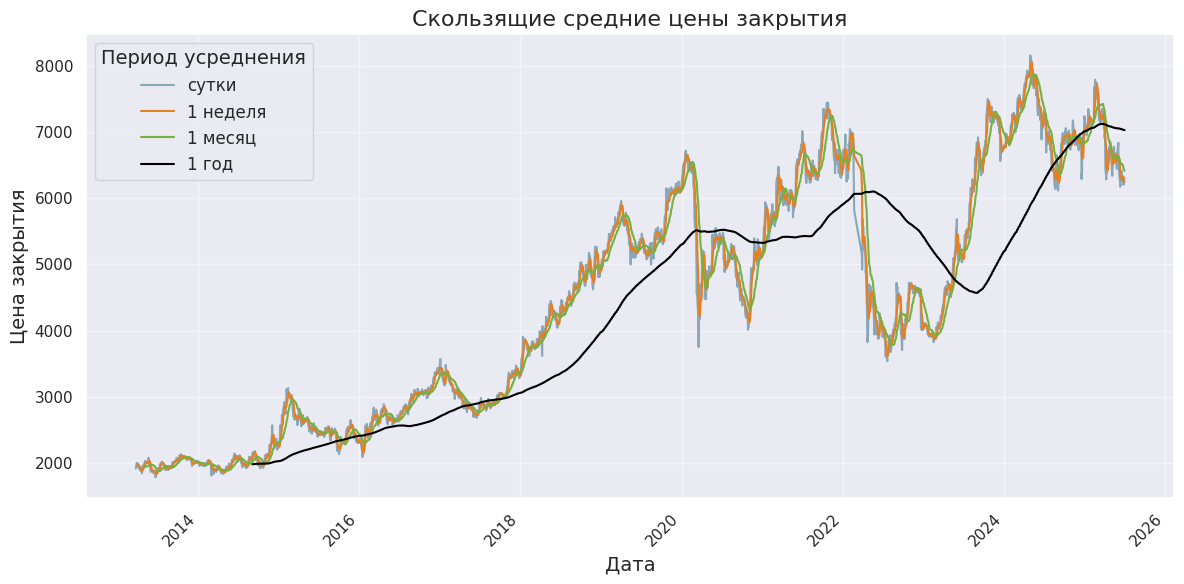

In [ ]:
plt.figure(figsize=(12, 6))

# График с разными цветами
df_copy['close'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['close'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')
df_copy['close'].rolling(29).mean().plot(color='#76B041', label='1 месяц')
df_copy['close'].rolling(365).mean().plot(color='black', label='1 год')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Скользящие средние цены закрытия', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Окно скользящего среднего приняла 24 часа (равное суткам) с целью убрать суточную сезонность\
Также построен график со скользящим средним 1 неделя (168 часов) с целью убрать и суточную и недельную сезонность\
И последний график показывает нам тренд за вычетом и месячной сезонности, общегодовой\
Эти графики, в целом, нам мало что дают, хотя общий тренд к увеличению цены закрытия мы здесь видим (с провалом в 2023 году).\


Смотреть более короткие периоды или периоды ближе к текущей дате не имеет смысла, поскольку задаче не предсказать ближайшее будущее, а научить модель предсказывать по данным сегодняшнего дня данные завтрашнего дня.

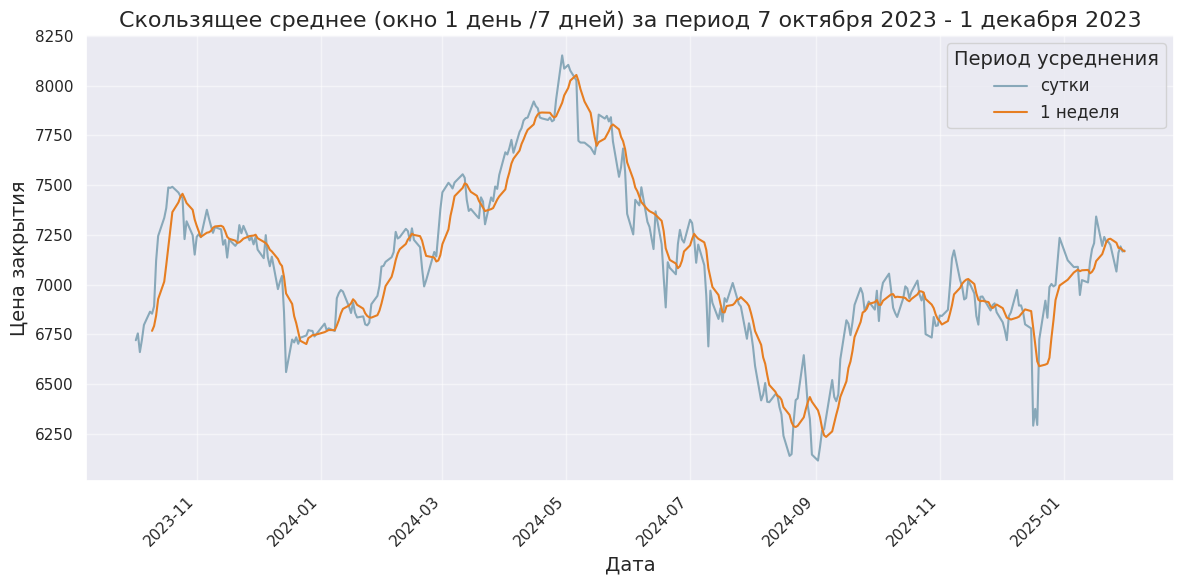

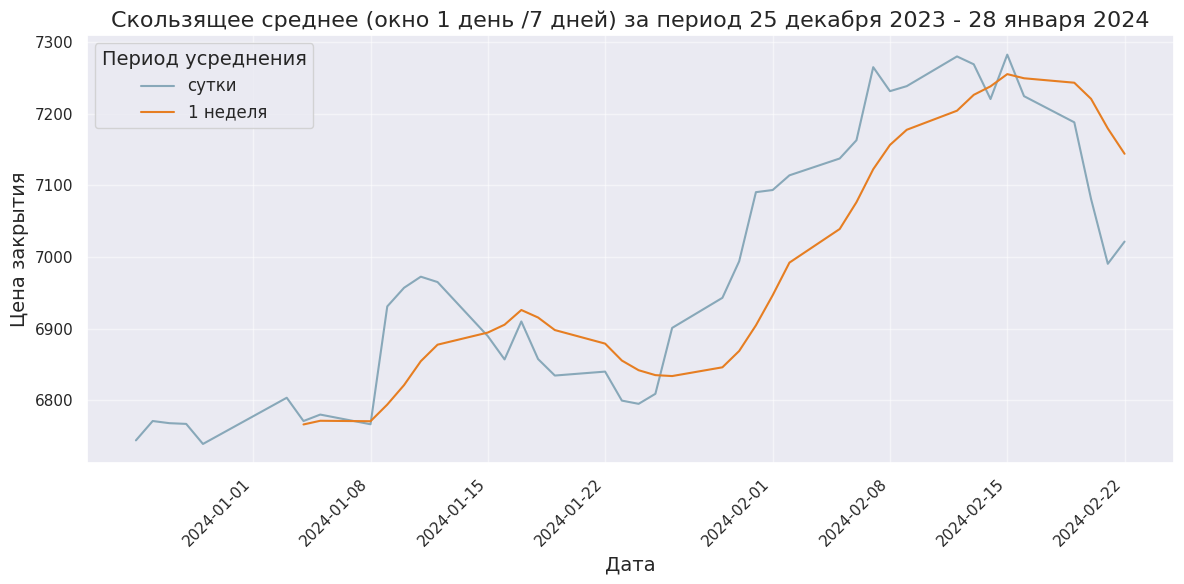

In [ ]:
plt.figure(figsize=(12, 6))

# График с разными цветами
df_copy['close']['2023-10-01':'2025-01-31'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['close']['2023-10-01':'2025-01-31'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Скользящее среднее (окно 1 день /7 дней) за период 7 октября 2023 - 1 декабря 2023', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

# График с разными цветами
df_copy['close']['2023-12-25':'2024-02-25'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['close']['2023-12-25':'2024-02-25'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Скользящее среднее (окно 1 день /7 дней) за период 25 декабря 2023 - 28 января 2024', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Cкользящее окно приняла равное суткам (все равно данные только за сутки) и неделю, чтобы посмотреть на коротком промежутке.
Каких-то определенных тенденций тут не наблюдается ни связанных с днем недели, ни с началом-кончом месяца.

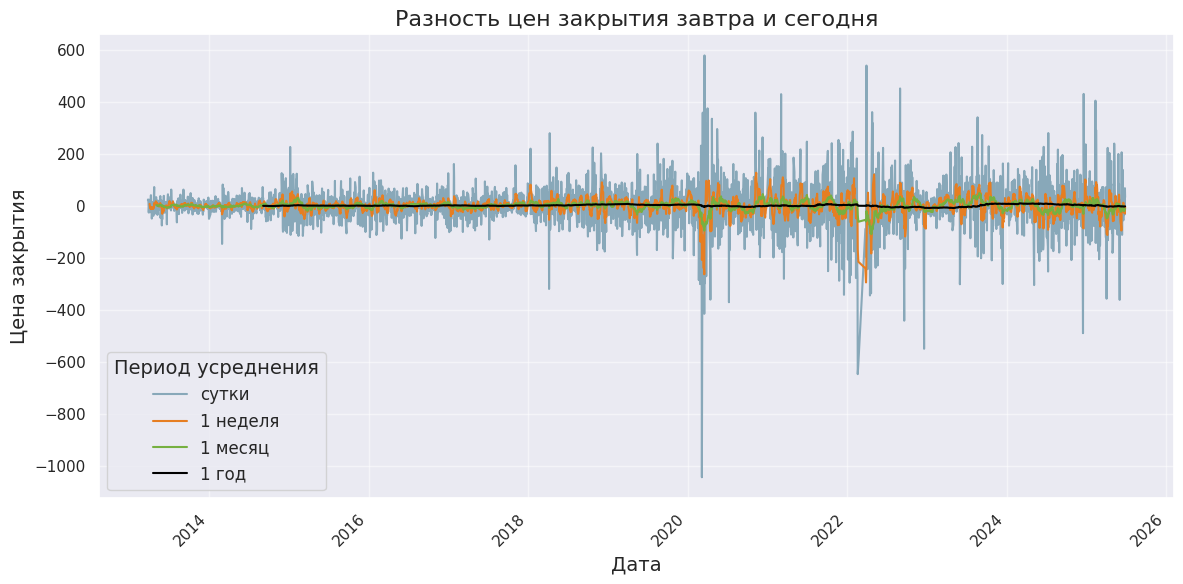

In [ ]:
plt.figure(figsize=(12, 6))

df_copy['price_diff'] = df_copy['close'].diff(-1) * -1  # Разница между следующей ценой и текущей
# График с разными цветами
df_copy['price_diff'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['price_diff'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')
df_copy['price_diff'].rolling(29).mean().plot(color='#76B041', label='1 месяц')
df_copy['price_diff'].rolling(365).mean().plot(color='black', label='1 год')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Разность цен закрытия завтра и сегодня', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Тоже не сделать каких-то выводов по сезонности.

## Создание новых признаков из признака "дата"

In [ ]:
# Проверяем тип индекса
if not isinstance(df.index, pd.DatetimeIndex):
    # Если индекс не datetime, преобразуем его
    df.index = pd.to_datetime(df.index)

# Преобразуем индекс в обычный столбец
df['date'] = df.index

# Проверяем формат нового столбца
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    # Если столбец все еще не datetime, преобразуем его
    df['date'] = pd.to_datetime(df['date'])

# Удаляем индекс, если он больше не нужен
#df = df.reset_index(drop=True)


In [ ]:
display(df.head(3))
print(df.shape)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,target,date
TRADEDATE,,,,,,,,,,,,,,,,,
2013-03-25,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,1.590845e+09,3,NaN,22.5,2013-03-25
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,1.951925e+09,3,1.17,25.2,2013-03-26
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,2.411451e+09,3,1.30,23.5,2013-03-27


(3075, 17)


In [ ]:
def extract_date_features(date):
    return {
        'day_of_week': date.dayofweek + 1,
        'day_of_month': date.day,
        'month': date.month,
        'year': date.year
    }

# Проверяем и преобразуем столбец date в datetime, если нужно
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    try:
        df['date'] = pd.to_datetime(df['date'])
    except Exception as e:
        print(f"Ошибка преобразования даты: {e}")
        print("Попробуйте указать формат даты, например:")
        # df'date' = pd.to_datetime(df'date', format='%Y-%m-%d')

# Создаем новый DataFrame с признаками
features_df = df['date'].apply(extract_date_features).apply(pd.Series)

# Добавляем новые столбцы в исходный DataFrame
df = pd.concat([df, features_df], axis=1)

def move_column_to_end(df, column):
    return df[[col for col in df.columns if col != column] + [column]]

# Использование:
df = move_column_to_end(df, 'target')
df.drop('date', axis=1, inplace=True)

In [ ]:
def move_column_to_end(df, column):
    return df[[col for col in df.columns if col != column] + [column]]

# Использование:
df = move_column_to_end(df, 'target')

In [ ]:
display(df.head(3))
print(df.shape)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,day_of_week,day_of_month,month,year,target
TRADEDATE,,,,,,,,,,,,,,,,,,,,
2013-03-25,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,1.590845e+09,3,NaN,1,25,3,2013,22.5
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,1.951925e+09,3,1.17,2,26,3,2013,25.2
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,2.411451e+09,3,1.30,3,27,3,2013,23.5


(3075, 20)


In [ ]:
def subplots_histplot_hue(df, nrows, title):
    fig, axes = plt.subplots(nrows=nrows, ncols=5, figsize=(13, 13))
    axes = axes.flatten()
    fig.suptitle(title)

    for i, col in enumerate(df):
        sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i])
        axes[i].set_title(f'Признак {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
'''
subplots_histplot_hue(
    df[list(df.columns)], 4,
    'Гистограммы признаков\n')
'''

"\nsubplots_histplot_hue(\n    df[list(df.columns)], 4,\n    'Гистограммы признаков\n')\n"

## Обучение моделей

### Деление датасета на выборки

In [ ]:
df.shape

(3075, 20)

In [ ]:
df = df.dropna()
df.shape

(3073, 20)

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>split_data_res_ind(df, target_column)
def split_data_res_ind(df, target_column):
    """
    Функция для разделения данных на обучающую и тестовую выборки с использованием стратификации.

    Параметры:
    df (pandas.DataFrame): исходный набор данных
    target_column (str): название столбца с целевыми значениями

    Должны быть определены константы
    TEST_SIZE (float): размер тестовой выборки (между 0 и 1)
    RANDOM_STATE (int): начальное значение для генератора случайных чисел

    Возвращает:
    X_train (pandas.DataFrame): обучающая выборка без столбца с целевыми значениями
    X_test (pandas.DataFrame): тестовая выборка без столбца с целевыми значениями
    y_train (pandas.Series): целевые значения для обучающей выборки
    y_test (pandas.Series): целевые значения для тестовой выборки
    """

    train, test = train_test_split(df, shuffle=False, test_size=TEST_SIZE)

    print(train.index.min(), train.index.max())
    print(test.index.min(), test.index.max(), '\n\n')

    X_train = train.drop([target_column], axis=1)
    y_train = train[target_column]
    X_test = test.drop([target_column], axis=1)
    y_test = test[target_column]

    print(X_train.shape, y_train.shape, '\n\n', X_test.shape, y_test.shape)

    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df, 'target')

2013-03-26 00:00:00 2024-04-11 00:00:00
2024-04-12 00:00:00 2025-06-27 00:00:00 


(2765, 19) (2765,) 

 (308, 19) (308,)


Все хорошо поделилось

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_class_distribution_train_test(y_train, y_test, target)
def plot_class_distribution_train_test(y_train, y_test, target):
    """
    Функция для создания графика распределения осложнений в обучающей и тестовой выборках.

    Параметры:
    y_train (pandas.DataFrame): Обучающая выборка данных.
    y_test (pandas.DataFrame): Тестовая выборка данных.
    target (str): Название столбца с данными об осложнениях.
    """

    # Создание DataFrame для обучающей и тестовой выборок
    train = pd.DataFrame(y_train, columns=[target])
    test = pd.DataFrame(y_test, columns=[target])

    # Подготовка графиков
    fig, ax = plt.subplots(figsize=(6, 4))

    # Построение графиков для обучающей и тестовой выборок
    sns.countplot(data=train, y=target, alpha=.5, ax=ax)
    sns.countplot(data=test, y=target, alpha=1, ax=ax)

    # Добавление заголовка к графику
    ax.set_title('Разделение по классам')

    # Отображение графика
    plt.show()

### Baseline & Dummy

In [ ]:
# Create CatBoost pools for training and testing
train_pool = Pool(data=X_train, label=y_train,

                  )
test_pool = Pool(data=X_test, label=y_test,
                 #cat_features=categorical_featurs
                 )

# Обучение модели CatBoost
model = CatBoostRegressor()
model.fit(train_pool)

Learning rate set to 0.04808
0:	learn: 81.3234065	total: 50.2ms	remaining: 50.2s
1:	learn: 81.1262009	total: 55ms	remaining: 27.4s
2:	learn: 80.9168842	total: 57.6ms	remaining: 19.1s
3:	learn: 80.7774955	total: 60.2ms	remaining: 15s
4:	learn: 80.6336071	total: 62.7ms	remaining: 12.5s
5:	learn: 80.4511708	total: 65.4ms	remaining: 10.8s
6:	learn: 80.3635923	total: 68ms	remaining: 9.64s
7:	learn: 80.2513180	total: 70.7ms	remaining: 8.76s
8:	learn: 80.0753465	total: 73.3ms	remaining: 8.07s
9:	learn: 79.9011648	total: 76ms	remaining: 7.53s
10:	learn: 79.7857433	total: 78.6ms	remaining: 7.07s
11:	learn: 79.6684068	total: 81.1ms	remaining: 6.67s
12:	learn: 79.5388537	total: 83.6ms	remaining: 6.34s
13:	learn: 79.3796026	total: 86ms	remaining: 6.06s
14:	learn: 79.2504638	total: 88.6ms	remaining: 5.82s
15:	learn: 79.0915662	total: 91.1ms	remaining: 5.6s
16:	learn: 79.0127042	total: 93.8ms	remaining: 5.42s
17:	learn: 78.8757973	total: 96.4ms	remaining: 5.26s
18:	learn: 78.7739967	total: 102ms	rem

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Оценка качества модели
predictions = model.predict(test_pool)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, predictions)
print("MAE для Baseline модели:", round(mae, 3))

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE для Baseline модели:", round(rmse, 3))

# R² (R-squared)
r2 = r2_score(y_test, predictions)
print("R² для Baseline модели:", round(r2, 3))

MAE для Baseline модели: 87.164
RMSE для Baseline модели: 116.537
R² для Baseline модели: -0.152


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_residuals(y_test, predictions)
def plot_residuals(y_test, predictions):
    """
    Функция для визуализации остатков модели

    Параметры:
    y_test (array-like): истинные значения
    predictions (array-like): предсказанные значения
    """
    # Вычисляем остатки
    residuals = y_test - predictions

    # Создаем фигуру с двумя графиками
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # График рассеяния предсказаний и остатков
    axes[0].scatter(predictions, residuals)
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_xlabel('Предсказанные значения')
    axes[0].set_ylabel('Остатки')
    axes[0].set_title('График остатков')

    # Временной ряд остатков
    axes[1].plot(residuals)
    axes[1].set_title('Временной ряд остатков')
    axes[1].set_xlabel('Время')
    axes[1].set_ylabel('Остатки')

    # Отображаем графики
    plt.tight_layout()
    plt.show()

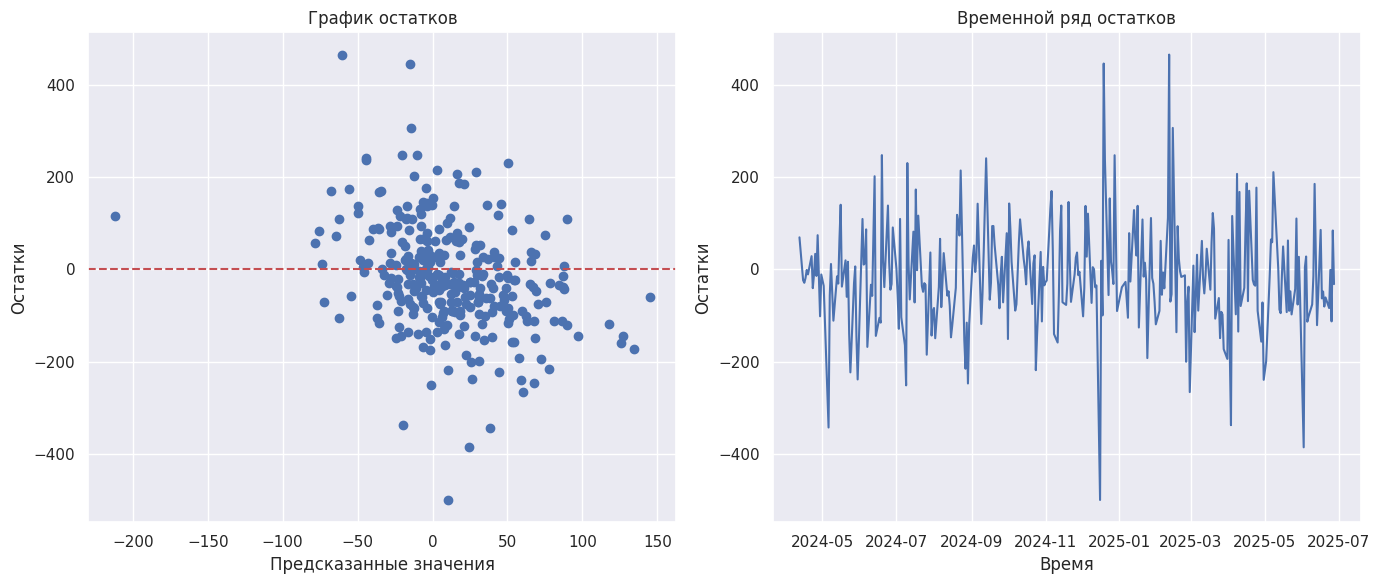

In [ ]:
plot_residuals(y_test, predictions)

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_feature_importance(model, X_test)
def plot_feature_importance(model, X_test):
    """
    Функция для построения графика важности признаков модели.

    Параметры:
    model (объект модели): обученная модель, из которой извлекаются значения важности признаков.
    X_test_base (pandas.DataFrame): DataFrame с признаками для тестирования.
    """

    # Определение данных для графика
    plot_data = {
        'features': X_test.columns,
        'feature_importances': model.feature_importances_,
    }

    # Преобразование в DataFrame
    plot_data = pd.DataFrame(plot_data)

    # Фильтрация признаков с положительными значениями важности
    plot_data = plot_data[plot_data['feature_importances'] > 0]

    # Сортировка по убыванию важности признаков
    plot_data.sort_values(by='feature_importances', ascending=False, inplace=True)

    # Настройка и построение графика
    plt.figure(figsize=(10, 5))
    sns.barplot(x='feature_importances', y='features', data=plot_data)

    # Добавление заголовка
    plt.title('Важность признаков модели \n', fontsize=14, fontweight="bold")

    # Отображение графика
    plt.show()

    # Сброс стилей Seaborn к исходным
    sns.reset_orig()

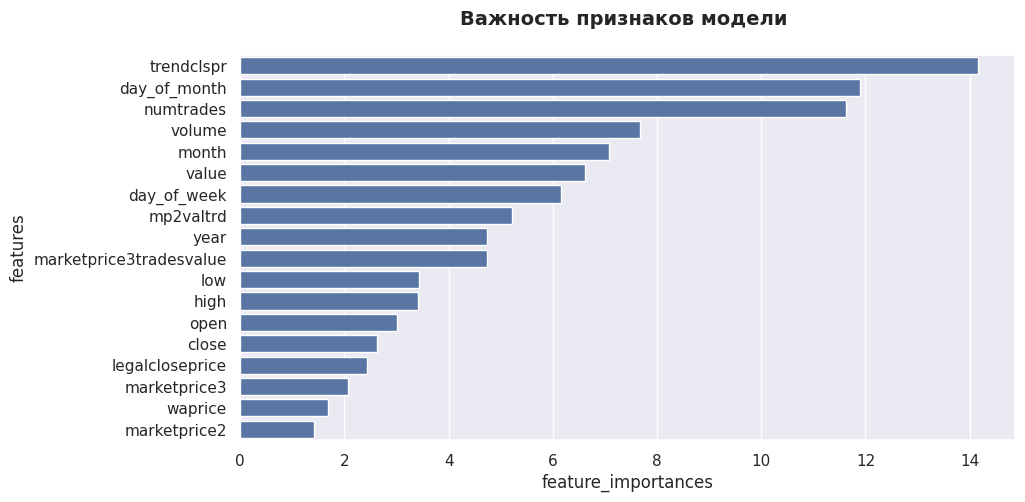

In [ ]:
plot_feature_importance(model, X_test)

In [ ]:
# Инициализация и обучение DummyRegressor
dummy_mean = DummyRegressor()
dummy_mean.fit(X_train, y_train)

# Прогнозирование на тестовых данных и вычисление F1-score
dummy_prediction = dummy_mean.predict(X_test)


# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, dummy_prediction)
print("MAE для Dummy модели:", round(mae, 3))

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, dummy_prediction))
print("RMSE для Dummy модели:", round(rmse, 3))

# R² (R-squared)
r2 = r2_score(y_test, dummy_prediction)
print("R² для Dummy модели:", round(r2, 3))

MAE для Dummy модели: 79.989
RMSE для Dummy модели: 108.828
R² для Dummy модели: -0.004


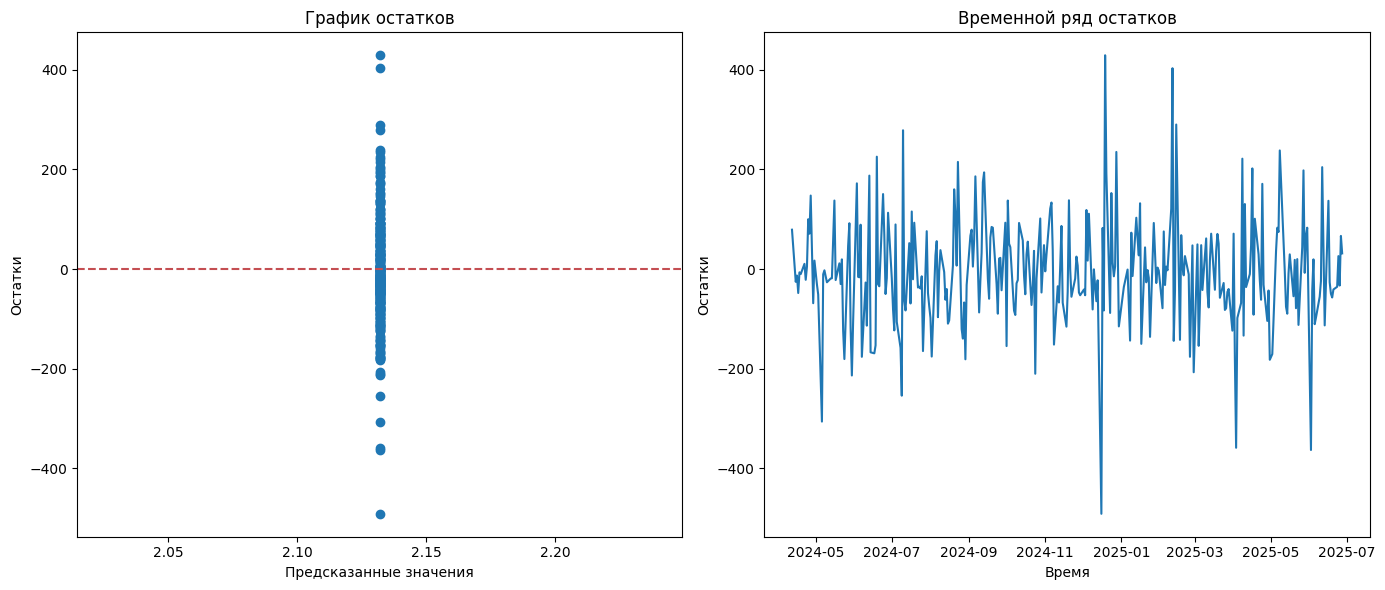

In [ ]:
plot_residuals(y_test, dummy_prediction)

Базовая модель по метрикам значительно хуже простого Dummy-регрессора, который записывает все равным значению около 2,21. Хотя мы видим, что Dummy ничего не угадывает, просто предсказывает некую среднюю разницу.

Ну, есть, к чему стремиться.

### Функции для обучения моделей.

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>find_best_models
def find_best_models(X_train, y_train, X_test, y_test, models_params):
    '''
    Функция выполняет поиск лучшей модели для временных рядов
    с использованием скейлера и метрик MAE, RMSE, R²
    '''
    best_models = []

    for model_name, (model, params) in models_params.items():
        # Создаем пайплайн со скейлером
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        gs_model = GridSearchCV(
            pipeline,
            params,
            cv=5,
            scoring='r2',  # Используем MAE для оценки
            n_jobs=-1
        )
        gs_model.fit(X_train, y_train)

        best_score = gs_model.best_score_
        best_estimator = gs_model.best_estimator_
        best_params = gs_model.best_params_

        # Метрики на обучающей выборке
        y_pred_train = best_estimator.predict(X_train)
        mae_train = mean_absolute_error(y_train, y_pred_train)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        r2_train = r2_score(y_train, y_pred_train)

        # Метрики на тестовой выборке
        y_pred = best_estimator.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Сохраняем результаты
        best_models.append({
            'model_name': model_name,
            'best_estimator': best_estimator,
            'best_params': best_params,
            'best_score_cv': best_score,
            'mae_train': mae_train,
            'mae': mae,
            'rmse_train': rmse_train,
            'rmse': rmse,
            'r2_train': r2_train,
            'r2': r2
        })

        print(f'{model_name}:')
        print(f'R² на кросс-валидации: {best_score:.3f}')
        print(f'MAE на трейне: {mae_train:.3f}')
        print(f'MAE на тесте: {mae:.3f}')
        print(f'RMSE на трейне: {rmse_train:.3f}')
        print(f'RMSE на тесте: {rmse:.3f}')
        print(f'R² на трейне: {r2_train:.3f}')
        print(f'R² на тесте: {r2:.3f}')
        print("Лучшая модель:", best_estimator)
        print('-'*40)

    return best_models

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>create_results_dataframe(best_models_list)
# Объявляем глобальную переменную
results_data = []

def create_results_dataframe(best_models_list):
    global results_data  # Указываем, что используем глобальную переменную


    for model_info in best_models_list:
        results_data.append({
            'Model': model_info['model_name'],
            'Best Model': model_info['best_estimator'],
            'Best params': model_info['best_params'],
            'R² CV': f"{model_info['best_score_cv']:.3f}",
            'MAE TRAIN': f"{model_info['mae_train']:.3f}",
            'MAE TEST': f"{model_info['mae']:.3f}",
            'RMSE TRAIN': f"{model_info['rmse_train']:.3f}",
            'RMSE TEST': f"{model_info['rmse']:.3f}",
            'R² TRAIN': f"{model_info['r2_train']:.3f}",
            'R² TEST': f"{model_info['r2']:.3f}"
        })

    return pd.DataFrame(results_data)


In [ ]:
'''
# @title <font color='#4189ab'>def <font color='#d98007'>find_best_model(results_data)
# Объявляем глобальную переменную
best_model = None

def find_best_model(results_data):
    """
    Функция для поиска лучшей модели по метрике R²E CV

    Параметры:
    results_data (list/dict): данные с результатами моделей

    Возвращает:
    best_model: модель с минимальным значением R² CV
    """
    global best_model  # Указываем, что используем глобальную переменную

    try:
        # Проверяем входные данные
        if not results_data:
            raise ValueError("Входные данные пустые")

        # Создаем DataFrame из входных данных
        result_df = pd.DataFrame(results_data)

        # Проверяем наличие необходимых столбцов
        required_columns = ['R² CV', 'Best Model']
        missing_columns = [col for col in required_columns if col not in result_df.columns]
        if missing_columns:
            raise KeyError(f"Отсутствуют необходимые столбцы: {missing_columns}")

        # Определяем метрики для анализа
        metrics_columns = ['R² CV', 'MAE TEST', 'RMSE TRAIN', 'RMSE TEST', 'R² TRAIN', 'R² TEST']

        # Преобразуем все метрики в числовой формат
        for column in metrics_columns:
            if column in result_df.columns:
                result_df[column] = pd.to_numeric(result_df[column], errors='coerce')
                # Проверяем на NaN значения
                if result_df[column].isna().any():
                    print(f"Предупреждение: обнаружены NaN значения в столбце {column}")

        # Удаляем строки с NaN в MAE CV
        result_df = result_df.dropna(subset=['R² CV'])

        # Проверяем, остались ли данные после очистки
        if result_df.empty:
            raise ValueError("После очистки данных DataFrame пуст")



        # Находим индекс строки с минимальной метрикой MAE CV
        best_model_index = np.argmax(result_df['R² TEST'])

        # Получаем лучшую модель
        best_model = result_df.loc[best_model_index, 'Best Model']

        # Выводим результаты
        print(f"Лучшая модель: {best_model}")
        print(f"Характеристики лучшей модели:")
        print(f"R² CV: {result_df.loc[best_model_index, 'R² CV']:.3f}")
        print(f"MAE TEST: {result_df.loc[best_model_index, 'MAE TEST']:.3f}")
        print(f"RMSE TEST: {result_df.loc[best_model_index, 'RMSE TEST']:.3f}")
        print(f"R² TEST: {result_df.loc[best_model_index, 'R² TEST']:.3f}")

        return best_model

    except Exception as e:
        print(f"Ошибка при поиске лучшей модели: {e}")
        return None
'''

'\n# @title <font color=\'#4189ab\'>def <font color=\'#d98007\'>find_best_model(results_data)\n# Объявляем глобальную переменную\nbest_model = None\n\ndef find_best_model(results_data):\n    """\n    Функция для поиска лучшей модели по метрике R²E CV\n\n    Параметры:\n    results_data (list/dict): данные с результатами моделей\n\n    Возвращает:\n    best_model: модель с минимальным значением R² CV\n    """\n    global best_model  # Указываем, что используем глобальную переменную\n\n    try:\n        # Проверяем входные данные\n        if not results_data:\n            raise ValueError("Входные данные пустые")\n\n        # Создаем DataFrame из входных данных\n        result_df = pd.DataFrame(results_data)\n\n        # Проверяем наличие необходимых столбцов\n        required_columns = [\'R² CV\', \'Best Model\']\n        missing_columns = [col for col in required_columns if col not in result_df.columns]\n        if missing_columns:\n            raise KeyError(f"Отсутствуют необходимые 

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>find_best_model(results_data)
# Объявляем глобальную переменную
best_model = None

def find_best_model(results_data):
    """
    Функция для поиска лучшей модели по метрике R²E CV

    Параметры:
    results_data (list/dict): данные с результатами моделей

    Возвращает:
    best_model: модель с минимальным значением R² CV
    """
    global best_model  # Указываем, что используем глобальную переменную

    try:
        # Проверяем входные данные
        if not results_data:
            raise ValueError("Входные данные пустые")

        # Создаем DataFrame из входных данных
        result_df = pd.DataFrame(results_data)

        # Проверяем наличие необходимых столбцов
        required_columns = ['R² CV', 'Best Model']
        missing_columns = [col for col in required_columns if col not in result_df.columns]
        if missing_columns:
            raise KeyError(f"Отсутствуют необходимые столбцы: {missing_columns}")

        # Определяем метрики для анализа
        metrics_columns = ['R² CV', 'MAE TEST', 'RMSE TRAIN', 'RMSE TEST', 'R² TRAIN', 'R² TEST']

        # Преобразуем все метрики в числовой формат
        for column in metrics_columns:
            if column in result_df.columns:
                result_df[column] = pd.to_numeric(result_df[column], errors='coerce')
                # Проверяем на NaN значения
                if result_df[column].isna().any():
                    print(f"Предупреждение: обнаружены NaN значения в столбце {column}")

        # Удаляем строки с NaN в R² CV
        result_df = result_df.dropna(subset=['R² CV'])

        # Фильтруем строки с отрицательными значениями R² CV
        result_df = result_df[result_df['R² CV'] >= 0]

        # Проверяем, остались ли данные после очистки
        if result_df.empty:
            raise ValueError("После очистки данных DataFrame пуст или все значения R² CV отрицательные")

        # Проверяем, что R² TEST не пустой
        if 'R² TEST' not in result_df.columns or result_df['R² TEST'].isna().all():
            raise ValueError("Столбец R² TEST пуст или содержит только NaN значения")

        # Находим индекс строки с максимальной метрикой R² TEST
        best_model_index = result_df['R² TEST'].idxmax()

        # Получаем лучшую модель
        best_model = result_df.loc[best_model_index, 'Best Model']

        # Выводим результаты
        print(f"Лучшая модель: {best_model}")
        print(f"Характеристики лучшей модели:")
        print(f"R² CV: {result_df.loc[best_model_index, 'R² CV']:.3f}")
        print(f"MAE TEST: {result_df.loc[best_model_index, 'MAE TEST']:.3f}")
        print(f"RMSE TEST: {result_df.loc[best_model_index, 'RMSE TEST']:.3f}")
        print(f"R² TEST: {result_df.loc[best_model_index, 'R² TEST']:.3f}")

        return best_model

    except Exception as e:
        print(f"Произошла ошибка: {e}")
        return None

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>save_results(best_model, filename='best_model.pkl')
# Функция для сохранения результатов
def save_results(best_model, filename='best_model.pkl'):
    joblib.dump(best_model, filename)
    print(f"Результаты сохранены в файл: {filename}")
# Функция для загрузки результатов
def load_results(filename='best_models.pkl'):
    return joblib.load(filename)

# Пример использования:
# loaded_models = load_results()
# analyze_results(loaded_models)

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>dummy_precision_score(X_train, y_train, X_test, y_test)
def dummy_precision_score(X_train, y_train, X_test, y_test):
    """
    Функция для вычисления precision-score для DummyClassifier.

    Параметры:
    X_train (pandas.DataFrame): Обучающие данные.
    y_train (pandas.Series): Обучающие метки.
    X_test (pandas.DataFrame): Тестовые данные.
    y_test (pandas.Series): Тестовые метки.

    Возвращает:
    float: precision-score для DummyClassifier.
    """

    # Инициализация и обучение DummyClassifier
    dummy_mean = DummyClassifier()
    dummy_mean.fit(X_train, y_train)

    # Прогнозирование на тестовых данных и вычисление F1-score
    dummy_prediction = dummy_mean.predict(X_test)
    precision_dummy = precision_score(y_test, dummy_prediction, average='macro')

    # Округление и вывод результата
    precision_dummy = round(abs(precision_dummy), 3)
    print(f'F1 Macro DummyClassifier = {precision_dummy}')

    return precision_dummy


## Feature Engineering

In [ ]:
df.head(1)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,day_of_week,day_of_month,month,year,target
TRADEDATE,,,,,,,,,,,,,,,,,,,,
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,1.951925e+09,3,1.17,2,26,3,2013,25.2


In [ ]:
df['close/open']  = df['close'] / df['open'] # столбец отношения цен закрытия и открытия.
df['high/low']  = df['high'] / df['low']
# df['tendency'] = (df['close-open'] > 0).astype(int) # если нет столбца trendclspr - но он есть
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)

In [ ]:
df['open_tomorrow/close_today'] = df['open'].shift(-1) / df['close']

In [ ]:
# Технические индикаторы
def calculate_rsi(series, period=14):
    delta = series.diff().dropna()
    up, down = delta.copy(), delta.copy()
    up[up < 0] = 0
    down[down > 0] = 0
    gain = up.ewm(com=period-1, min_periods=period).mean()
    loss = down.abs().ewm(com=period-1, min_periods=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(series, fastperiod=12, slowperiod=26, signalperiod=9):
    exp1 = series.ewm(span=fastperiod, adjust=False).mean()
    exp2 = series.ewm(span=slowperiod, adjust=False).mean()
    macd = exp1 - exp2
    signal = macd.ewm(span=signalperiod, adjust=False).mean()
    return macd, signal

In [ ]:
# RSI (Relative Strength Index) - индекс относительной силы
# Показывает силу текущего тренда и возможность его разворота
# Значения от 0 до 100, обычно используется для определения перекупленности/перепроданности
df['RSI'] = calculate_rsi(df['close'])

# MACD (Moving Average Convergence Divergence) - схождение/расхождение скользящих средних
# Помогает определить направление тренда и возможные точки входа/выхода
# Состоит из двух линий: MACD и сигнальной линии
df['MACD'], df['MACD_Signal'] = calculate_macd(df['close'])

# Скользящие средние
# SMA_5 - простая скользящая средняя за 5 периодов
# Используется для определения краткосрочного тренда
df['SMA_5'] = df['close'].rolling(window=5).mean()

# EMA_20 - экспоненциальная скользящая средняя за 20 периодов
# Более чувствительна к последним данным, чем SMA
# Помогает определить среднесрочный тренд
df['EMA_20'] = df['close'].ewm(span=20).mean()

# Показатели изменения цен
# Daily_Return - дневной процентный прирост/снижение цены
# Показывает относительное изменение цены закрытия
df['Daily_Return'] = df['close'].pct_change()

# Log_Return - логарифмическая доходность
# Используется для более точной оценки сложных процентов
# Особенно полезен при работе с долгосрочными временными рядами
df['Log_Return'] = np.log(df['close'] / df['close'].shift(1))

# Временные паттерны
# Is_Weekend - индикатор выходных дней
# Принимает значение 1 если день суббота (5) или воскресенье (6), иначе 0
df['Is_Weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Is_Month_End - индикатор конца месяца
# Принимает значение True если день является последним в месяце
df['Is_Month_End'] = df['day_of_month'] == df['day_of_month'].max()

# Объемные показатели
# Volume_MA - скользящая средняя объема торгов
# Помогает определить изменения в активности трейдеров
# Используется для подтверждения силы тренда
df['Volume_MA'] = df['volume'].rolling(window=10).mean()

In [ ]:
# Заменяем оставшиеся NaN на среднее значение или предыдущее значение
df['RSI'] = df['RSI'].fillna(method='ffill')  # заполняем предыдущими значениями

In [ ]:
def calculate_adx(df, period=14):
    # Создаем временные колонки для расчетов
    df['HL'] = df['high'] - df['low']
    df['HC'] = np.abs(df['high'] - df['close'].shift(1))
    df['LC'] = np.abs(df['low'] - df['close'].shift(1))

    # Расчет +DM и -DM
    df['+DM'] = np.where(
        (df['high'] - df['high'].shift(1)) > (df['low'].shift(1) - df['low']),
        df['high'] - df['high'].shift(1),
        0
    )

    df['-DM'] = np.where(
        (df['low'].shift(1) - df['low']) > (df['high'] - df['high'].shift(1)),
        df['low'].shift(1) - df['low'],
        0
    )

    # Обработка случаев равенства +DM и -DM
    df['+DM'] = np.where(df['+DM'] == df['-DM'], 0, df['+DM'])
    df['-DM'] = np.where(df['+DM'] == df['-DM'], 0, df['-DM'])

    # Расчет True Range
    df['TR'] = df[['HL', 'HC', 'LC']].max(axis=1)

    # Сглаживание значений
    df['SMMA_TR'] = df['TR'].rolling(window=period).sum()
    df['SMMA_PDM'] = df['+DM'].rolling(window=period).sum()
    df['SMMA_NDM'] = df['-DM'].rolling(window=period).sum()

    # Расчет DI
    df['+DI'] = (df['SMMA_PDM'] / df['SMMA_TR']) * 100
    df['-DI'] = (df['SMMA_NDM'] / df['SMMA_TR']) * 100

    # Расчет DX
    df['DX'] = (np.abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])) * 100

    # Расчет ADX и добавление в исходный DataFrame
    df['adx'] = df['DX'].rolling(window=period).mean()

    # Удаляем вспомогательные колонки (опционально)
    df.drop(columns=['HL', 'HC', 'LC', 'SMMA_TR', 'SMMA_PDM', 'SMMA_NDM', 'DX',
                     '+DI', '-DI', '+DI', '-DI', 'TR', '+DM', '-DM'], inplace=True)

    return df

In [ ]:
df = calculate_adx(df)

In [ ]:
# Заменяем оставшиеся NaN на среднее значение или предыдущее значение
df['adx'] = df['adx'].fillna(method='ffill')  # заполняем предыдущими значениями

In [ ]:
# Перенос таргета в конец:
df = move_column_to_end(df, 'target')

In [ ]:
df.head(5)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,...,RSI,MACD,MACD_Signal,SMA_5,EMA_20,Daily_Return,Log_Return,Is_Weekend,Is_Month_End,Volume_MA,adx,target
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,...,NaN,0.000000,0.000000,NaN,1944.500000,NaN,NaN,0,False,NaN,NaN,25.2
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,...,NaN,2.010256,0.402051,NaN,1957.730000,0.012960,0.012876,0,False,NaN,NaN,23.5
2013-03-28,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1.536170e+09,...,NaN,5.436979,1.409037,NaN,1970.754371,0.011931,0.011860,0,False,NaN,NaN,10.2
2013-03-29,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,5.624588e+08,...,NaN,8.873448,2.901919,NaN,1980.178660,0.005117,0.005104,1,False,NaN,NaN,-25.2
2013-04-01,177,41558417.2,1993.4,1978.2,1998.4,1976.6,1989.5,1978.2,20889,1986.8,1986.8,1.011704e+09,...,NaN,9.454460,4.212427,1977.8,1979.700039,-0.012579,-0.012658,0,False,NaN,NaN,24.0


In [ ]:
# Функция для создания признаков:
def make_features(data, max_lag, rolling_mean_size):
    df['dayofweek'] = df.index.dayofweek

    # численные признаки
    data['units'] = data.volume/data.close

    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['close'].shift(lag)

    df['rolling_mean'] = df['close'].shift().rolling(rolling_mean_size).mean()
    #data = data.dropna()

In [ ]:
make_features(df, 168, 168)

In [ ]:
df.head()

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,...,lag_158,lag_159,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-28,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1.536170e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-03-29,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,5.624588e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-04-01,177,41558417.2,1993.4,1978.2,1998.4,1976.6,1989.5,1978.2,20889,1986.8,1986.8,1.011704e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,...,lag_158,lag_159,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-23,78905,5.561637e+09,6388.5,6230.0,6390.0,6305.5,6308.0,6242.0,881606,6300.0,6300.0,3.268677e+09,...,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6958.5,6920.0,6950.0,6910.485119
2025-06-24,85467,5.520766e+09,6245.0,6110.0,6247.5,6177.5,6166.0,6208.5,895184,6154.5,6154.5,3.990248e+09,...,6996.5,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6958.5,6920.0,6906.270833
2025-06-25,57169,2.863135e+09,6218.5,6185.5,6268.5,6250.0,6218.5,6236.5,460327,6216.0,6216.0,2.227888e+09,...,7132.0,6996.5,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6958.5,6902.035714
2025-06-26,42806,1.934638e+09,6250.0,6202.0,6258.0,6233.5,6222.0,6205.5,310907,6222.0,6222.0,1.621856e+09,...,7172.0,7132.0,6996.5,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6897.738095
2025-06-27,48242,3.532893e+09,6216.0,6186.5,6289.5,6260.5,6238.0,6274.0,566188,6233.5,6233.5,2.873179e+09,...,7022.5,7172.0,7132.0,6996.5,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6894.494048


In [ ]:
# Переносим таргет в конец:
df = move_column_to_end(df, 'target')

In [ ]:
df = df.dropna()

interval columns not set, guessing: ['numtrades', 'value', 'open', 'low', 'high', 'legalcloseprice', 'waprice', 'close', 'volume', 'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue', 'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month', 'month', 'year', 'close/open', 'high/low', 'is_quarter_end', 'open_tomorrow/close_today', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5', 'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA', 'adx', 'dayofweek', 'units', 'rolling_mean', 'target']


<Axes: >

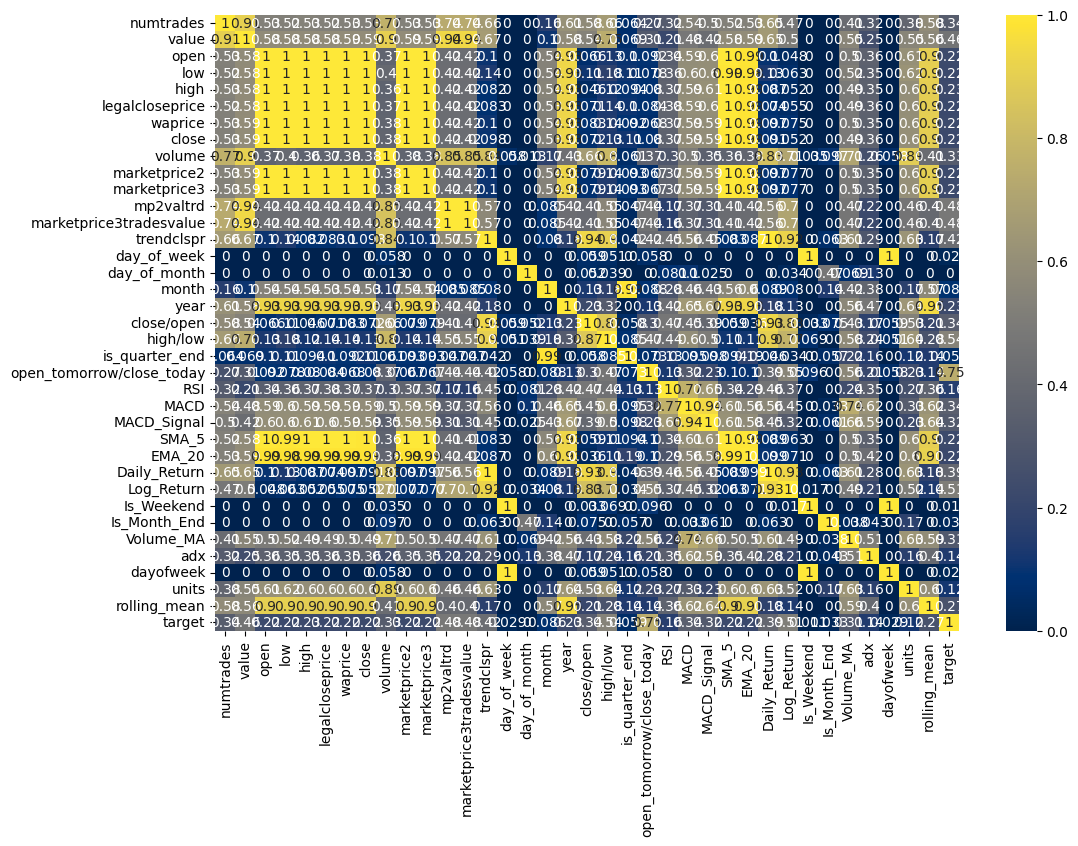

In [ ]:
# Создаем список названий столбцов
column_names = [f'lag_{i}' for i in range(1, 169)]

# Удаляем столбцы, передавая список напрямую
df_phik = df.drop(columns=column_names)

# Визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_phik.phik_matrix(),
    annot=True,
    cmap='cividis'
)

In [ ]:
df1 = df.drop(['open',	'high',	'low',	'close'], axis = 1)

interval columns not set, guessing: ['numtrades', 'value', 'legalcloseprice', 'waprice', 'volume', 'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue', 'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month', 'month', 'year', 'close/open', 'high/low', 'is_quarter_end', 'open_tomorrow/close_today', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5', 'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA', 'adx', 'dayofweek', 'units', 'rolling_mean', 'target']


<Axes: >

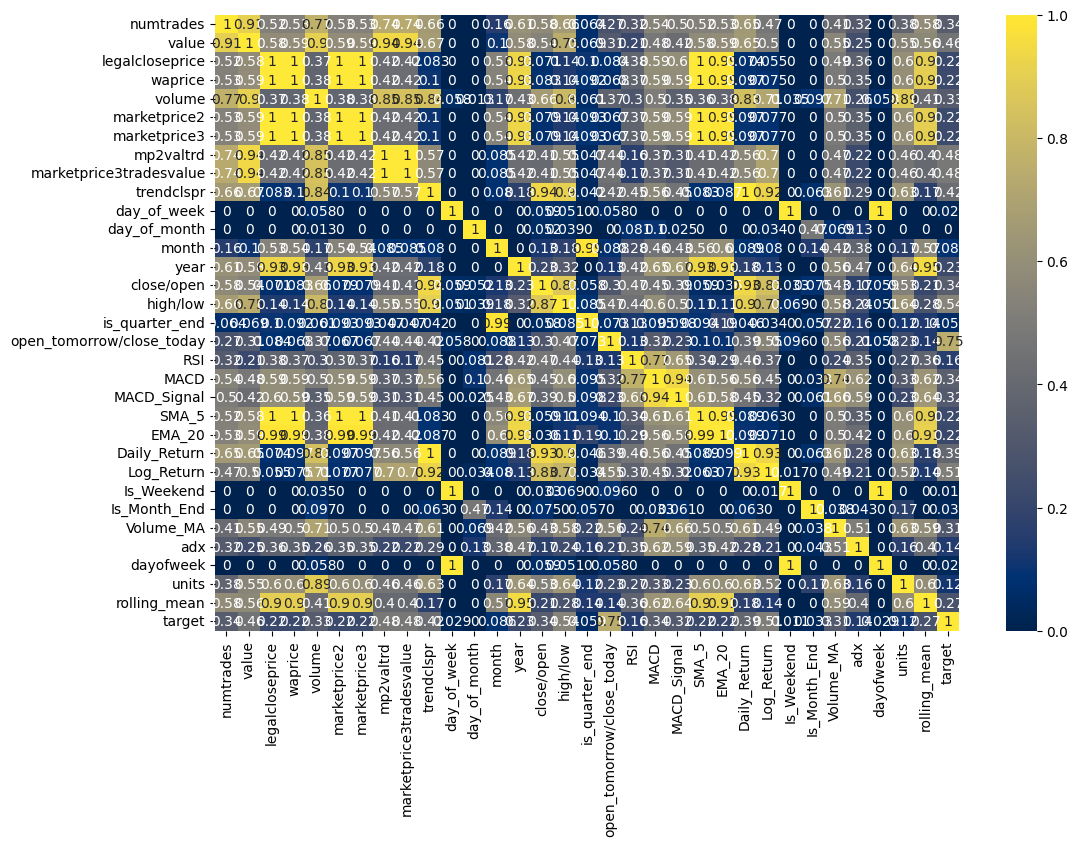

In [ ]:
# Создаем список названий столбцов
column_names = [f'lag_{i}' for i in range(1, 169)]

# Правильно удаляем столбцы, передавая список напрямую
df1_phik = df1.drop(columns=column_names)

# Визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(
    df1_phik.phik_matrix(),
    annot=True,
    cmap='cividis'
)

Для первой попытки оставим все полученные признаки, невзирая на взаимные их корреляции

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df1, 'target')

2013-11-21 00:00:00 2024-05-03 00:00:00
2024-05-06 00:00:00 2025-06-26 00:00:00 


(2613, 201) (2613,) 

 (291, 201) (291,)


In [ ]:
results_data = []

In [ ]:
# Параметры для линейной регрессии
lr_params = {
}

# Параметры для дерева решений
dt_params = {
    'model__max_features': range(1, 28, 4),
    'model__max_depth': range(1, 20, 4),
    'model__min_samples_leaf': range(2, 5, 1),
    'model__min_samples_split': range(1,8,1),
}

# Параметры для LGBM
lgbm_params = {
    'model__n_estimators': range(1, 20, 2),  # Исправлено model___estimators на model__n_estimators
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__verbosity': [-1]
}

# Словарь моделей и их параметров
models_params = {
    'LinearRegression': (LinearRegression(), lr_params),
    'DecisionTreeRegressor': (DecisionTreeRegressor(random_state=RANDOM_STATE), dt_params),
    'LGBMRegressor': (LGBMRegressor(random_state=RANDOM_STATE), lgbm_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

LinearRegression:
R² на кросс-валидации: -0.184
MAE на трейне: 49.982
MAE на тесте: 83.568
RMSE на трейне: 71.432
RMSE на тесте: 108.389
R² на трейне: 0.272
R² на тесте: 0.043
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])
----------------------------------------
DecisionTreeRegressor:
R² на кросс-валидации: -0.013
MAE на трейне: 53.584
MAE на тесте: 80.294
RMSE на трейне: 83.526
RMSE на тесте: 110.502
R² на трейне: 0.004
R² на тесте: 0.005
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeRegressor(max_depth=1, max_features=1,
                                       min_samples_leaf=2,
                                       random_state=654321))])
----------------------------------------
LGBMRegressor:
R² на кросс-валидации: 0.059
MAE на трейне: 48.749
MAE на тесте: 80.712
RMSE на трейне: 74.522
RMSE на тесте: 107.900
R² на трейне: 0.207
R² на тесте: 0.052
Лучшая модель: Pipe

In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.184,49.982,83.568,71.432,108.389,0.272,0.043
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 1, 'model__max_features':...",-0.013,53.584,80.294,83.526,110.502,0.004,0.005
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.059,48.749,80.712,74.522,107.900,0.207,0.052


In [ ]:
# Параметры для случайного леса
rf_params = {
    #'model__max_features': range(1, 20, 2),
    'model__max_depth': range(1, 16, 3),
    'model__min_samples_leaf': range(2,14,3),
    #'model__min_samples_split': range(2,8,2),
    }

# Словарь моделей и их параметров
models_params = {
    'RandomForestRegressor' : (RandomForestRegressor(random_state=RANDOM_STATE), rf_params),
    }

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

RandomForestRegressor:
R² на кросс-валидации: 0.016
MAE на трейне: 48.631
MAE на тесте: 79.039
RMSE на трейне: 71.668
RMSE на тесте: 104.986
R² на трейне: 0.267
R² на тесте: 0.102
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.184,49.982,83.568,71.432,108.389,0.272,0.043
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 1, 'model__max_features':...",-0.013,53.584,80.294,83.526,110.502,0.004,0.005
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.059,48.749,80.712,74.522,107.900,0.207,0.052
3,RandomForestRegressor,"(StandardScaler(), (DecisionTreeRegressor(max_...","{'model__max_depth': 4, 'model__min_samples_le...",0.016,48.631,79.039,71.668,104.986,0.267,0.102


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
Характеристики лучшей модели:
R² CV: 0.016
MAE TEST: 79.039
RMSE TEST: 104.986
R² TEST: 0.102


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])

In [ ]:
# Параметры для Catboost

catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    #'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass']
    }

# Словарь моделей и их параметров
models_params = {
    'CatBoostRegressor' : (CatBoostRegressor(random_state=RANDOM_STATE,
                               iterations=1000,
                               verbose=False
                               ), catb_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostRegressor:
R² на кросс-валидации: 0.091
MAE на трейне: 41.183
MAE на тесте: 81.366
RMSE на трейне: 56.372
RMSE на тесте: 108.734
R² на трейне: 0.547
R² на тесте: 0.037
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x7885b7f34810>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.184,49.982,83.568,71.432,108.389,0.272,0.043
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 1, 'model__max_features':...",-0.013,53.584,80.294,83.526,110.502,0.004,0.005
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.059,48.749,80.712,74.522,107.900,0.207,0.052
3,RandomForestRegressor,"(StandardScaler(), (DecisionTreeRegressor(max_...","{'model__max_depth': 4, 'model__min_samples_le...",0.016,48.631,79.039,71.668,104.986,0.267,0.102
4,CatBoostRegressor,"(StandardScaler(), <catboost.core.CatBoostRegr...","{'model__depth': 7, 'model__learning_rate': 0.01}",0.091,41.183,81.366,56.372,108.734,0.547,0.037


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
Характеристики лучшей модели:
R² CV: 0.016
MAE TEST: 79.039
RMSE TEST: 104.986
R² TEST: 0.102


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model_1.pkl')

Результаты сохранены в файл: best_model_1.pkl


In [ ]:
best_model_1 = best_model

In [ ]:
best_model_predictions = best_model.predict(X_test)

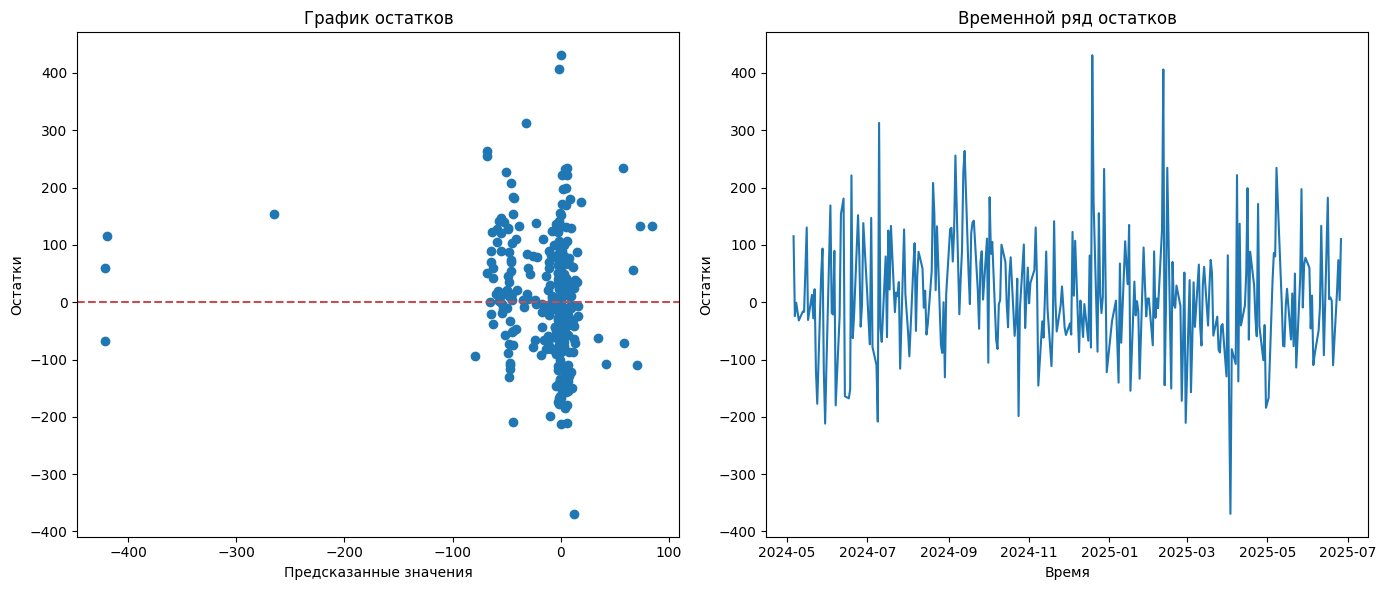

In [ ]:
plot_residuals(y_test, best_model_predictions)

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_feature_importance_2(model, X_test)
def plot_feature_importance_2(model, X_test):
    try:
        # Получаем финальный оценщик из пайплайна (CatBoostRegressor)
        estimator = model.named_steps['model']  # Здесь 'model' - имя шага в пайплайне

        # Получаем важность признаков
        if hasattr(estimator, 'get_feature_importance'):
            importances = estimator.get_feature_importance()
        else:
            raise AttributeError("Модель не поддерживает получение важности признаков")

        # Создаем DataFrame для удобства сортировки
        importance_df = pd.DataFrame({
            'features': X_test.columns,
            'importances': importances
        })

        # Сортируем по убыванию и берем топ-15
        top_features = importance_df.sort_values(by='importances',
                                                 ascending=False
                                                 ).head(15)

        # Создаем график
        plt.figure(figsize=(12, 8))
        plt.barh(top_features['features'], top_features['importances'], align='center')
        plt.xlabel('Важность признака')
        plt.title('Топ-15 самых важных признаков')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Ошибка при построении графика важности признаков: {e}")

In [ ]:
plot_feature_importance_2(best_model, X_test)

Ошибка при построении графика важности признаков: Модель не поддерживает получение важности признаков


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>visualization(predictions)
def visualization(predictions):
    model_data = pd.DataFrame({"target":y_test, "predict":predictions})
    model_data.plot(figsize=(15, 7))
    plt.xlabel('Дата')
    plt.ylabel('Количество заказов в час')
    plt.title('Совмещенный график целевых значений и предсказаний модели')
    # возьмем короткий интервал, дни можно взять любые, но пусть будут эти
    model_data['2025-02-15':'2025-03-28'].plot(figsize=(20, 10))
    plt.xlabel('Дата')
    plt.ylabel('Разница между ценой закрытия завтрашнего дня и сегодняшнего')
    plt.title('Совмещенный график целевых значений и предсказаний модели за интервал 15 февраля - 28 марта 2025')


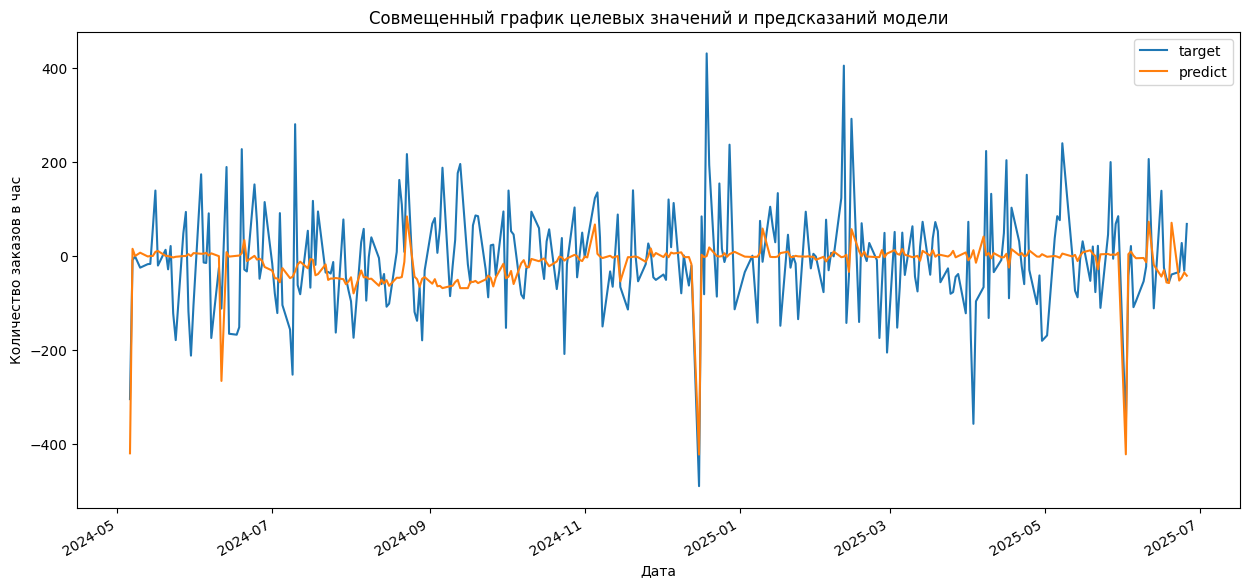

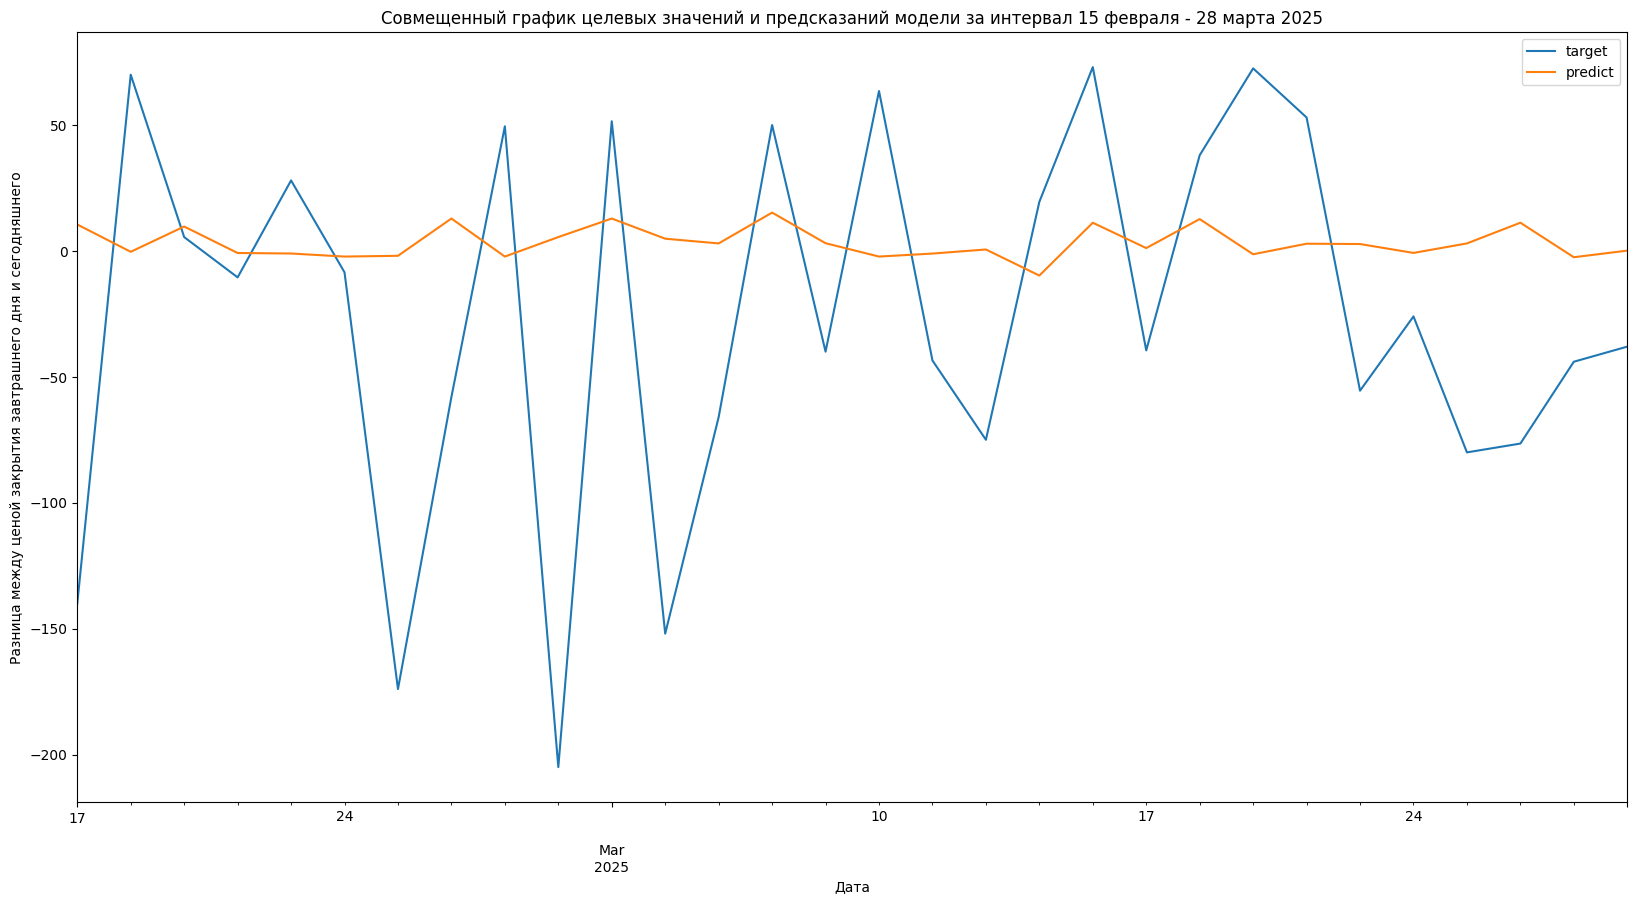

In [ ]:
visualization(best_model_predictions)

### Играем на покупку

In [ ]:
X_train_1, X_test_1, y_train_1, y_test_1 = split_data_res_ind(df, 'target')

2013-11-21 00:00:00 2024-05-03 00:00:00
2024-05-06 00:00:00 2025-06-26 00:00:00 


(2613, 205) (2613,) 

 (291, 205) (291,)


In [ ]:
# Шаг 1: Делаем предсказания и добавляем их в X_test
X_test['predicted_diff'] = best_model.predict(X_test)

# Шаг 2: Объединяем данные
profit_df = pd.merge(
    X_test[['predicted_diff']],  # Берем только предсказания
    X_test_1[['open', 'close', 'adx']],  # Берем цены открытия и закрытия
    left_index=True, right_index=True  # Объединяем по индексу datetime
)


In [ ]:
profit_df.head(5)

,predicted_diff,open,close,adx
TRADEDATE,,,,
2024-05-06,-419.175170,8075.0,8026.5,38.684398
2024-05-07,15.647468,7594.0,7722.5,35.410161
2024-05-08,0.338048,7754.5,7714.0,33.318090
2024-05-10,7.317912,7720.0,7713.5,32.085184
2024-05-13,-0.695083,7730.0,7689.0,31.344186


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>calculate_buy_strategy_profit(df, initial_capital=100000)
def calculate_buy_strategy_profit(df, initial_capital=100000):
    """
    Рассчитывает профит при торговле на покупку (buy стратегия) с учетом ADX

    Параметры:
    df (pd.DataFrame): DataFrame с колонками 'predicted_diff', 'open', 'close', 'ADX'
    initial_capital (float): Начальная сумма капитала

    Возвращает:
    pd.DataFrame: Исходный DataFrame с добавленными колонками 'daily_profit' и 'cumulative_profit'
    """
    # Создаем столбцы для хранения результатов
    df['daily_profit'] = 0
    df['cumulative_profit'] = 0

    # Сохраняем начальный капитал
    capital = initial_capital

    # Проходим по строкам начиная со второй
    for i in range(1, len(df)):
        # Получаем предыдущие значения
        prev_prediction = df.loc[df.index[i-1], 'predicted_diff']
        prev_adx = df.loc[df.index[i-1], 'adx']

        # Проверяем условия для совершения покупки
        if prev_prediction > 0 and prev_adx > 25:
            open_price = df.loc[df.index[i], 'open']
            close_price = df.loc[df.index[i], 'close']

            # Рассчитываем количество акций и прибыль
            shares = capital / open_price
            profit = shares * (close_price - open_price)

            # Сохраняем результаты
            df.at[df.index[i], 'daily_profit'] = profit

            # Обновляем капитал
            capital += profit

        # Обновляем кумулятивный профит
        df.at[df.index[i], 'cumulative_profit'] = df.loc[:df.index[i], 'daily_profit'].sum()

    return df

In [ ]:
profit_df = calculate_buy_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-419.175170,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,15.647468,7594.0,7722.5,35.410161,0.000000,0.000000
2024-05-08,0.338048,7754.5,7714.0,33.318090,-522.277387,-522.277387
2024-05-10,7.317912,7720.0,7713.5,32.085184,-83.757150,-606.034537
2024-05-13,-0.695083,7730.0,7689.0,31.344186,-527.186621,-1133.221159


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,70.930773,6322.5,6281.0,20.420690,0.0,-5481.384536
2025-06-23,-51.890584,6388.5,6242.0,22.283388,0.0,-5481.384536
2025-06-24,-45.520289,6245.0,6208.5,21.750033,0.0,-5481.384536
2025-06-25,-34.713023,6218.5,6236.5,21.442900,0.0,-5481.384536
2025-06-26,-41.578701,6250.0,6205.5,21.518423,0.0,-5481.384536


Итоговая прибыль: -5481.384536310906


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_cumulative_profit(profit_df, title)
import matplotlib.dates as mdates
def plot_cumulative_profit(profit_df, title):
    # Создаем график
    plt.figure(figsize=(16, 8))

    # Строим кумулятивную прибыль
    plt.plot(profit_df.index,
             profit_df['cumulative_profit'],
             color='green',
             linewidth=2,
             alpha=0.8,
             label='Кумулятивная прибыль')

    # Добавляем горизонтальную линию безубыточности
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    # Форматируем ось X
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

    # Формируем заголовок в зависимости от переданного параметра
    if title == 'sell':
        title_text = "ПРОДАЖА: Кумулятивная прибыль"
    elif title == 'buy':
        title_text = "ПОКУПКА: Кумулятивная прибыль"
    elif title == 'both':
        title_text = "КОМБИНИРОВАННАЯ СТРАТЕГИЯ (ПОКУПКА И ПРОДАЖА): Кумулятивная прибыль"
    else:
        title_text = "Кумулятивная прибыль"

    # Добавляем заголовок
    plt.title(title_text,
              fontsize=16,
              color='#4189ab',
              fontweight='bold')

    # Добавляем подписи
    plt.xlabel('Дата', fontsize=14)
    plt.ylabel('Прибыль', fontsize=14)
    plt.legend(fontsize=12)

    # Добавляем сетку
    plt.grid(True, linestyle='--', alpha=0.7)

    # Улучшаем отображение дат
    plt.gcf().autofmt_xdate()

    # Добавляем информацию о финальной прибыли
    final_profit = profit_df['cumulative_profit'].iloc[-1]
    plt.text(
        profit_df.index[-1],
        final_profit,
        f'Итоговая прибыль: {final_profit:.2f}',
        fontsize=12,
        ha='right',
        va='bottom',
        color='blue'
    )

    # Отображаем график
    plt.tight_layout()
    plt.show()

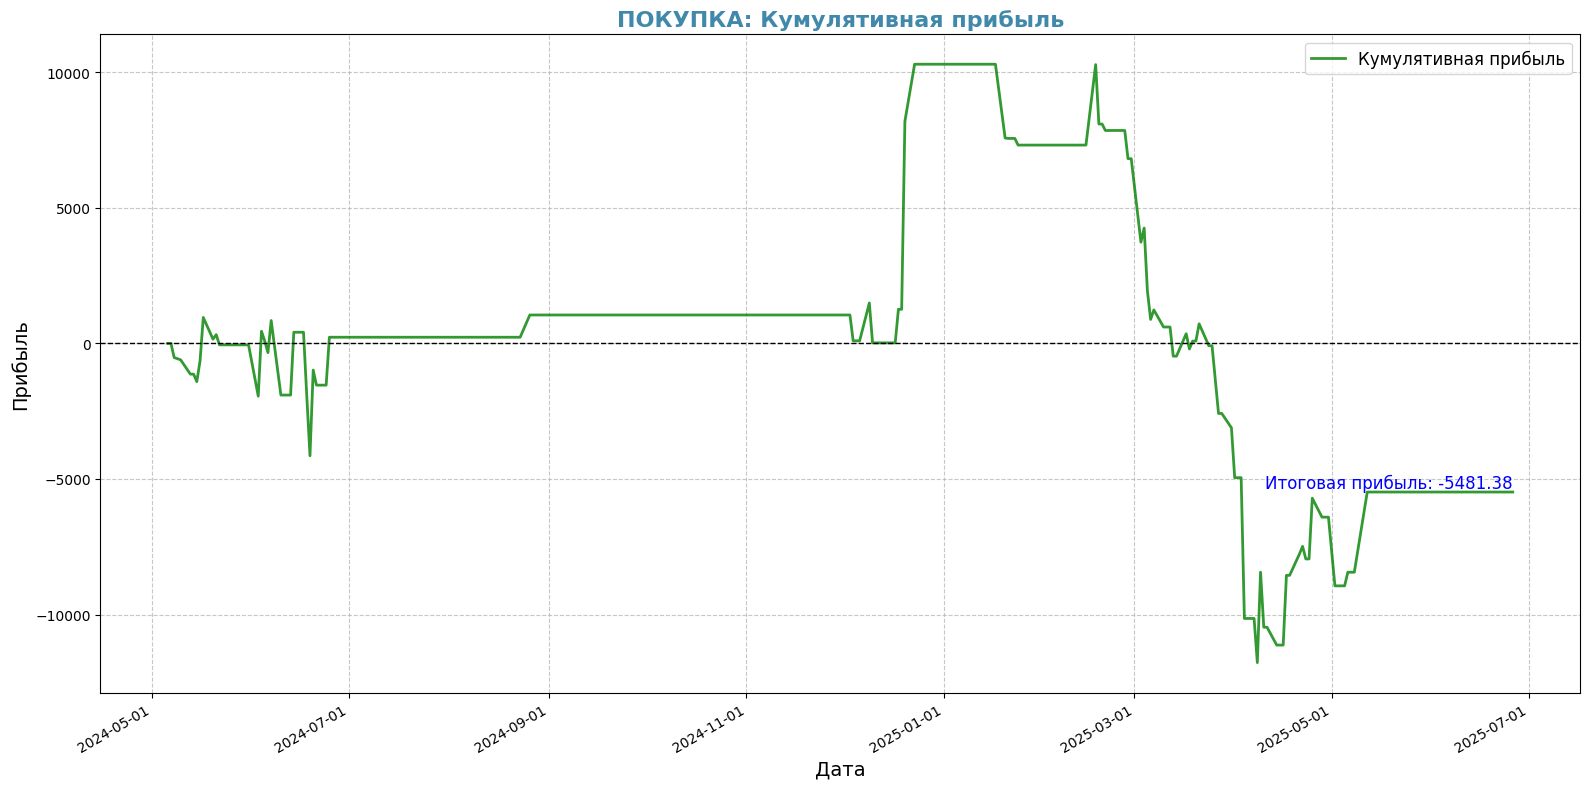

In [ ]:
plot_cumulative_profit(profit_df, 'buy')

### Играем на продажу

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>calculate_sell_strategy_profit(df, initial_capital=100000)
def calculate_sell_strategy_profit(df, initial_capital=100000):
    """
    Рассчитывает профит при торговле на продажу (sell стратегия)

    Параметры:
    df (pd.DataFrame): DataFrame с колонками 'predicted_diff', 'open', 'close'
    initial_capital (float): Начальная сумма капитала

    Возвращает:
    pd.DataFrame: Исходный DataFrame с добавленными колонками 'daily_profit' и 'cumulative_profit'
    """
    # Создаем столбцы для хранения результатов
    df['daily_profit'] = 0
    df['cumulative_profit'] = 0

    # Сохраняем начальный капитал
    capital = initial_capital

    # Проходим по строкам начиная со второй
    for i in range(1, len(df)):
        # Получаем предыдущее предсказание
        prev_prediction = df.loc[df.index[i-1], 'predicted_diff']
        prev_adx = df.loc[df.index[i-1], 'adx']

        # Если предсказание отрицательное - совершаем продажу
        if prev_prediction < 0 and prev_adx > 25:
            open_price = df.loc[df.index[i], 'open']
            close_price = df.loc[df.index[i], 'close']

            # Рассчитываем количество акций и прибыль
            shares = capital / open_price
            profit = shares * (open_price - close_price)

            # Сохраняем результаты
            df.at[df.index[i], 'daily_profit'] = profit

            # Обновляем капитал
            capital += profit

        # Обновляем кумулятивный профит
        df.at[df.index[i], 'cumulative_profit'] = df.loc[:df.index[i], 'daily_profit'].sum()

    return df

In [ ]:
profit_df = calculate_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-419.175170,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,15.647468,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,0.338048,7754.5,7714.0,33.318090,0.000000,-1692.125362
2024-05-10,7.317912,7720.0,7713.5,32.085184,0.000000,-1692.125362
2024-05-13,-0.695083,7730.0,7689.0,31.344186,0.000000,-1692.125362


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,70.930773,6322.5,6281.0,20.420690,0.0,28181.769248
2025-06-23,-51.890584,6388.5,6242.0,22.283388,0.0,28181.769248
2025-06-24,-45.520289,6245.0,6208.5,21.750033,0.0,28181.769248
2025-06-25,-34.713023,6218.5,6236.5,21.442900,0.0,28181.769248
2025-06-26,-41.578701,6250.0,6205.5,21.518423,0.0,28181.769248


Итоговая прибыль: 28181.7692483187


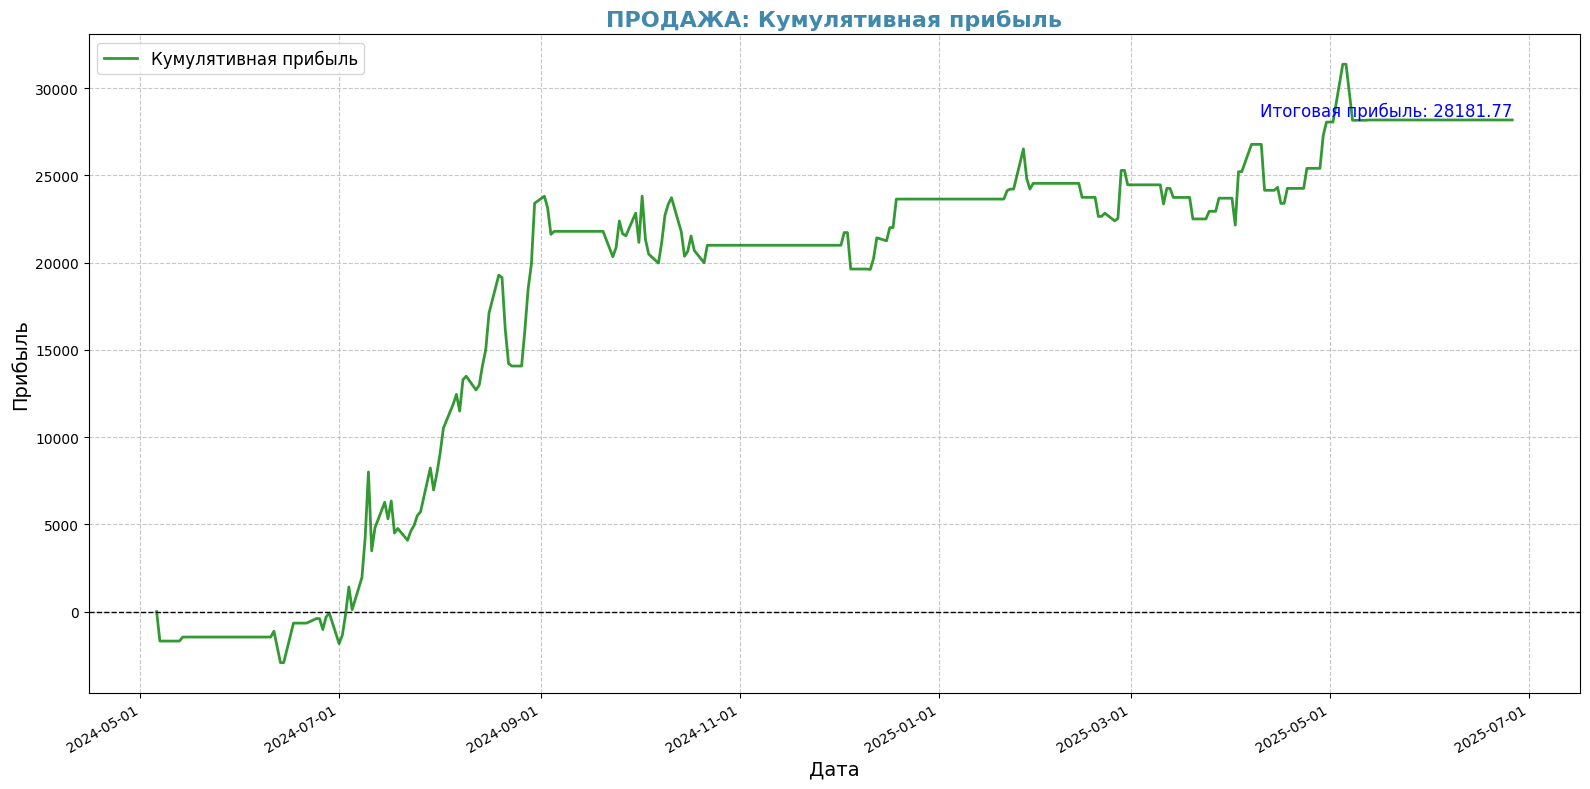

In [ ]:
plot_cumulative_profit(profit_df, 'sell')

### Играем на покупку и продажу

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000)
def calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000):
    """
    Рассчитывает профит для стратегии торговли как на покупку, так и на продажу.

    Параметры:
    profit_df (DataFrame): DataFrame с данными для расчета
    initial_capital (float): Начальная сумма капитала (по умолчанию 100000)

    Возвращает:
    DataFrame с добавленными колонками daily_profit и cumulative_profit
    """
    # Инициализируем колонки для профита
    profit_df['daily_profit'] = 0
    profit_df['cumulative_profit'] = 0

    # Сохраняем начальную сумму в локальную переменную
    current_capital = initial_capital

    # Проходим по строкам и рассчитываем профит
    for i in range(1, len(profit_df)):
        # Получаем данные из DataFrame
        prev_prediction = profit_df.loc[profit_df.index[i-1], 'predicted_diff']
        prev_adx = df.loc[df.index[i-1], 'adx']
        open_price = profit_df.loc[profit_df.index[i], 'open']
        close_price = profit_df.loc[profit_df.index[i], 'close']

        # Определяем тип сделки в зависимости от предсказания
        if prev_prediction > 0 and prev_adx>25:
            # Сделка на покупку
            shares = current_capital / open_price
            profit = shares * (close_price - open_price)

        elif prev_prediction < 0 and prev_adx>25:
            # Сделка на продажу
            shares = current_capital / open_price
            profit = shares * (open_price - close_price)

        else:
            profit = 0

        # Сохраняем результаты в DataFrame
        profit_df.at[profit_df.index[i], 'daily_profit'] = profit

        # Обновляем текущий капитал
        current_capital += profit

        # Рассчитываем кумулятивный профит
        profit_df.at[profit_df.index[i], 'cumulative_profit'] = \
            profit_df.loc[:profit_df.index[i], 'daily_profit'].sum()

    return profit_df

In [ ]:
profit_df = calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-419.175170,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,15.647468,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,0.338048,7754.5,7714.0,33.318090,-513.439799,-2205.565161
2024-05-10,7.317912,7720.0,7713.5,32.085184,-82.339874,-2287.905035
2024-05-13,-0.695083,7730.0,7689.0,31.344186,-518.265963,-2806.170998


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,70.930773,6322.5,6281.0,20.420690,618.486628,-5155.448248
2025-06-23,-51.890584,6388.5,6242.0,22.283388,-2174.959197,-7330.407445
2025-06-24,-45.520289,6245.0,6208.5,21.750033,541.623719,-6788.783726
2025-06-25,-34.713023,6218.5,6236.5,21.442900,-269.808136,-7058.591862
2025-06-26,-41.578701,6250.0,6205.5,21.518423,661.742826,-6396.849036


Итоговая прибыль: -6396.849035645395


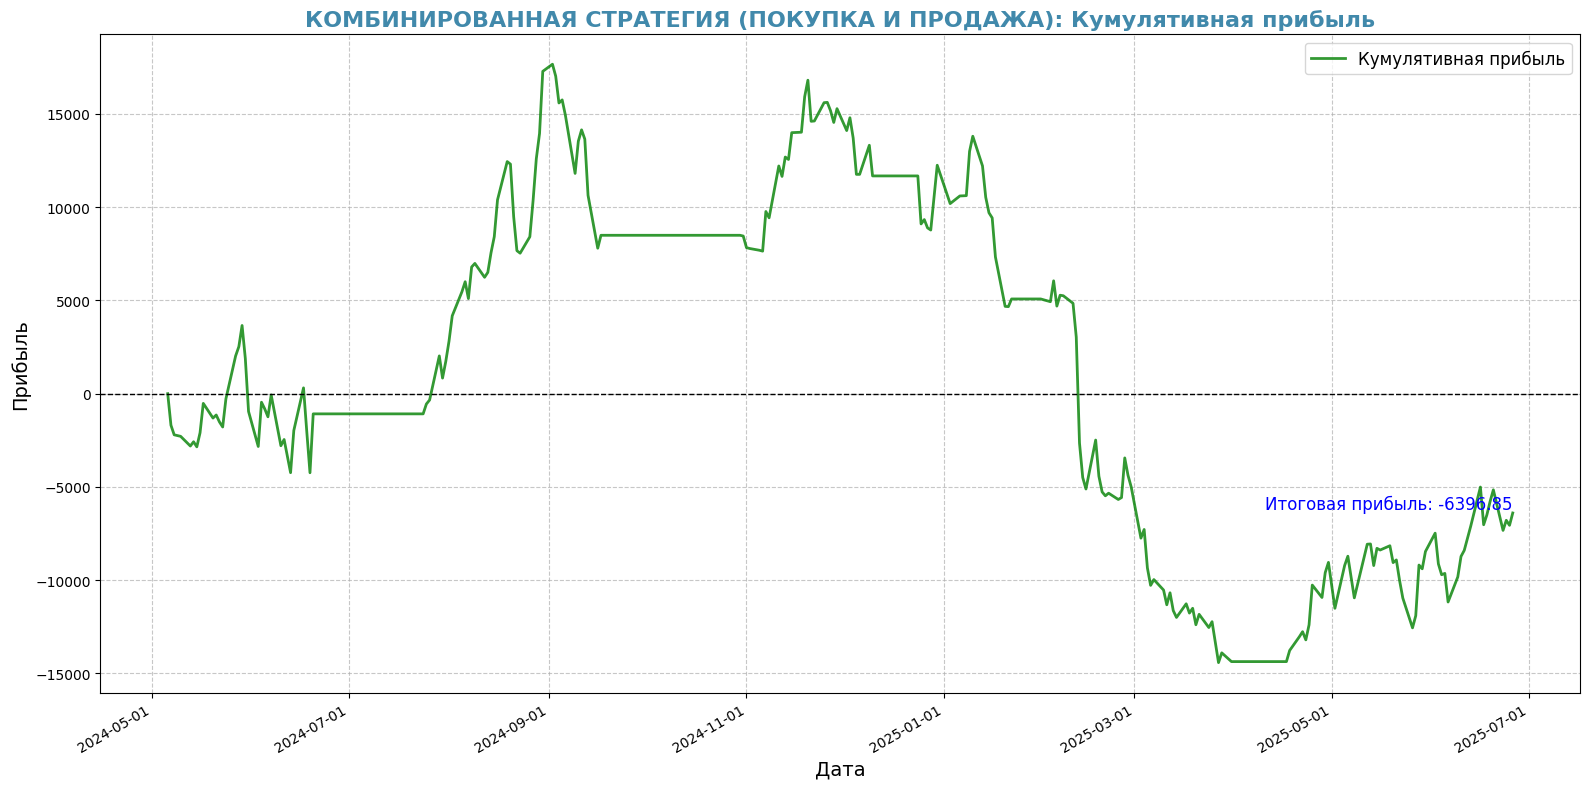

In [ ]:
plot_cumulative_profit(profit_df, 'both')

## Удаление лишних признаков

### Уберем высокоскоррелированные ячейки

In [ ]:
columns = ['open', 'low', 'high', 'close', 'numtrades', 'value', 'legalcloseprice', 'waprice',
           'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue',
           'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month',
           'month', 'year', 'high/low', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5',
           'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA',
           'units' ]
df2 = df.drop(columns, axis=1)

In [ ]:
df2 = move_column_to_end(df2, 'target')

interval columns not set, guessing: ['numtrades', 'value', 'open', 'low', 'high', 'legalcloseprice', 'waprice', 'close', 'volume', 'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue', 'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month', 'month', 'year', 'close/open', 'high/low', 'is_quarter_end', 'open_tomorrow/close_today', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5', 'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA', 'adx', 'dayofweek', 'units', 'rolling_mean', 'target']


<Axes: >

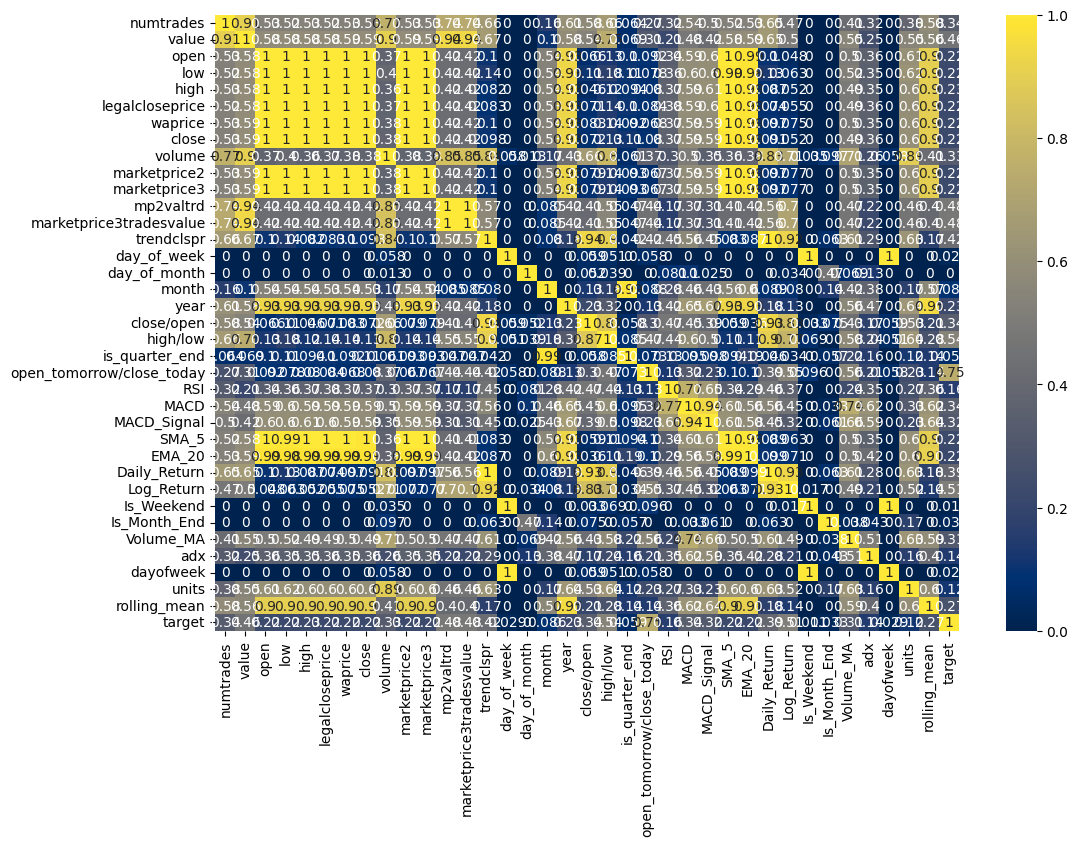

In [ ]:
# Создаем список названий столбцов
column_names = [f'lag_{i}' for i in range(1, 169)]

# Удаляем столбцы, передавая список напрямую
df2_phik = df.drop(columns=column_names)

plt.figure(figsize = (12,8))
sns.heatmap(df2_phik.phik_matrix(
    #interval_cols=interval_cols
    ), annot=True, cmap='cividis')

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df2, 'target')

2013-11-21 00:00:00 2024-05-03 00:00:00
2024-05-06 00:00:00 2025-06-26 00:00:00 


(2613, 176) (2613,) 

 (291, 176) (291,)


In [ ]:
results_data = []

In [ ]:
# Параметры для линейной регрессии
lr_params = {
}

# Параметры для дерева решений
dt_params = {
    'model__max_features': range(1, 28, 4),
    'model__max_depth': range(1, 20, 4),
    'model__min_samples_leaf': range(2, 5, 1),
    'model__min_samples_split': range(1,8,1),
}

# Параметры для LGBM
lgbm_params = {
    'model__n_estimators': range(1, 20, 2),  # Исправлено model___estimators на model__n_estimators
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__verbosity': [-1]
}

# Словарь моделей и их параметров
models_params = {
    'LinearRegression': (LinearRegression(), lr_params),
    'DecisionTreeRegressor': (DecisionTreeRegressor(random_state=RANDOM_STATE), dt_params),
    'LGBMRegressor': (LGBMRegressor(random_state=RANDOM_STATE), lgbm_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

LinearRegression:
R² на кросс-валидации: -0.161
MAE на трейне: 49.992
MAE на тесте: 81.593
RMSE на трейне: 72.141
RMSE на тесте: 105.752
R² на трейне: 0.257
R² на тесте: 0.089
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])
----------------------------------------
DecisionTreeRegressor:
R² на кросс-валидации: -0.018
MAE на трейне: 53.655
MAE на тесте: 80.853
RMSE на трейне: 83.456
RMSE на тесте: 110.871
R² на трейне: 0.006
R² на тесте: -0.001
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeRegressor(max_depth=1, max_features=21,
                                       min_samples_leaf=3,
                                       random_state=654321))])
----------------------------------------
LGBMRegressor:
R² на кросс-валидации: 0.046
MAE на трейне: 48.673
MAE на тесте: 81.405
RMSE на трейне: 74.390
RMSE на тесте: 107.141
R² на трейне: 0.210
R² на тесте: 0.065
Лучшая модель: Pi

In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.161,49.992,81.593,72.141,105.752,0.257,0.089
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 1, 'model__max_features':...",-0.018,53.655,80.853,83.456,110.871,0.006,-0.001
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.046,48.673,81.405,74.390,107.141,0.210,0.065


In [ ]:
# Параметры для случайного леса
rf_params = {
    #'model__max_features': range(1, 20, 2),
    'model__max_depth': range(1, 16, 3),
    'model__min_samples_leaf': range(2,14,3),
    #'model__min_samples_split': range(2,8,2),
    }

# Словарь моделей и их параметров
models_params = {
    'RandomForestRegressor' : (RandomForestRegressor(random_state=RANDOM_STATE), rf_params),
    }

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

RandomForestRegressor:
R² на кросс-валидации: 0.020
MAE на трейне: 48.615
MAE на тесте: 81.142
RMSE на трейне: 71.733
RMSE на тесте: 107.527
R² на трейне: 0.266
R² на тесте: 0.058
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.161,49.992,81.593,72.141,105.752,0.257,0.089
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 1, 'model__max_features':...",-0.018,53.655,80.853,83.456,110.871,0.006,-0.001
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.046,48.673,81.405,74.390,107.141,0.210,0.065
3,RandomForestRegressor,"(StandardScaler(), (DecisionTreeRegressor(max_...","{'model__max_depth': 4, 'model__min_samples_le...",0.020,48.615,81.142,71.733,107.527,0.266,0.058


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LGBMRegressor(n_estimators=5, random_state=654321,
                               verbosity=-1))])
Характеристики лучшей модели:
R² CV: 0.046
MAE TEST: 81.405
RMSE TEST: 107.141
R² TEST: 0.065


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LGBMRegressor(n_estimators=5, random_state=654321,
                               verbosity=-1))])

In [ ]:
# Параметры для Catboost

catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    #'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass']
    }

# Словарь моделей и их параметров
models_params = {
    'CatBoostRegressor' : (CatBoostRegressor(random_state=RANDOM_STATE,
                               iterations=1000,
                               verbose=False
                               ), catb_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostRegressor:
R² на кросс-валидации: 0.095
MAE на трейне: 42.198
MAE на тесте: 80.050
RMSE на трейне: 58.083
RMSE на тесте: 105.441
R² на трейне: 0.519
R² на тесте: 0.094
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x78858187f5d0>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.161,49.992,81.593,72.141,105.752,0.257,0.089
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 1, 'model__max_features':...",-0.018,53.655,80.853,83.456,110.871,0.006,-0.001
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.046,48.673,81.405,74.390,107.141,0.210,0.065
3,RandomForestRegressor,"(StandardScaler(), (DecisionTreeRegressor(max_...","{'model__max_depth': 4, 'model__min_samples_le...",0.020,48.615,81.142,71.733,107.527,0.266,0.058
4,CatBoostRegressor,"(StandardScaler(), <catboost.core.CatBoostRegr...","{'model__depth': 7, 'model__learning_rate': 0.01}",0.095,42.198,80.050,58.083,105.441,0.519,0.094


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x78858187f5d0>)])
Характеристики лучшей модели:
R² CV: 0.095
MAE TEST: 80.050
RMSE TEST: 105.441
R² TEST: 0.094


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x78858187f5d0>)])

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model_2.pkl')

Результаты сохранены в файл: best_model_2.pkl


In [ ]:
best_model_2 = best_model

In [ ]:
best_model_predictions = best_model.predict(X_test)

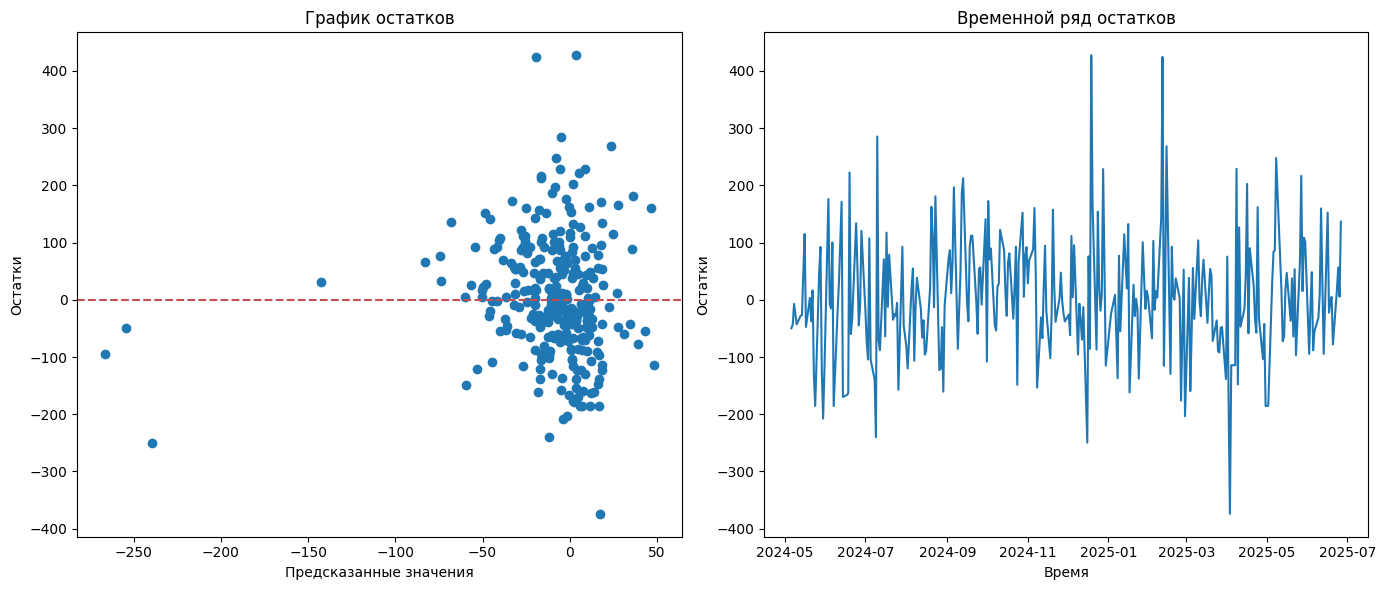

In [ ]:
plot_residuals(y_test, best_model_predictions)

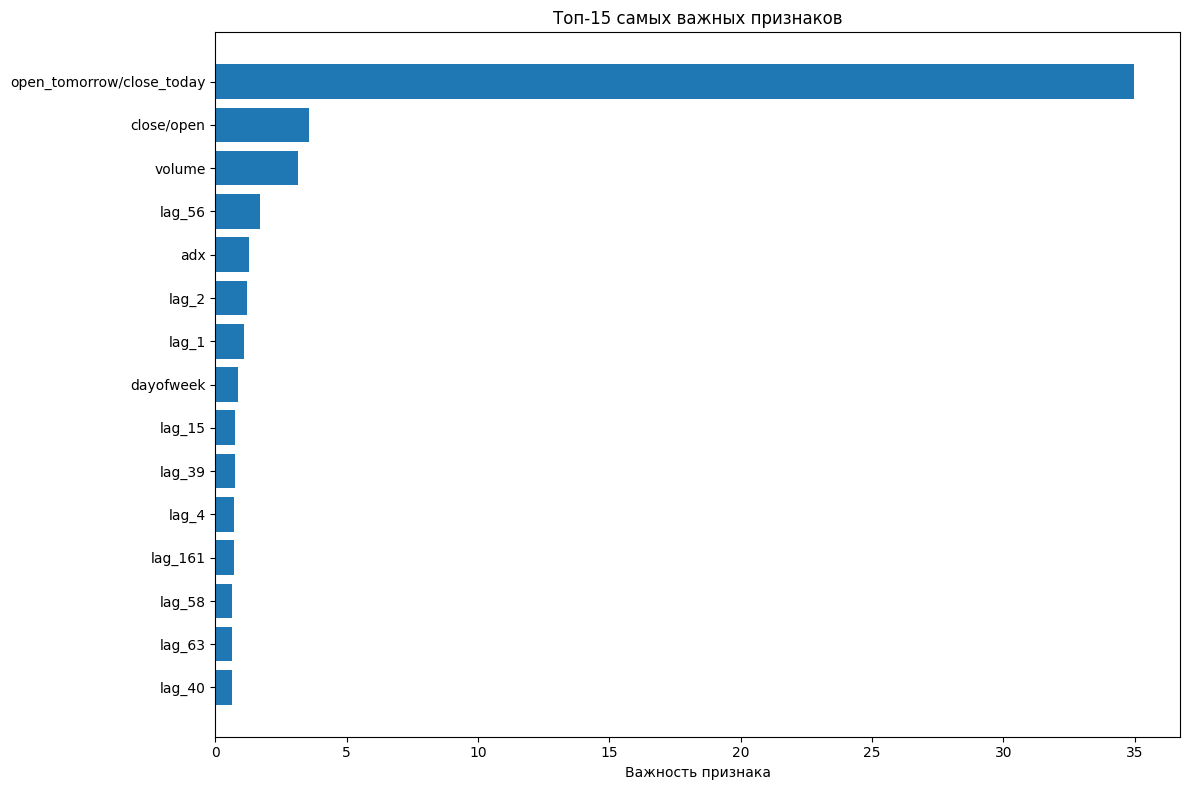

In [ ]:
plot_feature_importance_2(best_model, X_test)

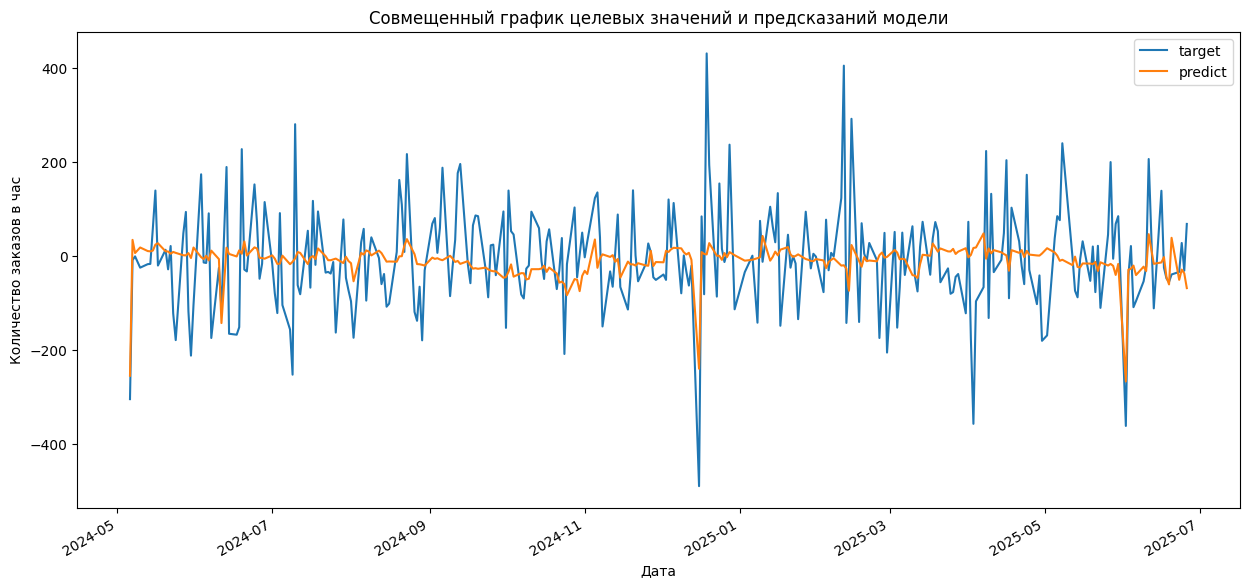

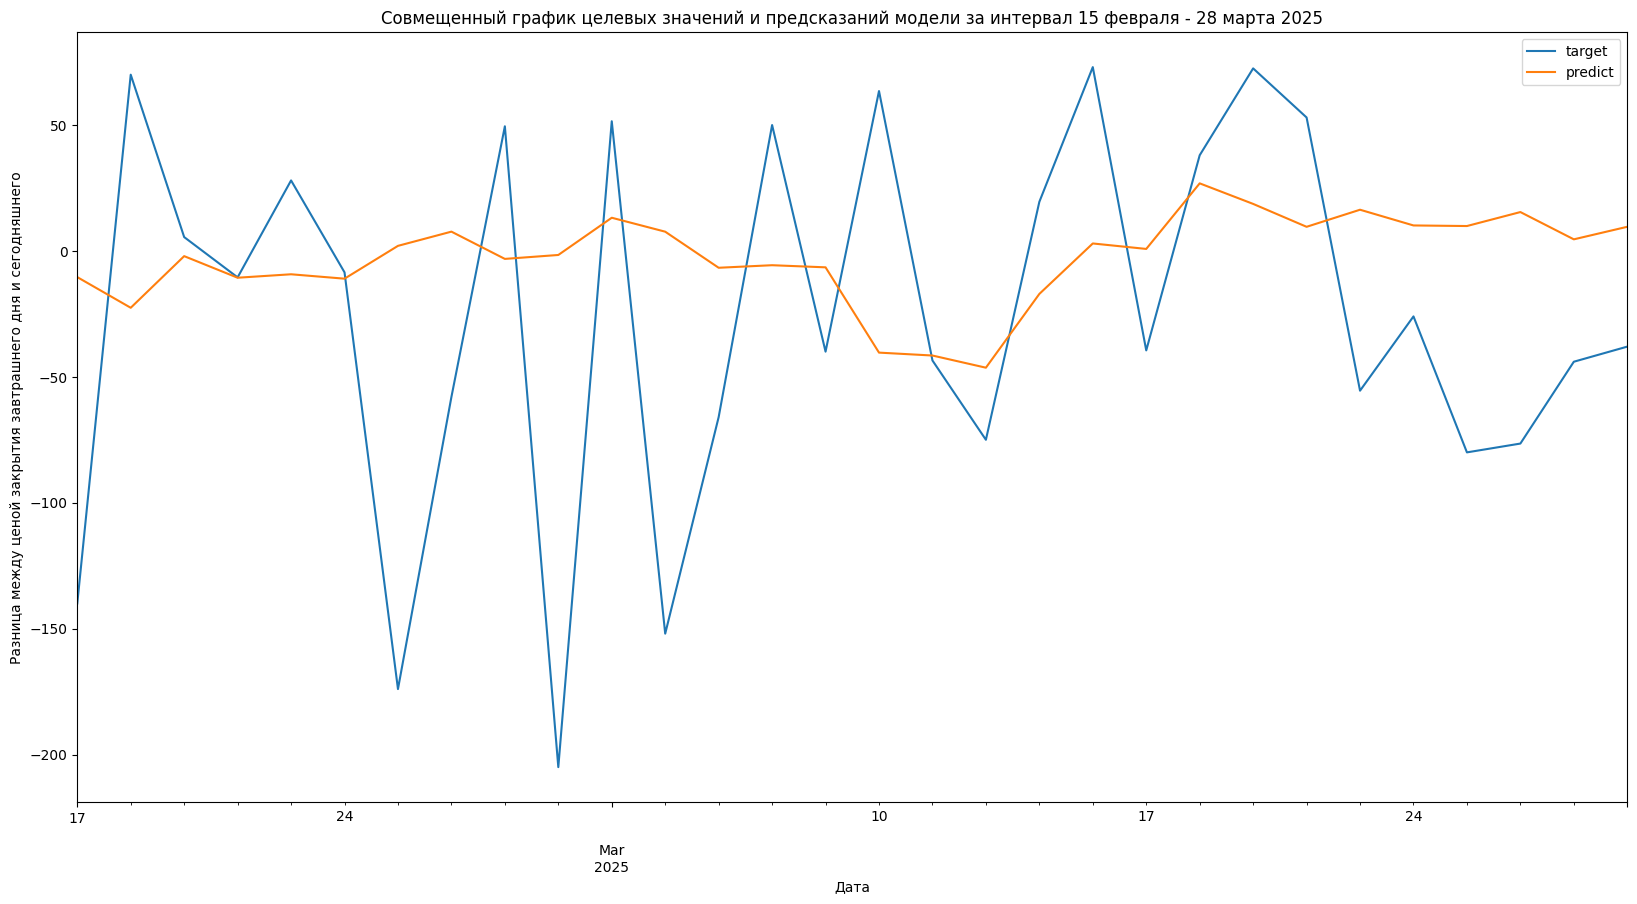

In [ ]:
visualization(best_model_predictions)

### Играем на покупку

In [ ]:
# Шаг 1: Делаем предсказания и добавляем их в X_test
X_test['predicted_diff'] = best_model.predict(X_test)

# Шаг 2: Объединяем данные
profit_df = pd.merge(
    X_test[['predicted_diff']],  # Берем только предсказания
    X_test_1[['open', 'close', 'adx']],  # Берем цены открытия и закрытия
    left_index=True, right_index=True  # Объединяем по индексу datetime
)


In [ ]:
profit_df.head(5)

,predicted_diff,open,close,adx
TRADEDATE,,,,
2024-05-06,-254.276993,8075.0,8026.5,38.684398
2024-05-07,34.594757,7594.0,7722.5,35.410161
2024-05-08,6.630395,7754.5,7714.0,33.318090
2024-05-10,18.427527,7720.0,7713.5,32.085184
2024-05-13,10.784523,7730.0,7689.0,31.344186


In [ ]:
profit_df = calculate_buy_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-254.276993,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,34.594757,7594.0,7722.5,35.410161,0.000000,0.000000
2024-05-08,6.630395,7754.5,7714.0,33.318090,-522.277387,-522.277387
2024-05-10,18.427527,7720.0,7713.5,32.085184,-83.757150,-606.034537
2024-05-13,10.784523,7730.0,7689.0,31.344186,-527.186621,-1133.221159


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,38.978612,6322.5,6281.0,20.420690,0.0,-21975.09527
2025-06-23,-50.378763,6388.5,6242.0,22.283388,0.0,-21975.09527
2025-06-24,-28.583080,6245.0,6208.5,21.750033,0.0,-21975.09527
2025-06-25,-36.476336,6218.5,6236.5,21.442900,0.0,-21975.09527
2025-06-26,-67.998186,6250.0,6205.5,21.518423,0.0,-21975.09527


Итоговая прибыль: -21975.095270227735


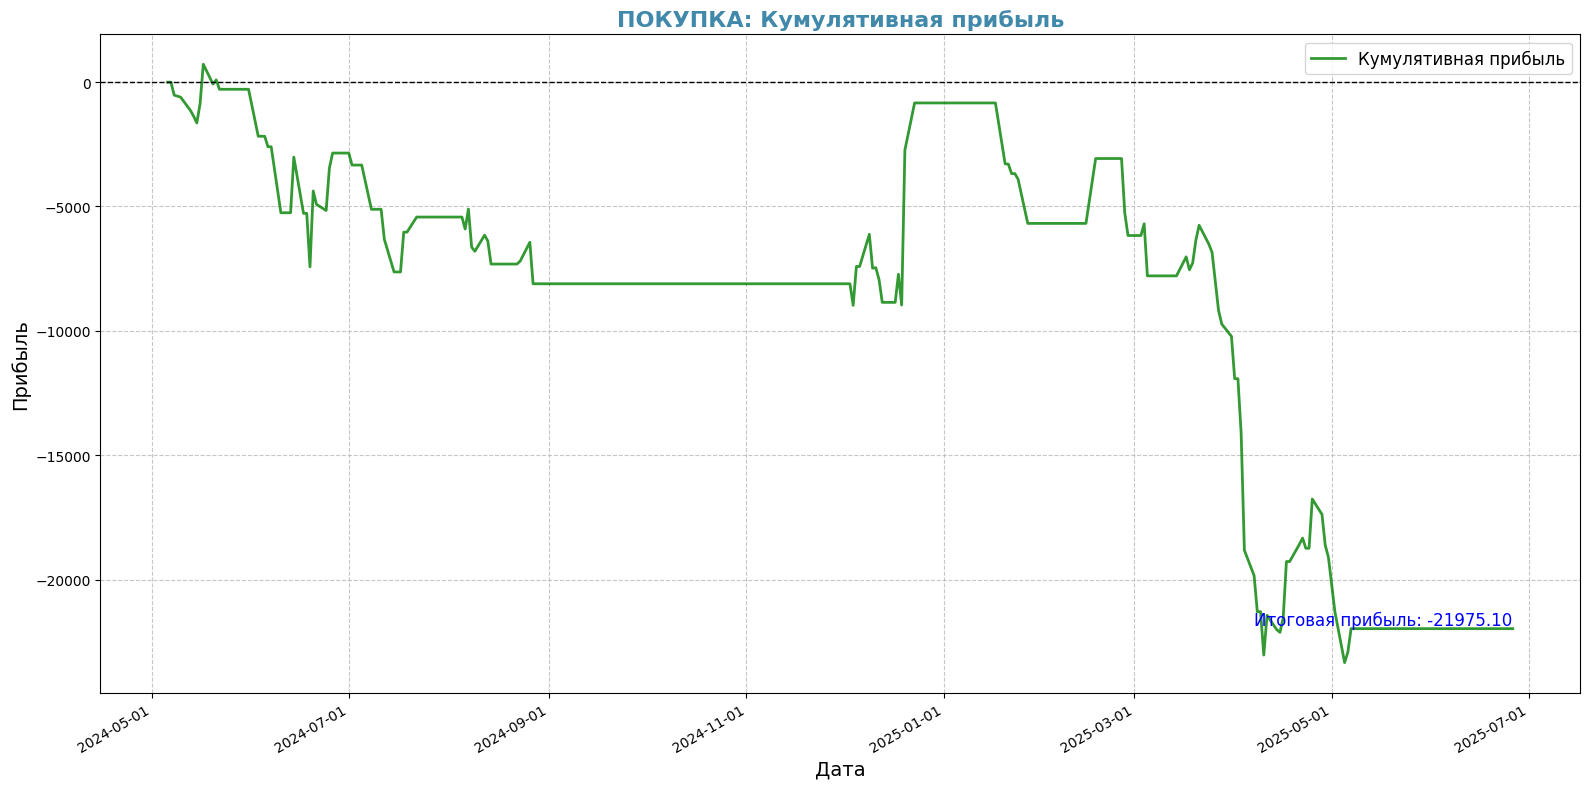

In [ ]:
plot_cumulative_profit(profit_df, 'buy')

### Играем на продажу

In [ ]:
profit_df = calculate_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-254.276993,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,34.594757,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,6.630395,7754.5,7714.0,33.318090,0.000000,-1692.125362
2024-05-10,18.427527,7720.0,7713.5,32.085184,0.000000,-1692.125362
2024-05-13,10.784523,7730.0,7689.0,31.344186,0.000000,-1692.125362


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,38.978612,6322.5,6281.0,20.420690,0.0,5940.853681
2025-06-23,-50.378763,6388.5,6242.0,22.283388,0.0,5940.853681
2025-06-24,-28.583080,6245.0,6208.5,21.750033,0.0,5940.853681
2025-06-25,-36.476336,6218.5,6236.5,21.442900,0.0,5940.853681
2025-06-26,-67.998186,6250.0,6205.5,21.518423,0.0,5940.853681


Итоговая прибыль: 5940.853681244069


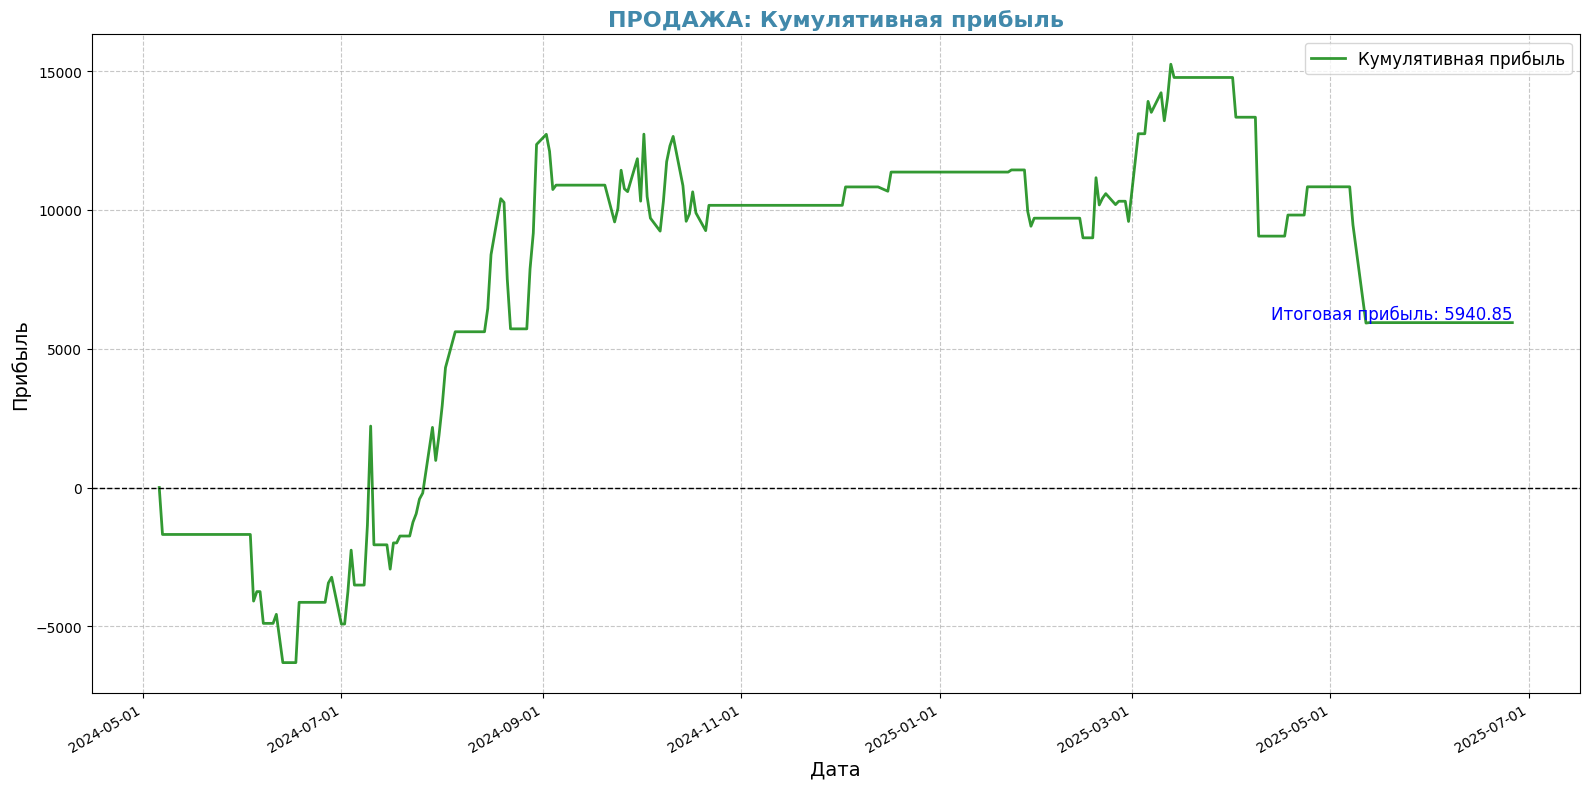

In [ ]:
plot_cumulative_profit(profit_df, 'sell')

### Играем на покупку и продажу

In [ ]:
profit_df = calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-254.276993,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,34.594757,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,6.630395,7754.5,7714.0,33.318090,-513.439799,-2205.565161
2024-05-10,18.427527,7720.0,7713.5,32.085184,-82.339874,-2287.905035
2024-05-13,10.784523,7730.0,7689.0,31.344186,-518.265963,-2806.170998


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,38.978612,6322.5,6281.0,20.420690,532.527189,-18337.276442
2025-06-23,-50.378763,6388.5,6242.0,22.283388,-1872.675746,-20209.952188
2025-06-24,-28.583080,6245.0,6208.5,21.750033,466.346957,-19743.605231
2025-06-25,-36.476336,6218.5,6236.5,21.442900,-232.309256,-19975.914486
2025-06-26,-67.998186,6250.0,6205.5,21.518423,569.771489,-19406.142998


Итоговая прибыль: -19406.142997626444


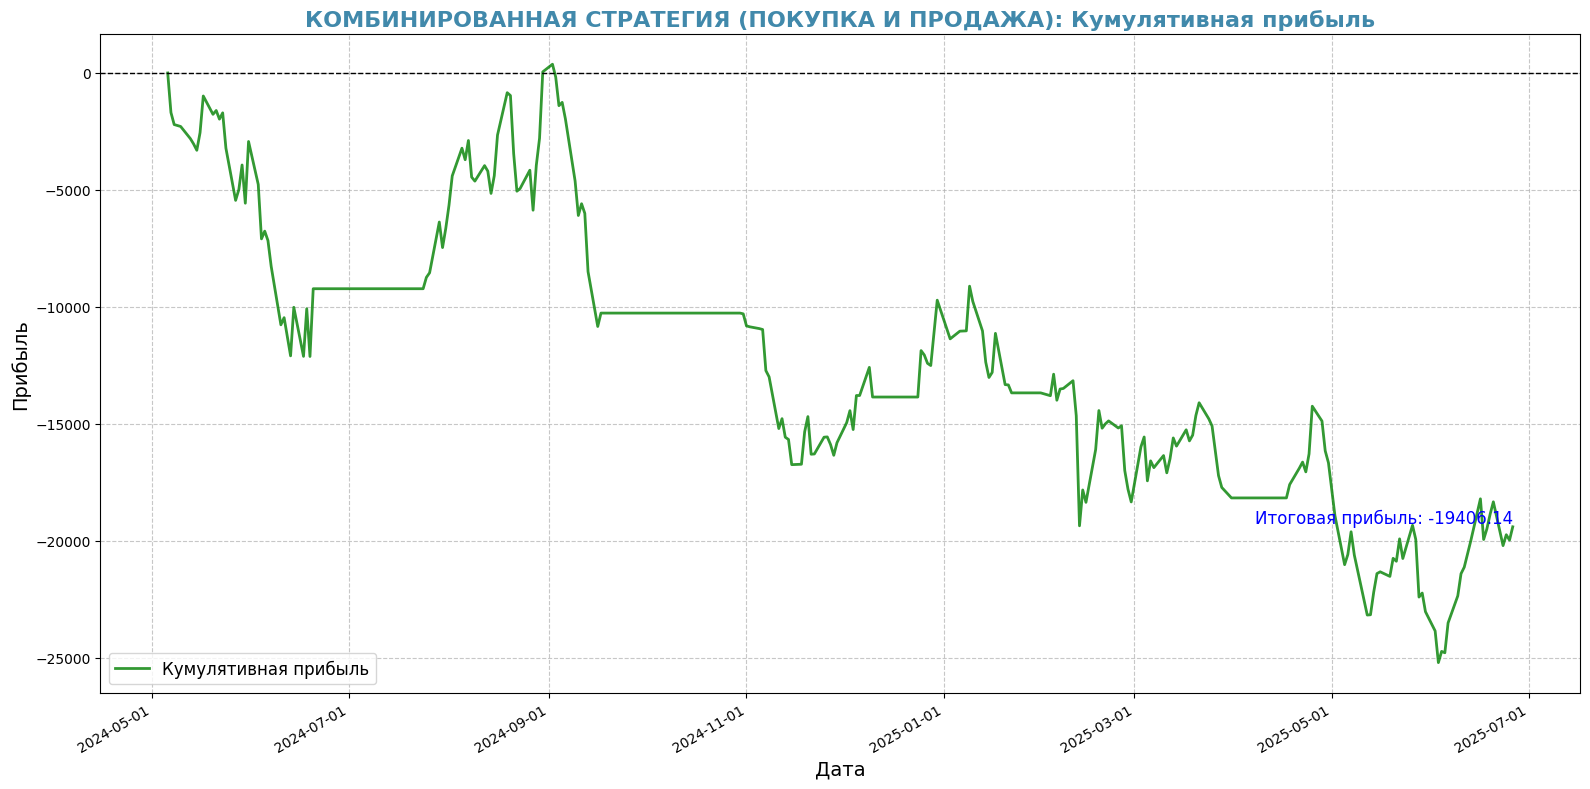

In [ ]:
plot_cumulative_profit(profit_df, 'both')

## Добавим курс доллара и евро

In [ ]:
!pip install yfinance -q

In [ ]:
import yfinance as yf

In [ ]:
df3 = df1

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>load_currency_data(ticker, start_date, end_date)
# Функция для загрузки курсов валют
def load_currency_data(ticker, start_date, end_date):
    try:
        data = yf.download(ticker,
                          start=start_date,
                          end=end_date,
                          progress=False)

        if 'Adj Close' in data.columns:
            return data['Adj Close']
        elif 'Close' in data.columns:
            return data['Close']
        else:
            raise ValueError("Не удалось найти данные о курсе")
    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        return pd.Series()

# Создаем полный диапазон дат
#date_range = pd.date_range(start=df3.index.min(), end=df3.index.max())

# Ресемплируем основной датасет, чтобы заполнить пропуски
#df3 = df3.reindex(date_range)

# Загружаем курсы валют
usd_data = load_currency_data('USDRUB=X',
                             df.index.min(),
                             df.index.max())

eur_data = load_currency_data('EURRUB=X',
                             df.index.min(),
                             df.index.max())

In [ ]:
display(usd_data.head())
display(eur_data.head(), usd_data.info())
display(df3.head(1))

Ticker,USDRUB=X
Date,
2013-11-21,32.870602
2013-11-22,32.981201
2013-11-25,32.511002
2013-11-26,32.896198
2013-11-27,32.904598


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3019 entries, 2013-11-21 to 2025-06-25
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   USDRUB=X  3019 non-null   float64
dtypes: float64(1)
memory usage: 47.2 KB


Ticker,EURRUB=X
Date,
2013-11-21,44.203499
2013-11-22,44.459801
2013-11-25,44.385601
2013-11-26,44.547600
2013-11-27,44.705002


None

,numtrades,value,legalcloseprice,waprice,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,day_of_week,...,lag_159,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean,target
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,
2013-11-21,11468,1.594559e+09,2069.1,2064.9,772239,2064.9,2064.9,1.594333e+09,1.594333e+09,3,-0.85,4,...,1924.3,1942.8,1966.9,1978.9,2002.2,1978.2,2003.4,1993.2,1969.7,1944.5,1983.560714,17.9


In [ ]:
# Объединяем датасеты последовательно
# Первое объединение с usd_data
df3 = df3.merge(
    usd_data,
    left_index=True,  # используем индекс df
    right_index=True,  # используем индекс usd_data
    how='left'  # сохраняем все строки из df, добавляем данные из usd_data
)

In [ ]:
'''
# Второе объединение с eur_data
df3 = df3.merge(
    eur_data,
    left_index=True,  # используем индекс df
    right_index=True,  # используем индекс eur_data
    how='left'  # сохраняем все строки из df, добавляем данные из eur_data
)
'''

"\n# Второе объединение с eur_data\ndf3 = df3.merge(\n    eur_data,\n    left_index=True,  # используем индекс df\n    right_index=True,  # используем индекс eur_data\n    how='left'  # сохраняем все строки из df, добавляем данные из eur_data\n)\n"

In [ ]:
move_column_to_end(df3, 'target')
df3.head(1)

,numtrades,value,legalcloseprice,waprice,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,day_of_week,...,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean,target,USDRUB=X
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,
2013-11-21,11468,1.594559e+09,2069.1,2064.9,772239,2064.9,2064.9,1.594333e+09,1.594333e+09,3,-0.85,4,...,1942.8,1966.9,1978.9,2002.2,1978.2,2003.4,1993.2,1969.7,1944.5,1983.560714,17.9,32.870602


In [ ]:
# подсчет пропусков
usd_missing = df3['USDRUB=X'].isnull().sum()
#eur_missing = df3['EURRUB=X'].isnull().sum()

print(f"Пропуски в столбце usd_rate: {usd_missing}")
#print(f"Пропуски в столбце eur_data: {eur_missing}")

Пропуски в столбце usd_rate: 14


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>fill_missing_with_neighbors_mean(series, window_size=5)
def fill_missing_with_neighbors_mean(series, window_size=5):
    """
    Заполняет пропуски в серии средним значением из соседних значений.

    Параметры:
    series (pd.Series): входная серия с пропусками
    window_size (int): количество соседних значений для расчета среднего (по умолчанию 5)

    Возвращает:
    pd.Series: серия с заполненными пропусками
    """
    filled_series = series.copy()
    missing_indices = series[series.isnull()].index

    for idx in missing_indices:
        # Получаем позицию индекса в общем списке
        pos = series.index.get_loc(idx)

        # Определяем границы окна для поиска соседей
        start = max(0, pos - window_size)
        end = min(len(series), pos + window_size + 1)

        # Получаем соседние значения, исключая NaN
        neighbors = series.iloc[start:end].dropna()

        # Если есть соседние значения, вычисляем среднее
        if not neighbors.empty:
            filled_series.at[idx] = neighbors.mean()

    return filled_series

In [ ]:
# Применение функции к нужным столбцам
df3['usd_rate'] = fill_missing_with_neighbors_mean(df3['USDRUB=X'])
#df3['eur_rate'] = fill_missing_with_neighbors_mean(df3['EURRUB=X'])
df3 = df3.drop(['USDRUB=X',
                #'EURRUB=X'
                ], axis = 1)

In [ ]:
# подсчет пропусков
usd_missing = df3['usd_rate'].isnull().sum()
#eur_missing = df3['eur_rate'].isnull().sum()

print(f"Пропуски в столбце usd_rate: {usd_missing}")
#print(f"Пропуски в столбце eur_rate: {eur_missing}")

Пропуски в столбце usd_rate: 0


In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df3, 'target')

2013-11-21 00:00:00 2024-05-03 00:00:00
2024-05-06 00:00:00 2025-06-26 00:00:00 


(2613, 202) (2613,) 

 (291, 202) (291,)


In [ ]:
print(X_train.ndim)  # Проверка размерности массива
print(X_train.shape)  # Проверка формы массива

2
(2613, 202)


In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
results_data = []

In [ ]:
# Параметры для линейной регрессии
lr_params = {
}

# Параметры для дерева решений
dt_params = {
    'model__max_features': range(1, 28, 4),
    'model__max_depth': range(1, 20, 4),
    'model__min_samples_leaf': range(2, 5, 1),
    'model__min_samples_split': range(1,8,1),
}

# Параметры для LGBM
lgbm_params = {
    'model__n_estimators': range(1, 20, 2),  # Исправлено model___estimators на model__n_estimators
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__verbosity': [-1]
}

# Словарь моделей и их параметров
models_params = {
    'LinearRegression': (LinearRegression(), lr_params),
    'DecisionTreeRegressor': (DecisionTreeRegressor(random_state=RANDOM_STATE), dt_params),
    'LGBMRegressor': (LGBMRegressor(random_state=RANDOM_STATE), lgbm_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

LinearRegression:
R² на кросс-валидации: -0.196
MAE на трейне: 49.992
MAE на тесте: 83.644
RMSE на трейне: 71.426
RMSE на тесте: 108.559
R² на трейне: 0.272
R² на тесте: 0.040
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])
----------------------------------------
DecisionTreeRegressor:
R² на кросс-валидации: -0.310
MAE на трейне: 51.199
MAE на тесте: 87.419
RMSE на трейне: 76.119
RMSE на тесте: 117.237
R² на трейне: 0.173
R² на тесте: -0.120
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeRegressor(max_depth=5, max_features=5,
                                       min_samples_leaf=2,
                                       random_state=654321))])
----------------------------------------
LGBMRegressor:
R² на кросс-валидации: 0.058
MAE на трейне: 48.728
MAE на тесте: 81.089
RMSE на трейне: 74.378
RMSE на тесте: 108.276
R² на трейне: 0.211
R² на тесте: 0.045
Лучшая модель: Pip

In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.196,49.992,83.644,71.426,108.559,0.272,0.040
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 5, 'model__max_features':...",-0.310,51.199,87.419,76.119,117.237,0.173,-0.120
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.058,48.728,81.089,74.378,108.276,0.211,0.045


In [ ]:
# Параметры для случайного леса
rf_params = {
    #'model__max_features': range(1, 20, 2),
    'model__max_depth': range(1, 16, 3),
    'model__min_samples_leaf': range(2,14,3),
    #'model__min_samples_split': range(2,8,2),
    }

# Словарь моделей и их параметров
models_params = {
    'RandomForestRegressor' : (RandomForestRegressor(random_state=RANDOM_STATE), rf_params),
    }

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

RandomForestRegressor:
R² на кросс-валидации: 0.017
MAE на трейне: 48.622
MAE на тесте: 79.064
RMSE на трейне: 71.657
RMSE на тесте: 105.015
R² на трейне: 0.267
R² на тесте: 0.102
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.196,49.992,83.644,71.426,108.559,0.272,0.040
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 5, 'model__max_features':...",-0.310,51.199,87.419,76.119,117.237,0.173,-0.120
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.058,48.728,81.089,74.378,108.276,0.211,0.045
3,RandomForestRegressor,"(StandardScaler(), (DecisionTreeRegressor(max_...","{'model__max_depth': 4, 'model__min_samples_le...",0.017,48.622,79.064,71.657,105.015,0.267,0.102


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
Характеристики лучшей модели:
R² CV: 0.017
MAE TEST: 79.064
RMSE TEST: 105.015
R² TEST: 0.102


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])

In [ ]:
# Параметры для Catboost

catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    #'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass']
    }

# Словарь моделей и их параметров
models_params = {
    'CatBoostRegressor' : (CatBoostRegressor(random_state=RANDOM_STATE,
                               iterations=1000,
                               verbose=False
                               ), catb_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostRegressor:
R² на кросс-валидации: 0.094
MAE на трейне: 43.894
MAE на тесте: 79.496
RMSE на трейне: 61.242
RMSE на тесте: 106.127
R² на трейне: 0.465
R² на тесте: 0.082
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x788582720590>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,R² CV,MAE TRAIN,MAE TEST,RMSE TRAIN,RMSE TEST,R² TRAIN,R² TEST
0,LinearRegression,"(StandardScaler(), LinearRegression())",{},-0.196,49.992,83.644,71.426,108.559,0.272,0.040
1,DecisionTreeRegressor,"(StandardScaler(), DecisionTreeRegressor(max_d...","{'model__max_depth': 5, 'model__max_features':...",-0.310,51.199,87.419,76.119,117.237,0.173,-0.120
2,LGBMRegressor,"(StandardScaler(), LGBMRegressor(n_estimators=...","{'model__learning_rate': 0.1, 'model__n_estima...",0.058,48.728,81.089,74.378,108.276,0.211,0.045
3,RandomForestRegressor,"(StandardScaler(), (DecisionTreeRegressor(max_...","{'model__max_depth': 4, 'model__min_samples_le...",0.017,48.622,79.064,71.657,105.015,0.267,0.102
4,CatBoostRegressor,"(StandardScaler(), <catboost.core.CatBoostRegr...","{'model__depth': 5, 'model__learning_rate': 0.01}",0.094,43.894,79.496,61.242,106.127,0.465,0.082


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])
Характеристики лучшей модели:
R² CV: 0.017
MAE TEST: 79.064
RMSE TEST: 105.015
R² TEST: 0.102


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=654321))])

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model_3.pkl')

Результаты сохранены в файл: best_model_3.pkl


In [ ]:
best_model_3 = best_model

In [ ]:
best_model_predictions = best_model_3.predict(X_test)

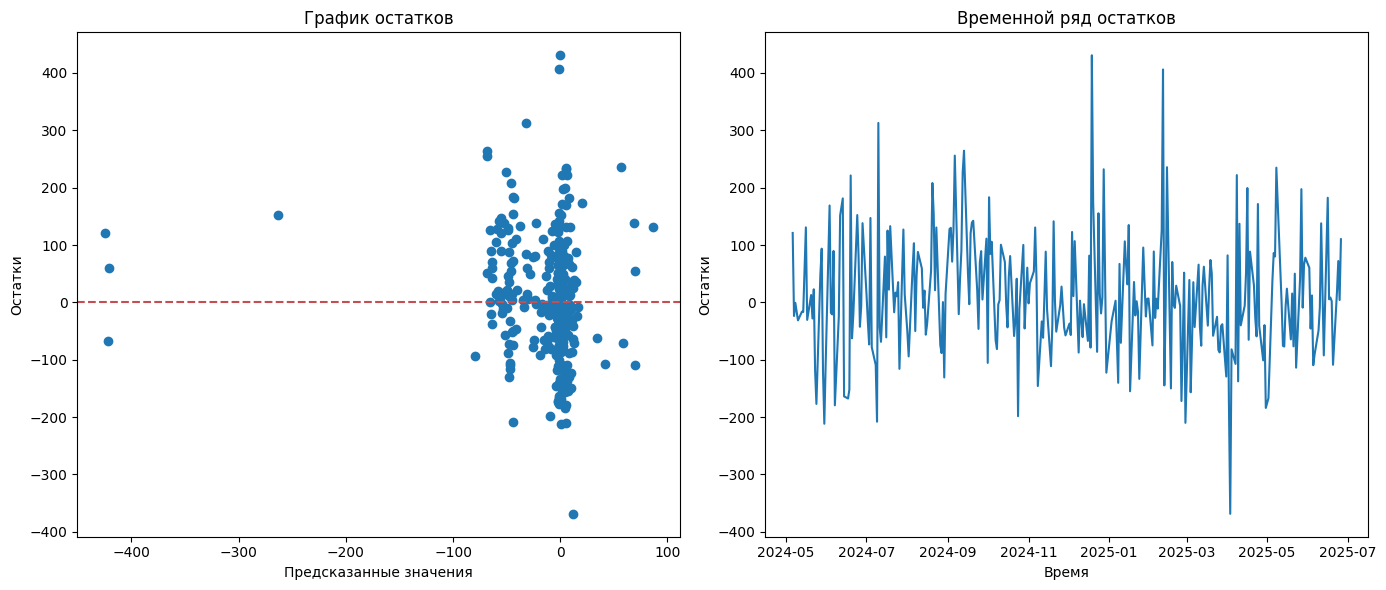

In [ ]:
plot_residuals(y_test, best_model_predictions)

In [ ]:
plot_feature_importance_2(best_model, X_test)

Ошибка при построении графика важности признаков: Модель не поддерживает получение важности признаков


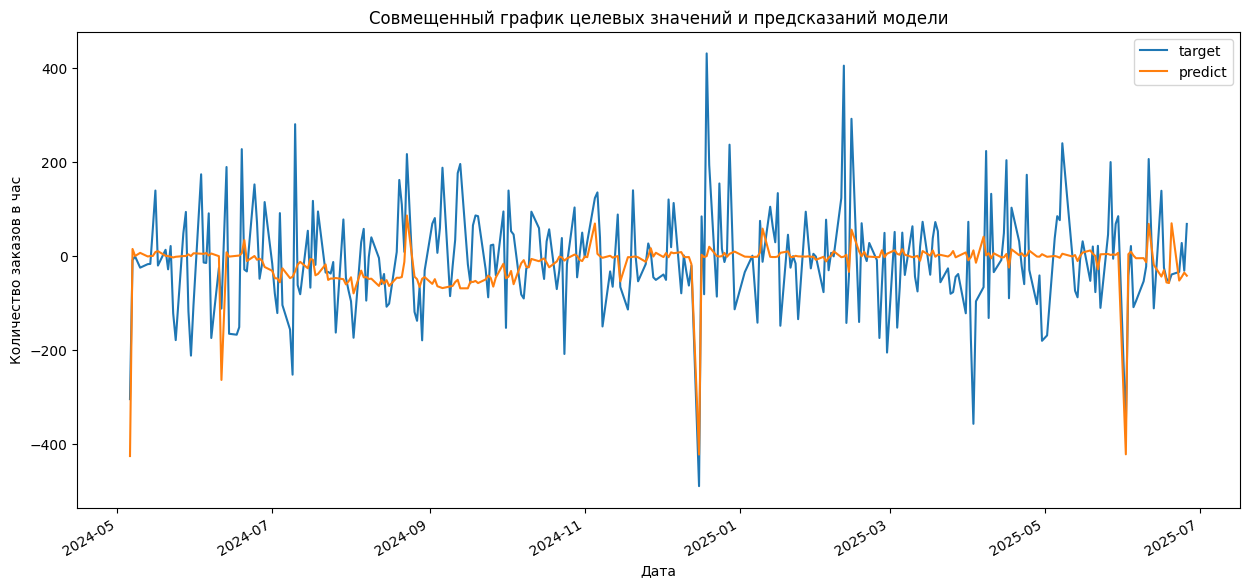

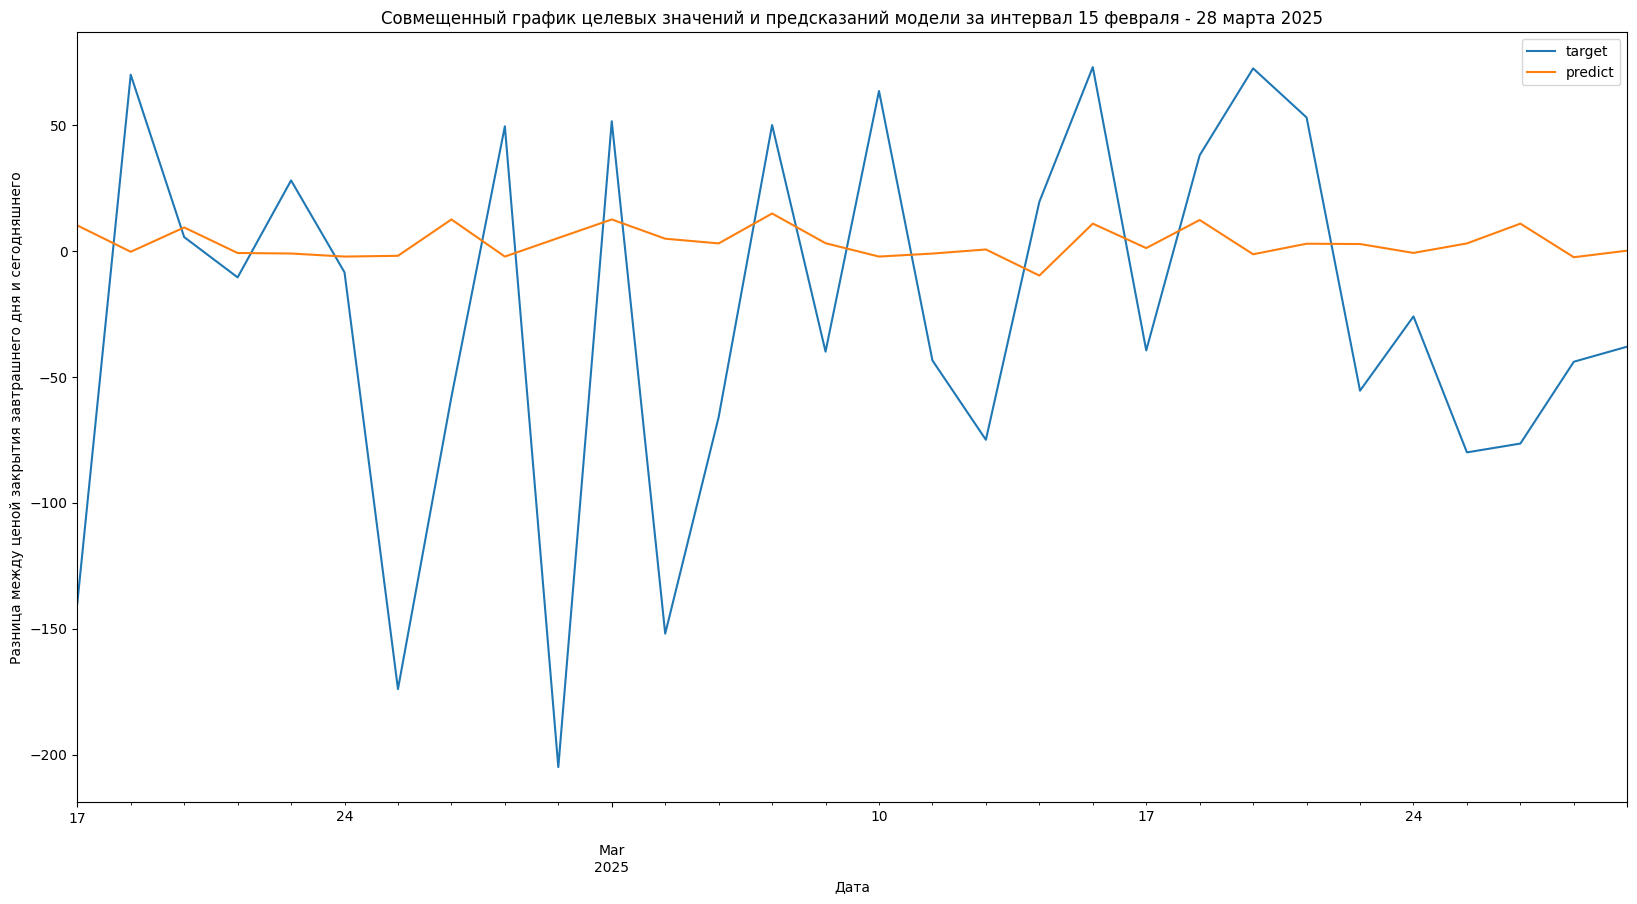

In [ ]:
visualization(best_model_predictions)

### Играем на покупку

In [ ]:
# Шаг 1: Делаем предсказания и добавляем их в X_test
X_test['predicted_diff'] = best_model.predict(X_test)

# Шаг 2: Объединяем данные
profit_df = pd.merge(
    X_test[['predicted_diff']],  # Берем только предсказания
    X_test_1[['open', 'close', 'adx']],  # Берем цены открытия и закрытия
    left_index=True, right_index=True  # Объединяем по индексу datetime
)


In [ ]:
profit_df.head(5)

,predicted_diff,open,close,adx
TRADEDATE,,,,
2024-05-06,-425.007071,8075.0,8026.5,38.684398
2024-05-07,15.286258,7594.0,7722.5,35.410161
2024-05-08,0.338048,7754.5,7714.0,33.318090
2024-05-10,6.956702,7720.0,7713.5,32.085184
2024-05-13,-0.695083,7730.0,7689.0,31.344186


In [ ]:
profit_df = calculate_buy_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-425.007071,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,15.286258,7594.0,7722.5,35.410161,0.000000,0.000000
2024-05-08,0.338048,7754.5,7714.0,33.318090,-522.277387,-522.277387
2024-05-10,6.956702,7720.0,7713.5,32.085184,-83.757150,-606.034537
2024-05-13,-0.695083,7730.0,7689.0,31.344186,-527.186621,-1133.221159


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,69.869290,6322.5,6281.0,20.420690,0.0,-5481.384536
2025-06-23,-51.890584,6388.5,6242.0,22.283388,0.0,-5481.384536
2025-06-24,-44.084930,6245.0,6208.5,21.750033,0.0,-5481.384536
2025-06-25,-35.074233,6218.5,6236.5,21.442900,0.0,-5481.384536
2025-06-26,-41.578701,6250.0,6205.5,21.518423,0.0,-5481.384536


Итоговая прибыль: -5481.384536310906


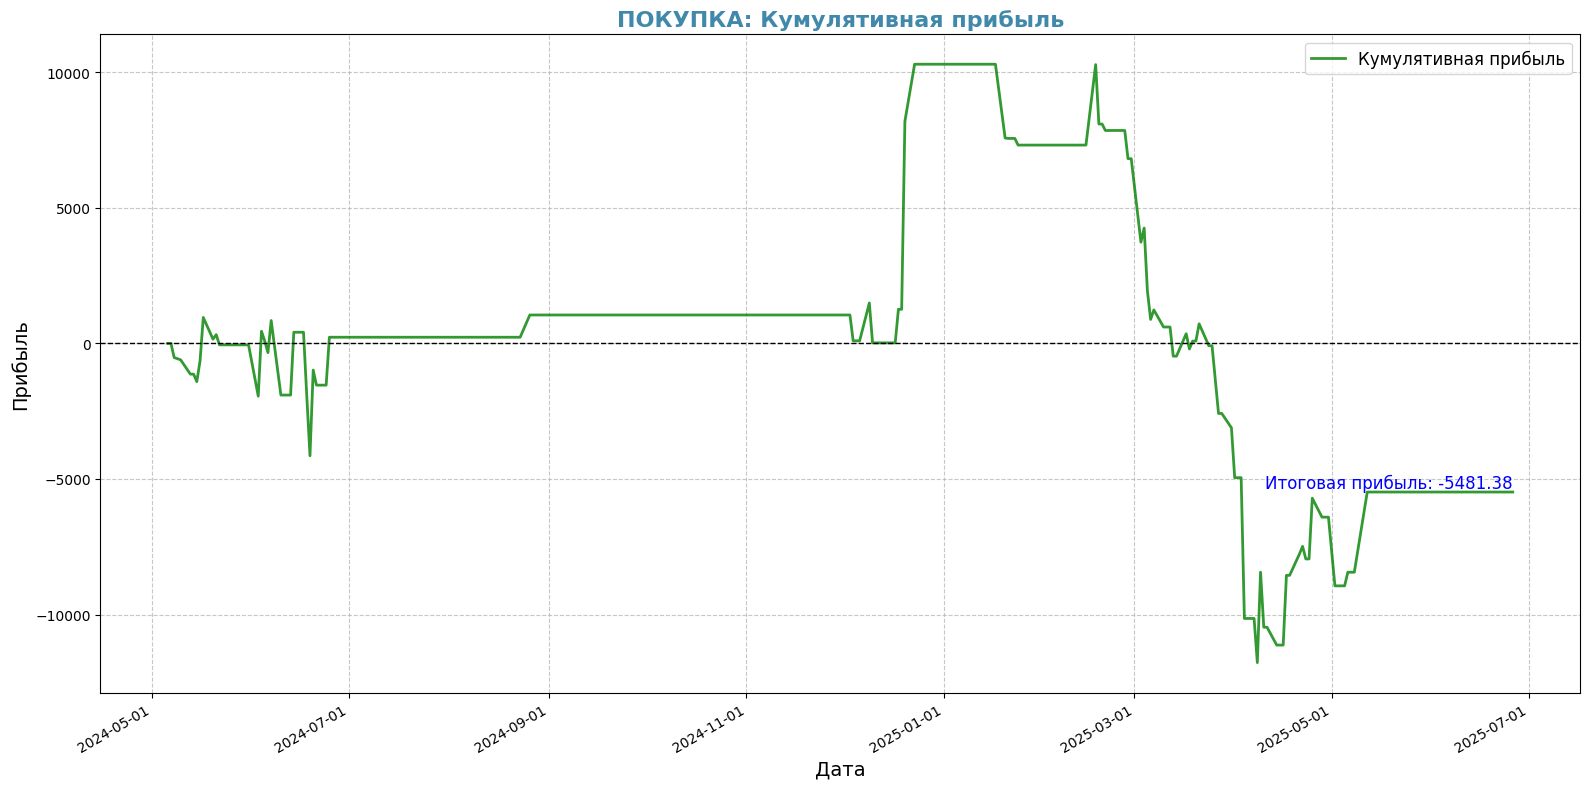

In [ ]:
plot_cumulative_profit(profit_df, 'buy')

### Играем на продажу

In [ ]:
profit_df = calculate_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-425.007071,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,15.286258,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,0.338048,7754.5,7714.0,33.318090,0.000000,-1692.125362
2024-05-10,6.956702,7720.0,7713.5,32.085184,0.000000,-1692.125362
2024-05-13,-0.695083,7730.0,7689.0,31.344186,0.000000,-1692.125362


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,69.869290,6322.5,6281.0,20.420690,0.0,28181.769248
2025-06-23,-51.890584,6388.5,6242.0,22.283388,0.0,28181.769248
2025-06-24,-44.084930,6245.0,6208.5,21.750033,0.0,28181.769248
2025-06-25,-35.074233,6218.5,6236.5,21.442900,0.0,28181.769248
2025-06-26,-41.578701,6250.0,6205.5,21.518423,0.0,28181.769248


Итоговая прибыль: 28181.7692483187


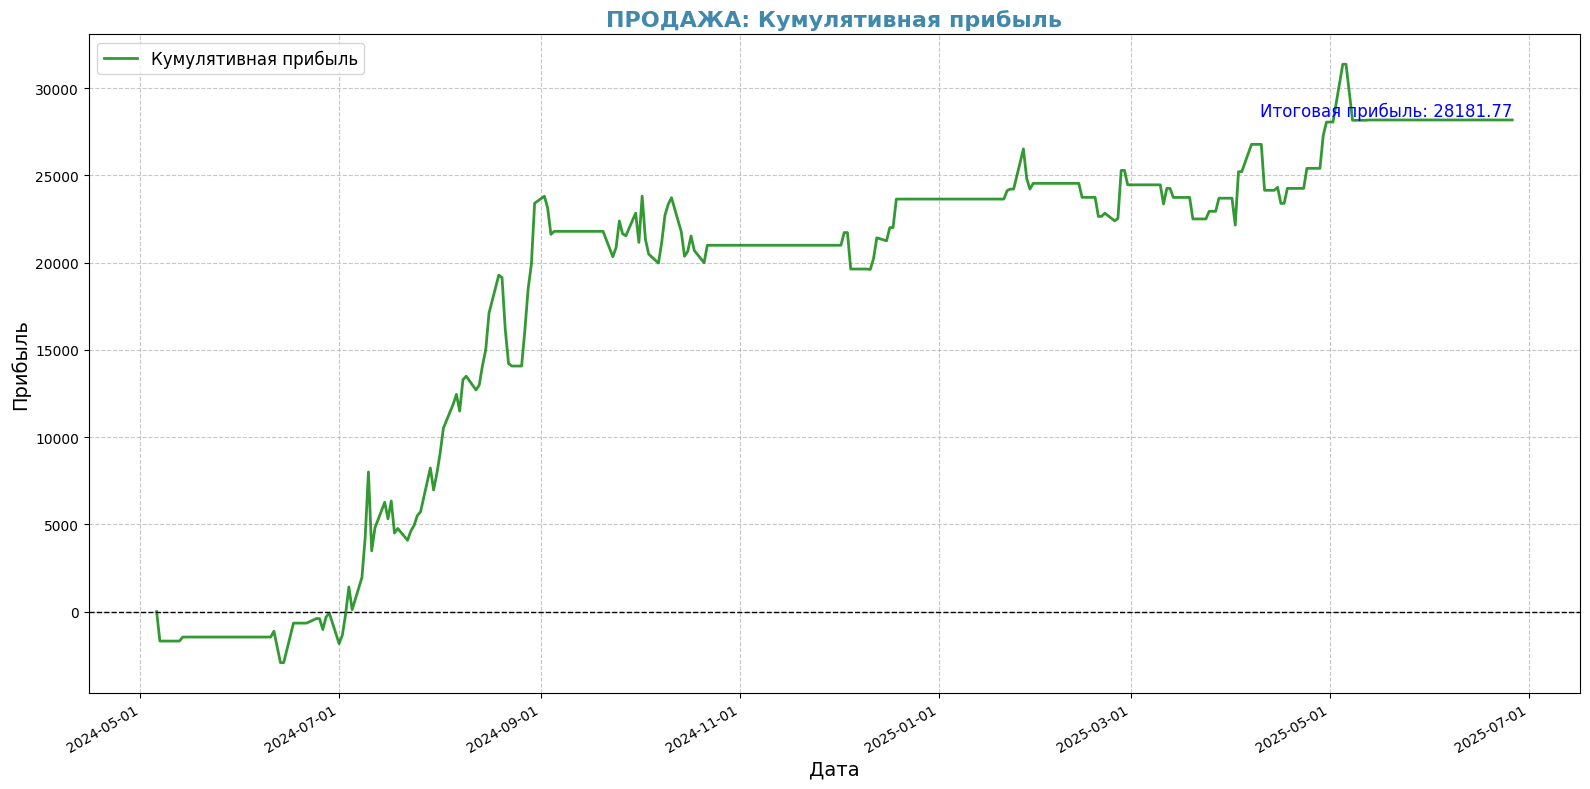

In [ ]:
plot_cumulative_profit(profit_df, 'sell')

### Играем на покупку и продажу

In [ ]:
profit_df = calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-425.007071,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,15.286258,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,0.338048,7754.5,7714.0,33.318090,-513.439799,-2205.565161
2024-05-10,6.956702,7720.0,7713.5,32.085184,-82.339874,-2287.905035
2024-05-13,-0.695083,7730.0,7689.0,31.344186,-518.265963,-2806.170998


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,69.869290,6322.5,6281.0,20.420690,618.486628,-5155.448248
2025-06-23,-51.890584,6388.5,6242.0,22.283388,-2174.959197,-7330.407445
2025-06-24,-44.084930,6245.0,6208.5,21.750033,541.623719,-6788.783726
2025-06-25,-35.074233,6218.5,6236.5,21.442900,-269.808136,-7058.591862
2025-06-26,-41.578701,6250.0,6205.5,21.518423,661.742826,-6396.849036


Итоговая прибыль: -6396.849035645395


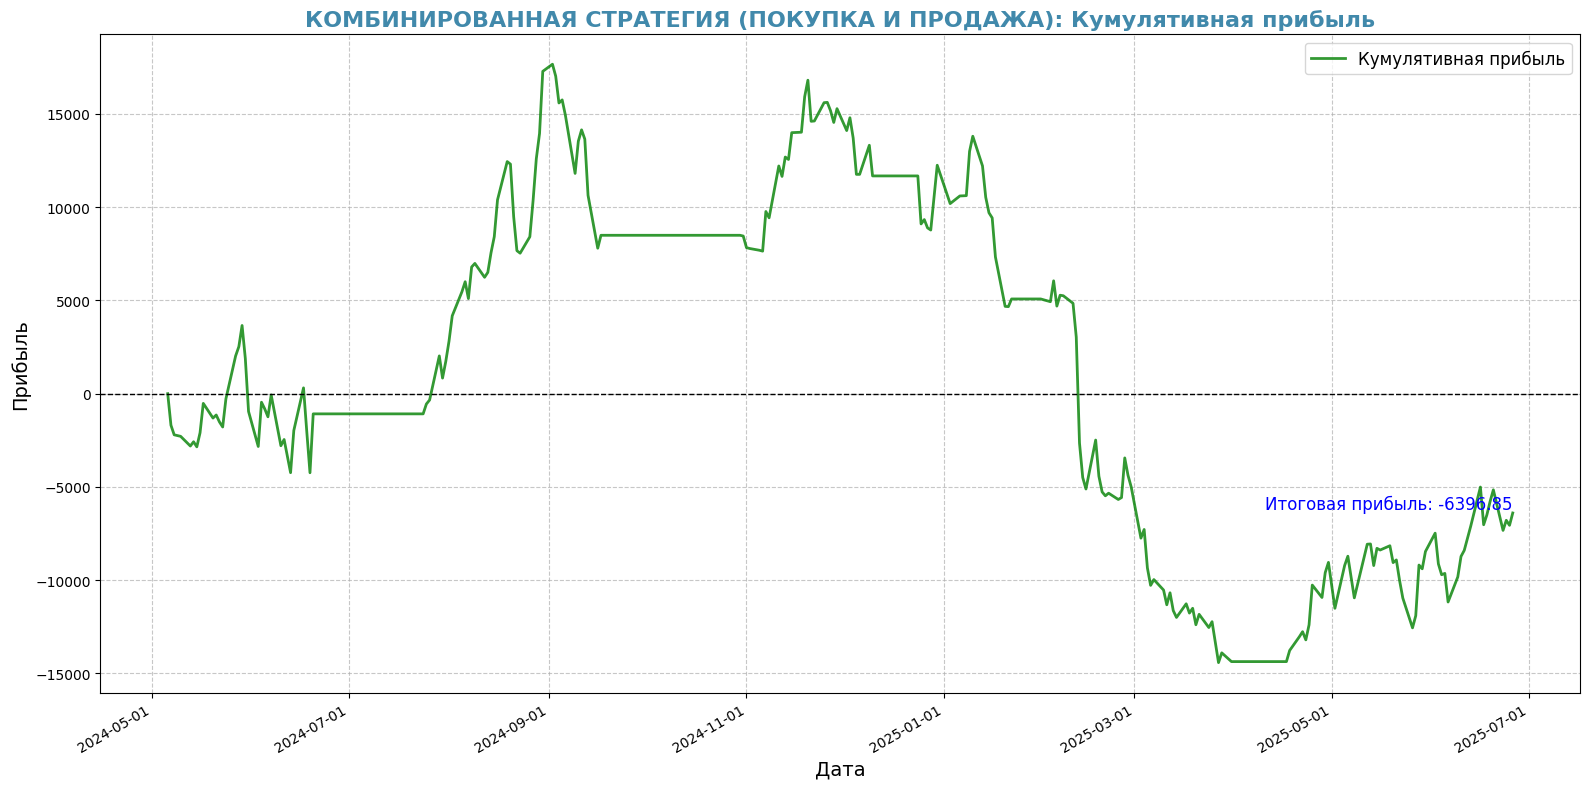

In [ ]:
plot_cumulative_profit(profit_df, 'both')

## Стэкинг

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df1, 'target')

2013-11-21 00:00:00 2024-05-03 00:00:00
2024-05-06 00:00:00 2025-06-26 00:00:00 


(2613, 201) (2613,) 

 (291, 201) (291,)


In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor

# Создаем базовые регрессоры
estimators = [
    ('best_model', best_model),  # best_model - лучшая по итогам обучения отдельных моделей
    ('rf', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)),
    ('svr', SVR(kernel='rbf')),
    ('lr', LinearRegression())
]

# Создаем финальный регрессор с кросс-валидацией
final_estimator = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Добавляем расчет MAE через кросс-валидацию
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mae_cv = cross_val_score(final_estimator, X_train, y_train,
                         cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)

# Создаем стекинг регрессор
stack_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,  # добавляем кросс-валидацию
    n_jobs=-1  # используем все доступные ядра
)

# Обучаем модель
stack_reg.fit(X_train, y_train)

# Предсказываем значения
y_pred_train = stack_reg.predict(X_train)
y_pred = stack_reg.predict(X_test)

# Вычисляем метрики
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)

# Выводим результаты
print(f"MAE (CV): {-np.mean(mae_cv):.3f} ± {np.std(mae_cv):.3f}")
print(f"MAE (Train): {mae_train:.3f}")
print(f"MAE (Test): {mae_test:.3f}")

print(f"RMSE (Train): {rmse_train:.3f}")
print(f"RMSE (Test): {rmse_test:.3f}")

print(f"R2 Score (Train): {r2_train:.3f}")
print(f"R2 Score (Test): {r2_test:.3f}")

MAE (CV): 56.088 ± 2.295
MAE (Train): 44.446
MAE (Test): 79.850
RMSE (Train): 65.711
RMSE (Test): 105.980
R2 Score (Train): 0.384
R2 Score (Test): 0.085


In [ ]:
# Шаг 1: Делаем предсказания и добавляем их в X_test
X_test['predicted_diff'] = stack_reg.predict(X_test)

# Шаг 2: Объединяем данные
profit_df = pd.merge(
    X_test[['predicted_diff']],  # Берем только предсказания
    X_test_1[['open', 'close', 'adx']],  # Берем цены открытия и закрытия
    left_index=True, right_index=True  # Объединяем по индексу datetime
)


In [ ]:
calculate_buy_strategy_profit(profit_df, initial_capital=100000)

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-378.378889,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,3.751365,7594.0,7722.5,35.410161,0.000000,0.000000
2024-05-08,-0.104354,7754.5,7714.0,33.318090,-522.277387,-522.277387
2024-05-10,15.504726,7720.0,7713.5,32.085184,0.000000,-522.277387
2024-05-13,-0.189611,7730.0,7689.0,31.344186,-527.630870,-1049.908258
...,...,...,...,...,...,...
2025-06-20,58.581129,6322.5,6281.0,20.420690,0.000000,-15484.476707
2025-06-23,-55.140642,6388.5,6242.0,22.283388,0.000000,-15484.476707
2025-06-24,-42.782056,6245.0,6208.5,21.750033,0.000000,-15484.476707


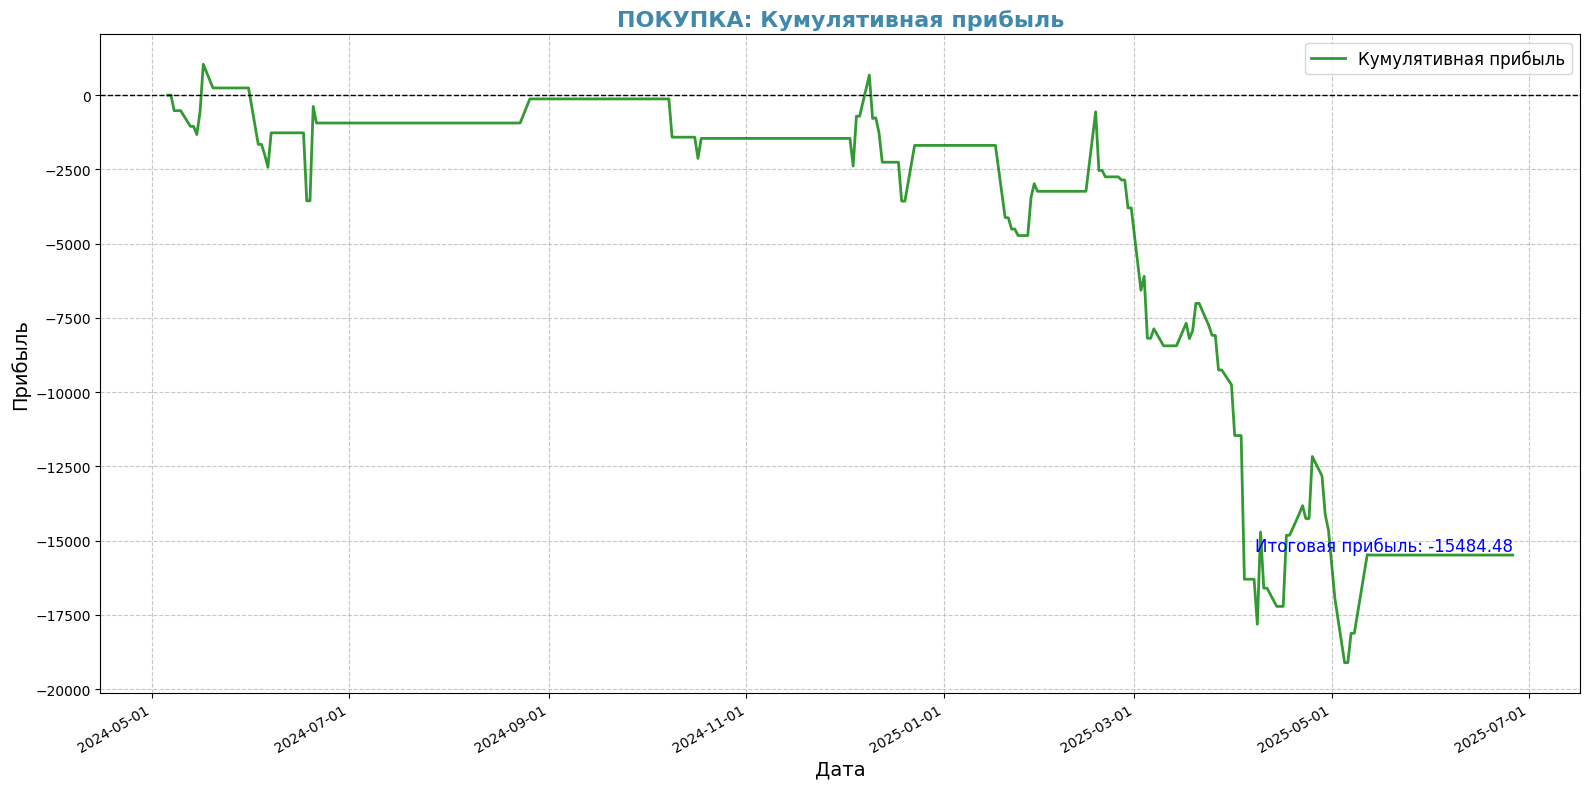

In [ ]:
plot_cumulative_profit(profit_df, 'buy')

In [ ]:
calculate_sell_strategy_profit(profit_df, initial_capital=100000)

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-378.378889,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,3.751365,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,-0.104354,7754.5,7714.0,33.318090,0.000000,-1692.125362
2024-05-10,15.504726,7720.0,7713.5,32.085184,82.772174,-1609.353188
2024-05-13,-0.189611,7730.0,7689.0,31.344186,0.000000,-1609.353188
...,...,...,...,...,...,...
2025-06-20,58.581129,6322.5,6281.0,20.420690,0.000000,13956.902017
2025-06-23,-55.140642,6388.5,6242.0,22.283388,0.000000,13956.902017
2025-06-24,-42.782056,6245.0,6208.5,21.750033,0.000000,13956.902017


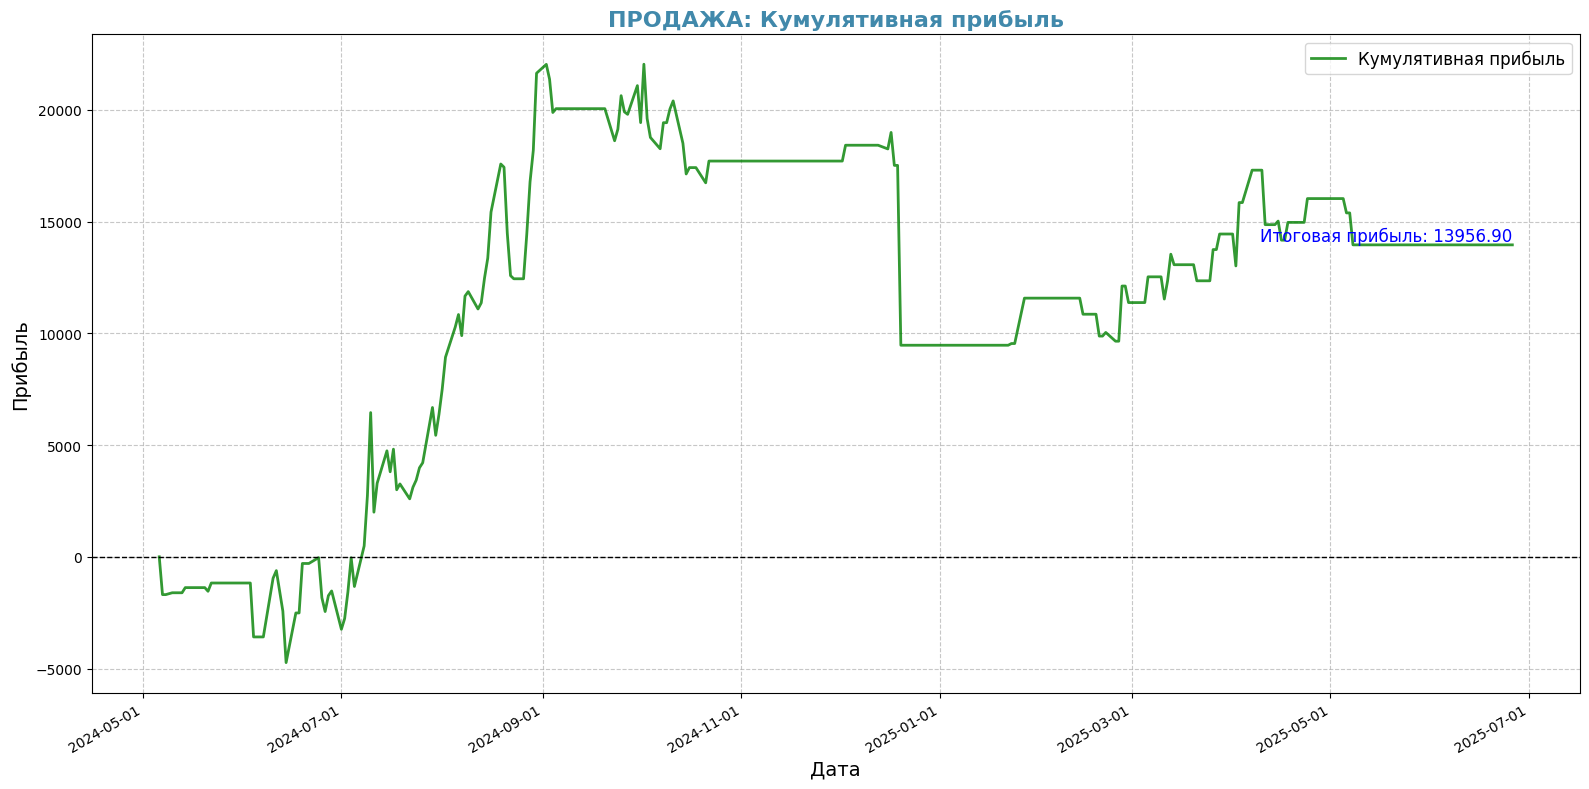

In [ ]:
plot_cumulative_profit(profit_df, 'sell')

In [ ]:
calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000)

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-06,-378.378889,8075.0,8026.5,38.684398,0.000000,0.000000
2024-05-07,3.751365,7594.0,7722.5,35.410161,-1692.125362,-1692.125362
2024-05-08,-0.104354,7754.5,7714.0,33.318090,-513.439799,-2205.565161
2024-05-10,15.504726,7720.0,7713.5,32.085184,82.339874,-2123.225287
2024-05-13,-0.189611,7730.0,7689.0,31.344186,-519.139426,-2642.364713
...,...,...,...,...,...,...
2025-06-20,58.581129,6322.5,6281.0,20.420690,624.149796,-4287.004836
2025-06-23,-55.140642,6388.5,6242.0,22.283388,-2194.874194,-6481.879031
2025-06-24,-42.782056,6245.0,6208.5,21.750033,546.583093,-5935.295938


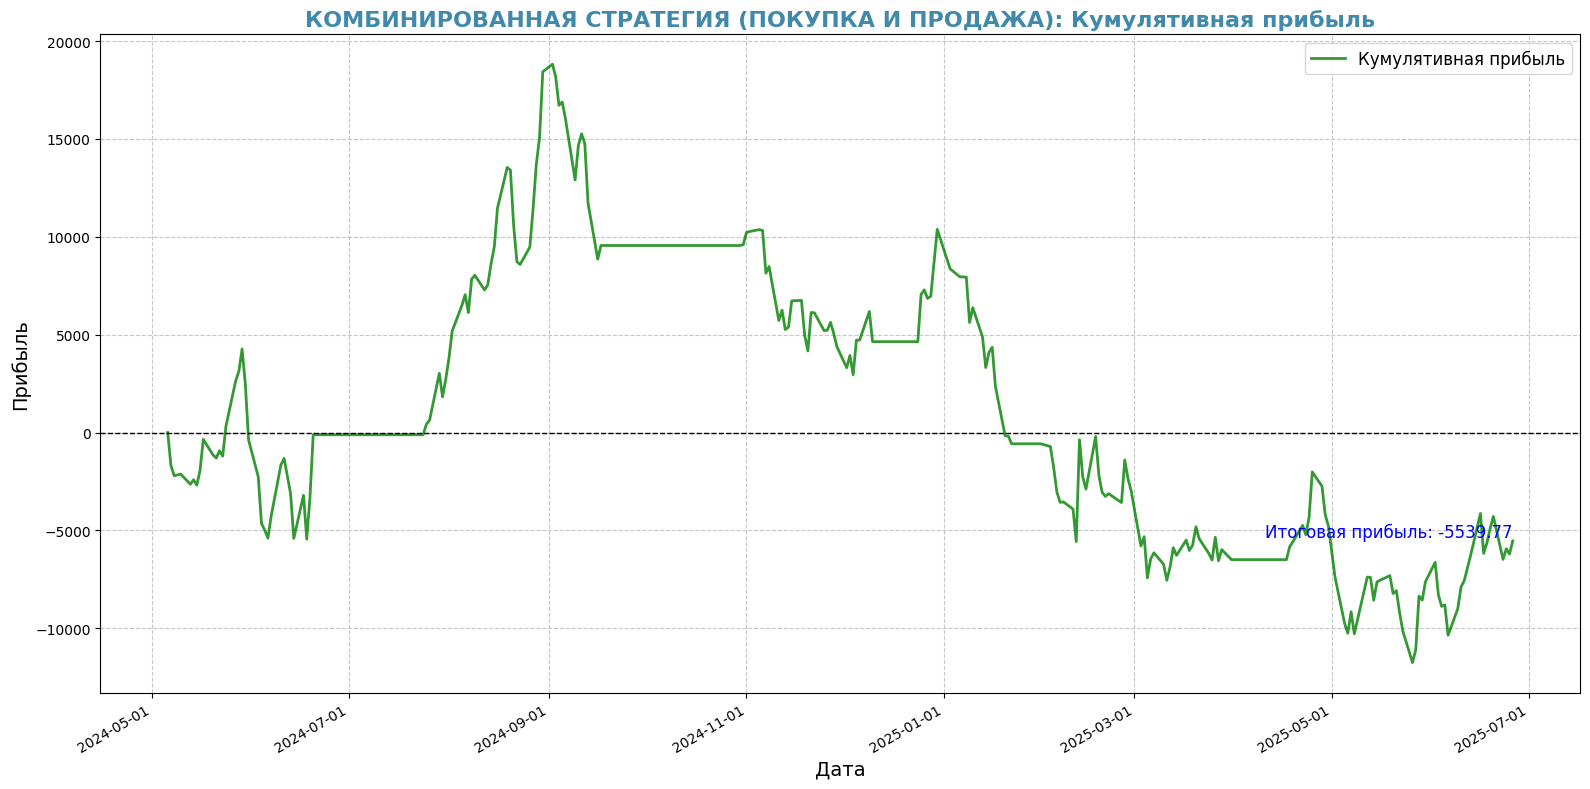

In [ ]:
plot_cumulative_profit(profit_df, 'both')

# Нейросеть LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMRegressor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
def train_model(X_train, y_train, input_size, hidden_size, num_layers, epochs=100):
    # Инициализация модели
    model = LSTMRegressor(input_size, hidden_size, num_layers)

    # Параметры обучения
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Обучение
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs.view(-1), y_train)
        loss.backward()
        optimizer.step()

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    return model

Epoch [10/100], Loss: 0.0218
Epoch [20/100], Loss: 0.0036
Epoch [30/100], Loss: 0.0034
Epoch [40/100], Loss: 0.0033
Epoch [50/100], Loss: 0.0029
Epoch [60/100], Loss: 0.0027
Epoch [70/100], Loss: 0.0028
Epoch [80/100], Loss: 0.0027
Epoch [90/100], Loss: 0.0027
Epoch [100/100], Loss: 0.0027
MSE на тестовых данных: 12225.6681


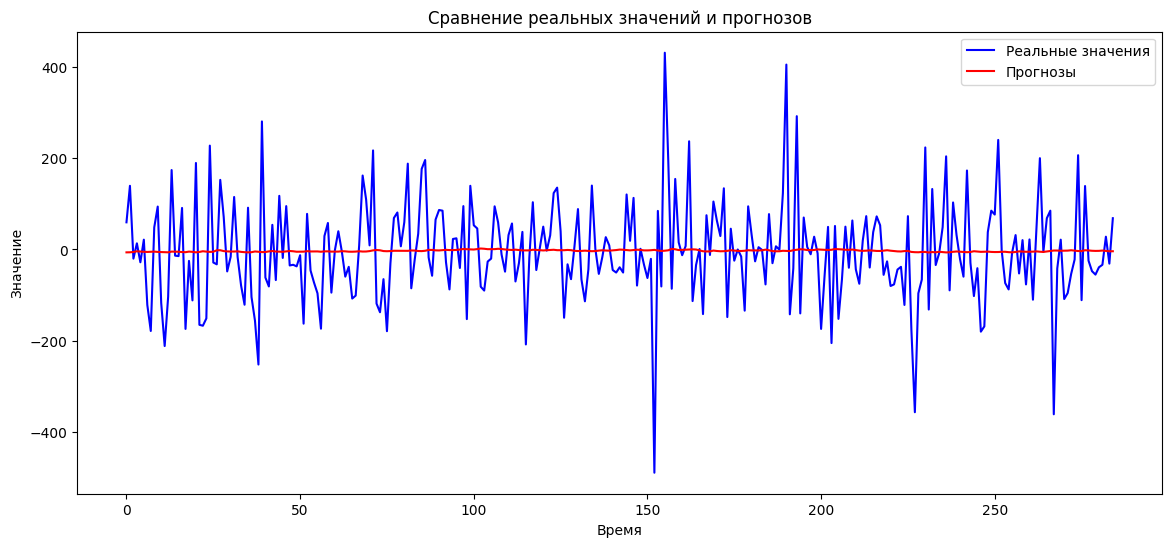

Модель сохранена


In [ ]:
# Параметры модели
seq_length = 60  # длина последовательности
input_size = len(df1.columns) - 1  # количество признаков (все кроме target)
hidden_size = 128
num_layers = 2
epochs = 100  # количество эпох обучения

# Подготовка данных из DataFrame
# Разделяем признаки и целевую переменную
features = df1.drop('target', axis=1).values  # все признаки кроме target
target = df1['target'].values  # целевая переменная

def prepare_multivariate_data(df, target_column, seq_length, test_size=TEST_SIZE):
    # Сохраняем индекс дат отдельно
    dates = df1.index.copy()

    # Разделяем признаки и целевую переменную
    #features = df1.drop(columns=[target_column]).values
    #target = df1[target_column].values

    # Объединяем признаки и целевую переменную для масштабирования
    data = np.concatenate([features, target.reshape(-1, 1)], axis=1)

    # Нормализация данных
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(data)

    # Создание последовательностей
    X, y = [], []
    for i in range(len(scaled_data) - seq_length):
        # Берем только признаки для X (без target)
        X.append(scaled_data[i:i+seq_length, :-1])  # исключаем последний столбец (target)
        # Берем целевое значение на следующий шаг
        y.append(scaled_data[i+seq_length, -1])  # последний столбец - target

    X = np.array(X)
    y = np.array(y)

    # Сохраняем соответствующие даты для последовательностей
    dates_sequences = dates[seq_length:]

    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    # Сохраняем соответствующие даты для train и test
    dates_train = dates_sequences[:len(X_train)]
    dates_test = dates_sequences[len(X_train):]

    # Приведение к формату torch
    X_train_torch = torch.tensor(X_train, dtype=torch.float32)
    y_train_torch = torch.tensor(y_train, dtype=torch.float32)
    X_test_torch = torch.tensor(X_test, dtype=torch.float32)
    y_test_torch = torch.tensor(y_test, dtype=torch.float32)

    return (
        X_train_torch,
        y_train_torch,
        X_test_torch,
        y_test_torch,
        scaler,
        dates_train,
        dates_test
    )

# Подготовка данных
X_train, y_train, X_test, y_test, scaler, dates_train, dates_test = prepare_multivariate_data(features, target, seq_length)

# Обучение модели
model = train_model(
    X_train,
    y_train,
    input_size,
    hidden_size,
    num_layers,
    epochs=epochs
)

# Оценка модели на тестовых данных
def evaluate_model(model, X_test, y_test, scaler, original_target):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)

    # Обратное преобразование масштабирования только для целевой переменной
    min_val = original_target.min()
    max_val = original_target.max()

    # Декодируем предсказания
    predictions = predictions.numpy() * (max_val - min_val) + min_val
    true_values = y_test.numpy() * (max_val - min_val) + min_val

    # Расчет метрик
    mse = np.mean((predictions - true_values) ** 2)
    print(f'MSE на тестовых данных: {mse:.4f}')

    return predictions, true_values

# Визуализация результатов
def plot_results(true_values, predictions):
    plt.figure(figsize=(14, 6))
    plt.plot(true_values, label='Реальные значения', color='blue')
    plt.plot(predictions, label='Прогнозы', color='red')
    plt.title('Сравнение реальных значений и прогнозов')
    plt.xlabel('Время')
    plt.ylabel('Значение')
    plt.legend()
    plt.show()

# Выполнение оценки и визуализации
predictions, true_values = evaluate_model(model, X_test, y_test, scaler, target)
plot_results(true_values, predictions)

# Сохранение модели
torch.save(model.state_dict(), 'lstm_model.pth')
print("Модель сохранена")

Ну тут даже прибыли нет смысла считать. Модель не прогнозирует ничего.

In [ ]:
# Преобразуем predictions в одномерный массив
predictions_1d = predictions.ravel()
# Теперь можно вычислить остатки
residuals = true_values - predictions_1d

predictions_true_df = pd.DataFrame({
    'TRADEDATE': dates_test,
    'true_value': y_test,
    'prediction': predictions_1d,
    'residuals': residuals
})

In [ ]:
# Расчет MAE (Mean Absolute Error)
mae = mean_absolute_error(true_values, predictions_1d)

# Расчет RMSE (Root Mean Squared Error)
mse = mean_squared_error(true_values, predictions_1d)
rmse = np.sqrt(mse)  # Вручную вычисляем корень из MSE

# Расчет R2 (Coefficient of determination)
r2 = r2_score(true_values, predictions_1d)

# Вывод результатов
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 81.8402
RMSE: 110.5292
R2: 0.0001


Статистика остатков:
Mean: -1.8368
Median: -12.0428
Std: 110.5139
Min: -488.1486
Max: 433.6760


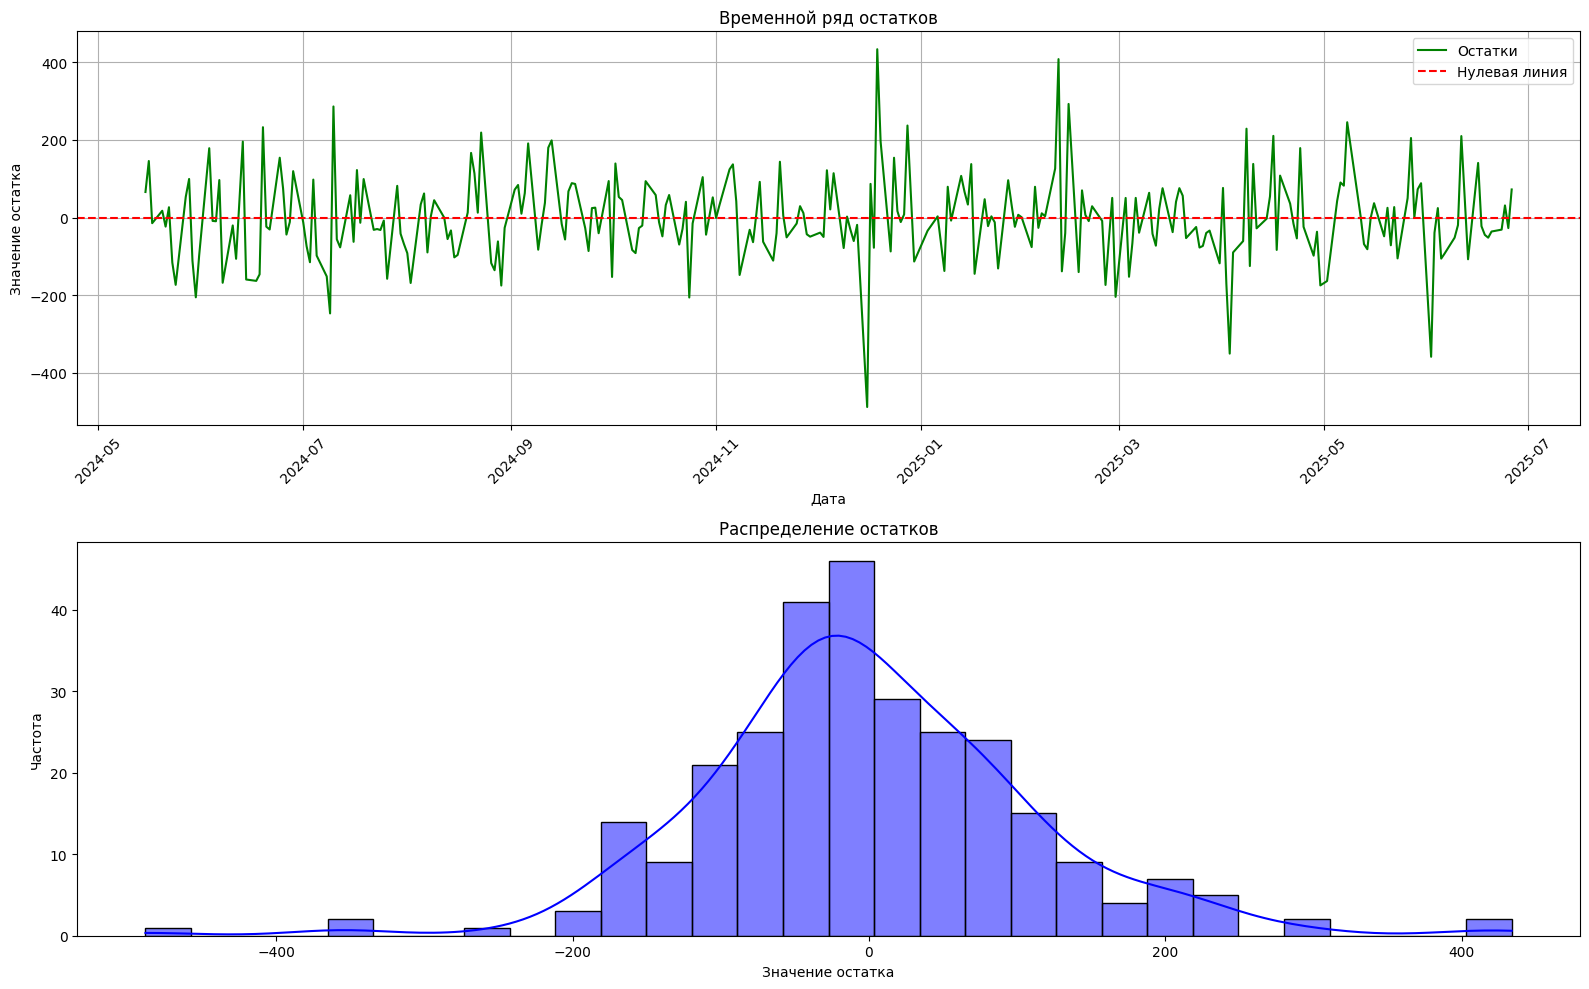

In [ ]:
# Функция для анализа остатков
def analyze_residuals(true_values, predictions):
    # Вычисляем остатки
    residuals = true_values - predictions_1d

    # Базовая статистика остатков
    residual_stats = {
        'Mean': np.mean(residuals),
        'Median': np.median(residuals),
        'Std': np.std(residuals),
        'Min': np.min(residuals),
        'Max': np.max(residuals)
    }

    print("Статистика остатков:")
    for key, value in residual_stats.items():
        print(f"{key}: {value:.4f}")

    return residuals

def plot_residuals_with_time(df, date_column='TRADEDATE', residuals_column='residuals'):
    # Убедимся, что дата в правильном формате
    df[date_column] = pd.to_datetime(df[date_column])

    # Сортируем по дате
    df = df.sort_values(by=date_column)

    # Создаем график
    plt.figure(figsize=(16, 10))

    # Первый подграфик - временной ряд остатков
    plt.subplot(2, 1, 1)
    plt.plot(df[date_column], df[residuals_column], label='Остатки', color='green')
    plt.axhline(y=0, color='red', linestyle='--', label='Нулевая линия')
    plt.title('Временной ряд остатков')
    plt.xlabel('Дата')
    plt.ylabel('Значение остатка')
    plt.xticks(rotation=45)  # Поворот меток дат
    plt.legend()
    plt.grid(True)

    # Второй подграфик - гистограмма остатков
    plt.subplot(2, 1, 2)
    sns.histplot(df[residuals_column], kde=True, color='blue', bins=30)
    plt.title('Распределение остатков')
    plt.xlabel('Значение остатка')
    plt.ylabel('Частота')

    # Улучшаем отображение
    plt.tight_layout()
    plt.show()


# Выполняем анализ и визуализацию
analyze_residuals(true_values, predictions_1d)
plot_residuals_with_time(predictions_true_df)

In [ ]:
predictions_true_df = predictions_true_df.set_index('TRADEDATE')
predictions_true_df.head()

,true_value,prediction,residuals
TRADEDATE,,,
2024-05-15,0.679716,-6.301176,65.801190
2024-05-16,0.729038,-6.140302,145.640325
2024-05-17,0.630703,-5.448276,-14.551696
2024-05-20,0.651356,-3.974505,17.474488
2024-05-21,0.625771,-4.582614,-23.417426


In [ ]:
X_test_1

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,...,lag_158,lag_159,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-06,129034,2.053683e+10,8075.0,7901.0,8089.0,7971.0,7975.0,8026.5,2575025,7973.0,7973.0,1.745112e+10,...,6379.0,6423.0,6344.0,6526.0,6553.0,6519.0,6610.0,6729.0,6456.0,6625.0,6666.5,7178.636905
2024-05-07,163695,1.876852e+10,7594.0,7574.0,7763.5,7726.5,7708.0,7722.5,2435049,7707.0,7707.0,1.790407e+10,...,6495.0,6379.0,6423.0,6344.0,6526.0,6553.0,6519.0,6610.0,6729.0,6456.0,6625.0,7186.732143
2024-05-08,48734,5.280587e+09,7754.5,7691.0,7772.0,7705.0,7712.5,7714.0,684609,7713.5,7713.5,4.861559e+09,...,6449.0,6495.0,6379.0,6423.0,6344.0,6526.0,6553.0,6519.0,6610.0,6729.0,6456.0,7193.264881
2024-05-10,17434,1.685692e+09,7720.0,7710.0,7726.0,7724.0,7720.5,7713.5,218336,7722.5,7722.5,1.281418e+09,...,6386.0,6449.0,6495.0,6379.0,6423.0,6344.0,6526.0,6553.0,6519.0,6610.0,6729.0,7200.752976
2024-05-13,37874,3.889987e+09,7730.0,7676.0,7732.0,7701.0,7701.5,7689.0,505076,7703.5,7703.5,3.339503e+09,...,6490.0,6386.0,6449.0,6495.0,6379.0,6423.0,6344.0,6526.0,6553.0,6519.0,6610.0,7206.613095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-20,55645,2.990267e+09,6322.5,6260.0,6358.5,6283.5,6301.0,6281.0,474471,6303.5,6303.5,2.438536e+09,...,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6958.5,6920.0,6950.0,7020.0,6914.883929
2025-06-23,78905,5.561637e+09,6388.5,6230.0,6390.0,6305.5,6308.0,6242.0,881606,6300.0,6300.0,3.268677e+09,...,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6958.5,6920.0,6950.0,6910.485119
2025-06-24,85467,5.520766e+09,6245.0,6110.0,6247.5,6177.5,6166.0,6208.5,895184,6154.5,6154.5,3.990248e+09,...,6996.5,6873.0,6842.0,6844.5,6794.5,6792.0,6837.0,6733.5,6750.5,6958.5,6920.0,6906.270833


In [ ]:
#Объединяем данные
profit_df = pd.merge(
    predictions_true_df[['prediction']],  # Берем только предсказания
    X_test_1[['open', 'close', 'adx']],  # Берем цены открытия и закрытия
    left_index=True, right_index=True  # Объединяем по индексу datetime
)

In [ ]:
profit_df.rename(columns={'prediction': 'predicted_diff'}, inplace=True)
profit_df.head()

,predicted_diff,open,close,adx
TRADEDATE,,,,
2024-05-15,-6.301176,7677.0,7655.5,31.733091
2024-05-16,-6.140302,7655.5,7715.0,31.666762
2024-05-17,-5.448276,7730.0,7854.5,29.706438
2024-05-20,-3.974505,7897.0,7834.5,27.729939
2024-05-21,-4.582614,7835.0,7848.0,25.879024


### Играем на покупку

In [ ]:
profit_df = calculate_buy_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-15,-6.301176,7677.0,7655.5,31.733091,0.0,0.0
2024-05-16,-6.140302,7655.5,7715.0,31.666762,0.0,0.0
2024-05-17,-5.448276,7730.0,7854.5,29.706438,0.0,0.0
2024-05-20,-3.974505,7897.0,7834.5,27.729939,0.0,0.0
2024-05-21,-4.582614,7835.0,7848.0,25.879024,0.0,0.0


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,-2.993506,6322.5,6281.0,20.420690,0.0,-3765.788999
2025-06-23,-2.353976,6388.5,6242.0,22.283388,0.0,-3765.788999
2025-06-24,-3.184640,6245.0,6208.5,21.750033,0.0,-3765.788999
2025-06-25,-3.893875,6218.5,6236.5,21.442900,0.0,-3765.788999
2025-06-26,-3.858974,6250.0,6205.5,21.518423,0.0,-3765.788999


Итоговая прибыль: -3765.7889987572316


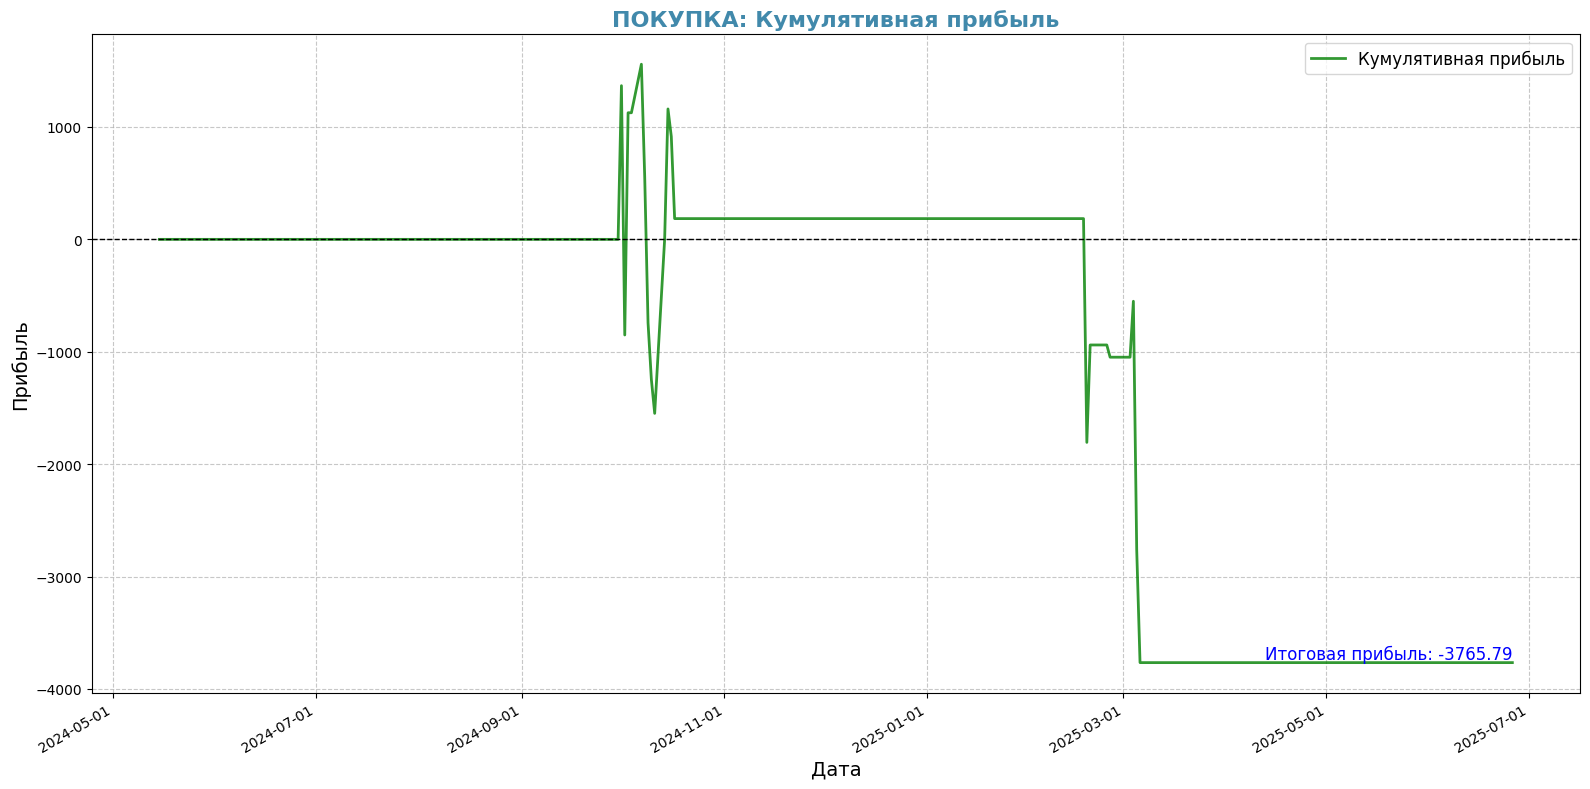

In [ ]:
plot_cumulative_profit(profit_df, 'buy')

### Играем на продажу

In [ ]:
profit_df = calculate_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-15,-6.301176,7677.0,7655.5,31.733091,0.000000,0.000000
2024-05-16,-6.140302,7655.5,7715.0,31.666762,-777.218993,-777.218993
2024-05-17,-5.448276,7730.0,7854.5,29.706438,-1598.090069,-2375.309062
2024-05-20,-3.974505,7897.0,7834.5,27.729939,772.640646,-1602.668416
2024-05-21,-4.582614,7835.0,7848.0,25.879024,-163.262962,-1765.931378


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,-2.993506,6322.5,6281.0,20.420690,0.0,27824.575413
2025-06-23,-2.353976,6388.5,6242.0,22.283388,0.0,27824.575413
2025-06-24,-3.184640,6245.0,6208.5,21.750033,0.0,27824.575413
2025-06-25,-3.893875,6218.5,6236.5,21.442900,0.0,27824.575413
2025-06-26,-3.858974,6250.0,6205.5,21.518423,0.0,27824.575413


Итоговая прибыль: 27824.575413249673


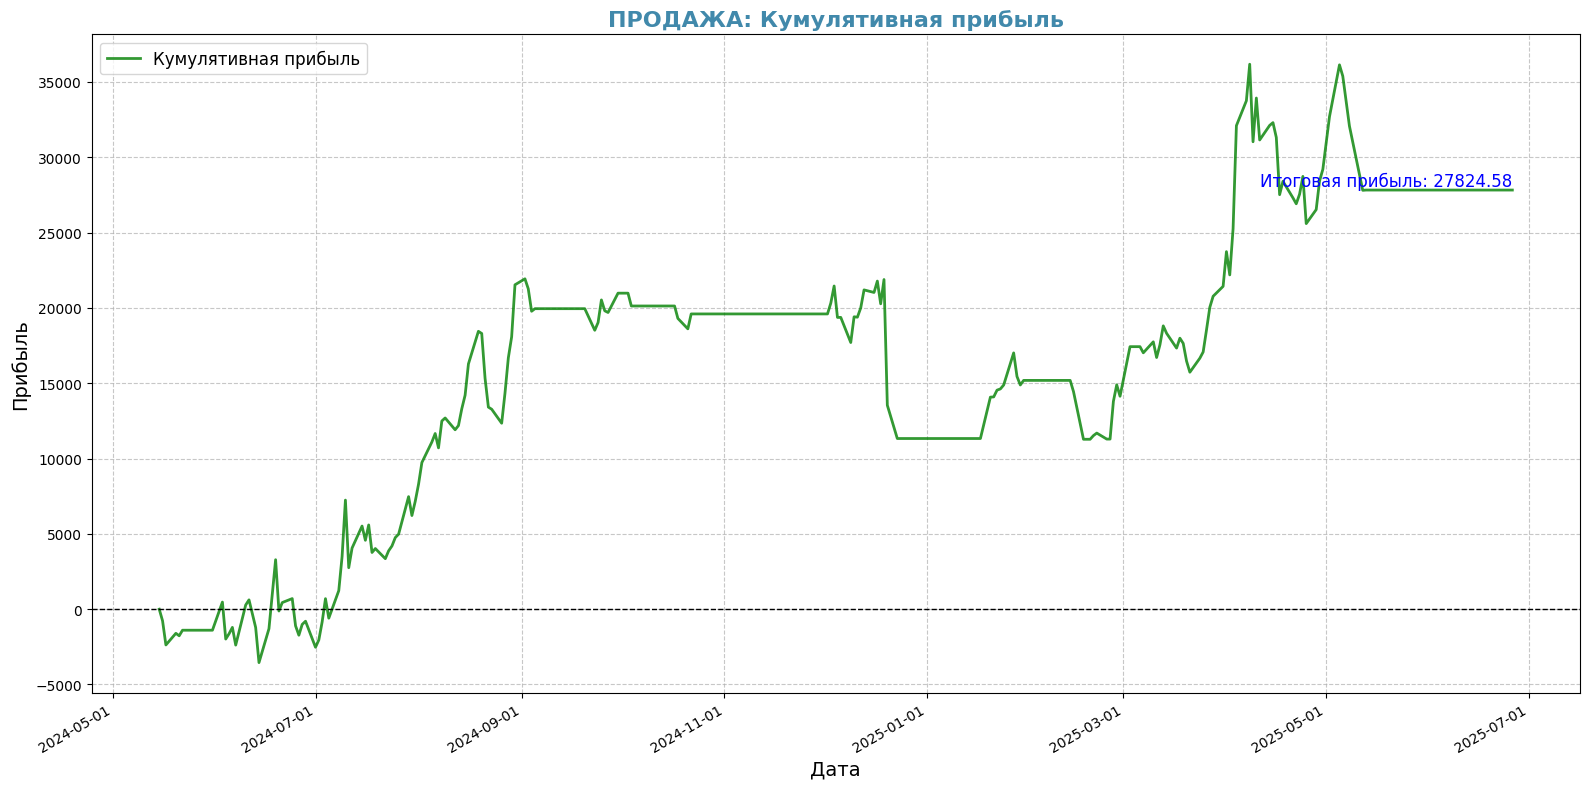

In [ ]:
plot_cumulative_profit(profit_df, 'sell')

### Играем на покупку и продажу

In [ ]:
profit_df = calculate_buy_sell_strategy_profit(profit_df, initial_capital=100000)

In [ ]:
# Выводим итоговый датафрейм
display(profit_df.head())
display(profit_df.tail())
# Дополнительные проверки
print(f"Итоговая прибыль: {profit_df['cumulative_profit'].iloc[-1]}")

,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2024-05-15,-6.301176,7677.0,7655.5,31.733091,0.000000,0.000000
2024-05-16,-6.140302,7655.5,7715.0,31.666762,-777.218993,-777.218993
2024-05-17,-5.448276,7730.0,7854.5,29.706438,-1598.090069,-2375.309062
2024-05-20,-3.974505,7897.0,7834.5,27.729939,772.640646,-1602.668416
2024-05-21,-4.582614,7835.0,7848.0,25.879024,-163.262962,-1765.931378


,predicted_diff,open,close,adx,daily_profit,cumulative_profit
TRADEDATE,,,,,,
2025-06-20,-2.993506,6322.5,6281.0,20.420690,870.437836,33481.117847
2025-06-23,-2.353976,6388.5,6242.0,22.283388,3060.966387,36542.084234
2025-06-24,-3.184640,6245.0,6208.5,21.750033,798.044207,37340.128442
2025-06-25,-3.893875,6218.5,6236.5,21.442900,-397.543188,36942.585254
2025-06-26,-3.858974,6250.0,6205.5,21.518423,975.031207,37917.616461


Итоговая прибыль: 37917.616460940524


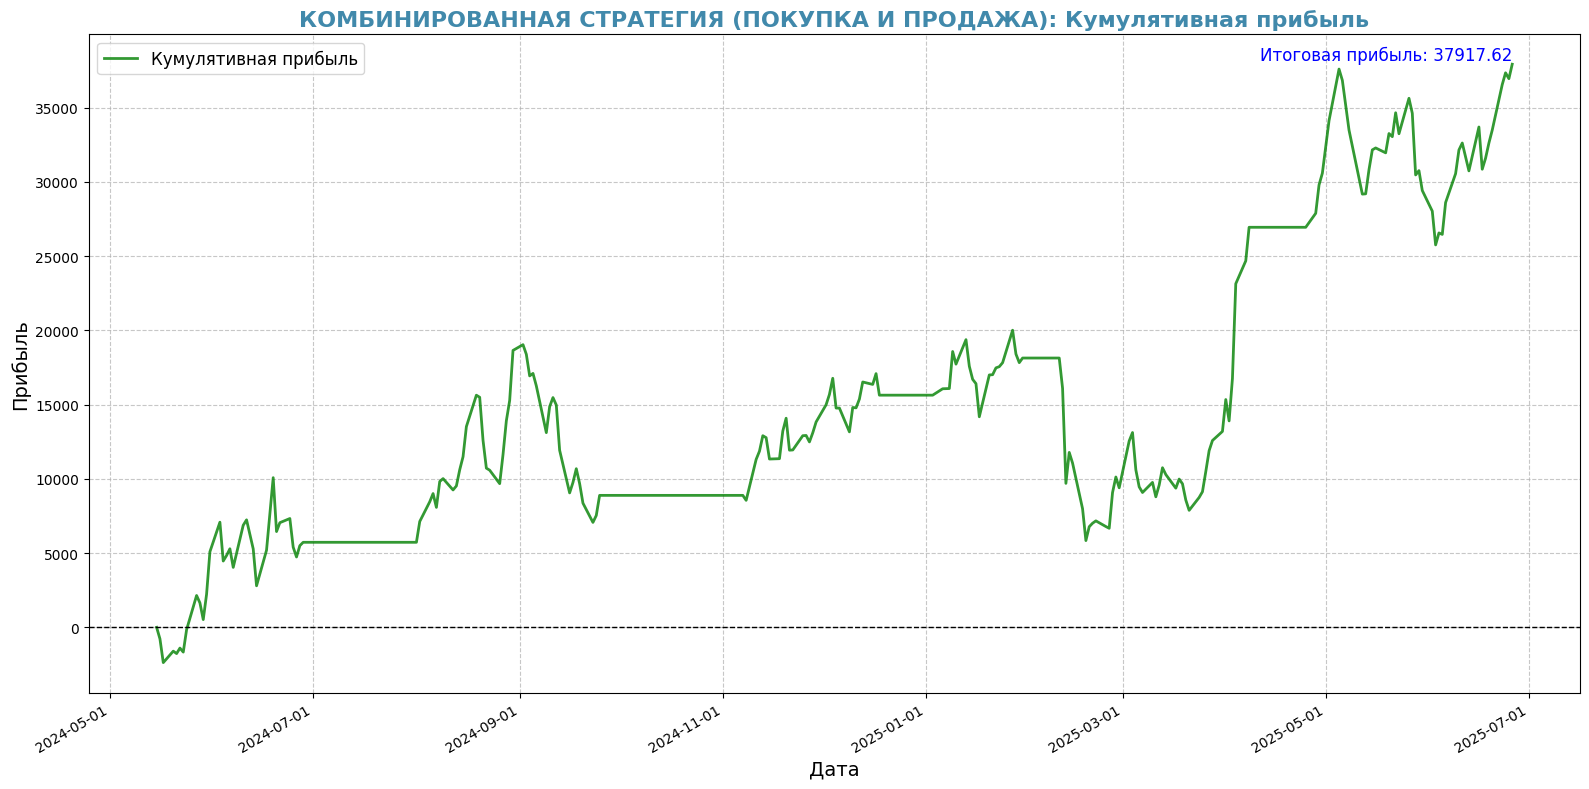

In [ ]:
plot_cumulative_profit(profit_df, 'both')

## Вывод по этапу обучения моделей

По итогам обучения для лучших моделей была рассчитана прибыль при условии использования каждой из них в трех стратегиях:
- Покупка
- Продажа
- Гибрид (покупка+продажа)

Логика расчета прибыли такова: на старте имеется 100000р. В случае, если модель предсказывает рост, мы покупаем акции по цене открытия и в конце дня рассчитываем прибыль. если модель предсказывает падение, мы проджаем.
В расчет была включена отсечка по индикатору ФВЧб который отвечает за тренд, и в случае, если ADX<25 действия не должн ысовершаться. Это было сделано для минимизации рисков и показало хороший результат в сравнении с расчетом без данной отсечки.

Поскольку модель гибрид наиболее приближена к реальности, оценку работы моделей необходимо вести по ней.


К сожалению, в случае использования стратегии на покупку и продажу, все модели, кроме нейросети,  показывают отрицательную прибыль.
Однако, что касается нейросети, ее график прогнозов, совмещенный с грацфиком реальных значений говорит нам о том, что она практически не предсказывает.
При этом, расчеты показывают, что используя предсказания нейросети при гибридной стратегии прибыль за ~14 месяцев положительна и достигает 37,9 тыс р. Однако, учитывая график прогнозов и временной ряд остатков рекомендовать данную модель видится нецелесообразным.
Таким образом, можно сделать вывод, что добиться работающей предсказательной модели на данном этапе не удалось.

# **Основные результаты исследования**
В ходе проведенного анализа было установлено, что создание модели, способной достоверно предсказывать направление движения цен (рост или падение) на следующий торговый день, является нецелесообразным.

**Факторы, ограничивающие точность прогнозирования**
- Рыночные риски и волатильность
- Высокая степень непредсказуемости рыночных движений
- Влияние множества неконтролируемых факторов (политические события, стихийные бедствия, форс-мажоры)
- Эмоциональные реакции участников рынка
- Ограниченность данных
- Недостаточный объем исторических данных для построения надежных прогнозов
- Отсутствие значимых паттернов в краткосрочных временных рядах
- Быстрое устаревание статистических зависимостей

**Технические ограничения**
- Невозможность учета всех фундаментальных факторов в реальном времени
- Ограниченная вычислительная мощность для обработки всех влияющих параметров
- Сложность моделирования нелинейных зависимостей

**Анализ причин неудачных результатов**
- Рыночный шум значительно искажает сигналы, делая их непригодными для точного прогнозирования. Случайные колебания цен преобладают над детерминированными факторами.
- Временные рамки прогнозирования (один день) слишком коротки для выявления устойчивых закономерностей. Краткосрочные движения цен часто носят случайный характер.

**Рекомендации**
1. Сместить фокус с краткосрочного прогнозирования на:
- Среднесрочный анализ трендов
- Фундаментальный анализ
- Управление рисками

2. Использовать альтернативные подходы:
- Построение моделей оценки вероятности различных сценариев
- Анализ зон поддержки и сопротивления
- Комплексный подход к управлению портфелем

**Заключительные положения**
Несмотря на невозможность точного предсказания дневных движений цен, это не означает бесполезность аналитических инструментов. Они могут быть эффективно использованы для:
- Оценки рисков
- Определения оптимальных точек входа и выхода
- Управления портфелем
- Диверсификации вложений

Таким образом, вместо поиска “священного Грааля” прогнозирования, рекомендуется сосредоточиться на создании устойчивой инвестиционной стратегии, учитывающей все аспекты рыночного риска.